In [1]:
# ============================================================
# CELL 0: IMPORTS AND SEEDS
# ============================================================
# This is the first cell to run in every session.
# It imports every Python library the notebook needs,
# locks all random seeds so results are reproducible,
# and sets the computing device to GPU or CPU.
#
# Run this cell before any other cell.
# ============================================================

# --- Standard library imports ---
import random        # Python built-in random number generator
import os            # file and folder operations
import json          # read and write JSON config files
import pickle        # save Python objects like the scaler to disk
import warnings      # suppress non-critical warning messages

# --- Numerical and data libraries ---
import numpy as np              # numerical arrays and math operations
import pandas as pd             # DataFrames for tabular data

# --- Plotting libraries ---
import matplotlib.pyplot as plt         # core plotting engine
import matplotlib.dates as mdates       # format dates on plot axes
import matplotlib.patches as mpatches   # create custom legend entries
import seaborn as sns                   # statistical visualisation

# --- Scientific and statistical libraries ---
import scipy.stats as scipy_stats       # Wilcoxon test and KDE

# --- Deep learning library ---
import torch                            # PyTorch core
import torch.nn as nn                   # neural network layers
import torch.optim as optim             # optimisers such as Adam
from torch.utils.data import DataLoader, Dataset  # data batching

# --- Specialised financial libraries ---
import iisignature   # path signature computation
import yfinance as yf  # download stock data from Yahoo Finance
import cvxpy as cp   # convex optimisation for Mean-CVaR benchmark

# --- Machine learning utilities ---
from sklearn.preprocessing import StandardScaler  # z-score normalisation

# Suppress all warning messages to keep output clean
warnings.filterwarnings('ignore')

# Set a consistent plot style across all figures
sns.set_style('darkgrid')


def set_all_seeds(seed=42):
    """
    Lock every random seed so that results are exactly
    reproducible when the notebook is re-run.

    This must be called before any random operations
    including model weight initialisation, data shuffling,
    and NumPy random draws.

    Parameters
    ----------
    seed : int
        The seed value to use everywhere. Default is 42.
    """
    random.seed(seed)                           # Python built-in random
    np.random.seed(seed)                        # NumPy random
    torch.manual_seed(seed)                     # PyTorch CPU operations
    torch.cuda.manual_seed(seed)               # PyTorch single GPU
    torch.cuda.manual_seed_all(seed)           # PyTorch all GPUs
    torch.backends.cudnn.deterministic = True  # make convolutions deterministic
    torch.backends.cudnn.benchmark = False     # disable auto-tuning for speed
    os.environ['PYTHONHASHSEED'] = str(seed)   # Python hash randomisation
    print(f"All seeds locked to: {seed}")


# Call immediately so seeds are set before anything else
set_all_seeds(42)

# Store the seed value as a global constant for reuse
GLOBAL_SEED = 42

# Detect available hardware
# Use GPU if one is available, otherwise fall back to CPU
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')

print(f"Running on device : {DEVICE}")
print(f"PyTorch version   : {torch.__version__}")
print(f"NumPy version     : {np.__version__}")
print(f"\nCell 0 complete")

All seeds locked to: 42
Running on device : cpu
PyTorch version   : 2.8.0+cpu
NumPy version     : 1.26.4

Cell 0 complete


In [2]:
# ============================================================
# CELL 1: CONFIGURATION
# ============================================================
# THIS IS THE ONLY CELL YOU NEED TO CHANGE between runs.
#
# Set DATA_POOL to switch between universe sizes:
#   DATA_POOL = 20  -> concentrated portfolio (20 stocks)
#   DATA_POOL = 30  -> intermediate portfolio (30 stocks)
#   DATA_POOL = 50  -> diversified portfolio  (50 stocks)
#
# Every other cell reads from the variables set here,
# so changing DATA_POOL and running Kernel > Restart and
# Run All is all that is needed to switch universes.
# ============================================================

# ---- CHANGE THIS VALUE ONLY ----
DATA_POOL = 20   # set to 20, 30, or 50
# --------------------------------

# Output folder is named after the pool size
# This keeps all results from each run separate
# Running with 20 saves to data_paper_20/
# Running with 30 saves to data_paper_30/
# Running with 50 saves to data_paper_50/
DATA_FOLDER = f'data_paper_{DATA_POOL}'

# Create the main data folder if it does not already exist
if not os.path.exists(DATA_FOLDER):
    os.makedirs(DATA_FOLDER)
    print(f"Created folder: {DATA_FOLDER}")
else:
    print(f"Using existing folder: {DATA_FOLDER}")

# Create subfolders for signatures, models, and robustness results
SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')

for folder in [SIG_FOLDER, MODELS_FOLDER, ROBUST_FOLDER]:
    if not os.path.exists(folder):
        os.makedirs(folder)   # create each subfolder if missing

# ---- Paper's exact train / validation / test split ----
# These dates match Hwang and Zohren (2025) exactly.
# Training covers 17 years of multiple market regimes.
# Validation is used only for early stopping — never for evaluation.
# Test period includes COVID crash, recovery, and 2022 rate shock.
TRAIN_START = '2000-01-01'   # training begins
TRAIN_END   = '2016-12-31'   # training ends
VAL_START   = '2017-01-01'   # validation begins
VAL_END     = '2019-12-31'   # validation ends
TEST_START  = '2020-01-01'   # test begins
TEST_END    = '2024-12-31'   # test ends
DATA_START  = '2000-01-01'   # earliest date to download
DATA_END    = '2024-12-31'   # latest date to download

# ---- Signature hyperparameters ----
# LOOKBACK: how many past trading days to use per window
# One month of trading days is approximately 20
LOOKBACK  = 20

# SIG_ORDER: truncation level for path signatures
# Order 2 gives all pairwise cross-asset interactions
# Order 3 adds three-way interactions but requires far more RAM
# We use order 2 for 30 and 50 stocks due to memory constraints
# Order 3 is feasible only for 20 stocks on standard hardware
SIG_ORDER = 2

# ---- Transformer architecture ----
# These parameters are identical for all five models.
# Architecture is the controlled constant — only the
# loss function changes across experiments.
D_MODEL       = 64     # internal representation size per token
N_HEADS       = 4      # number of parallel attention heads
N_LAYERS      = 2      # number of stacked Transformer layers
DROPOUT       = 0.1    # fraction of connections dropped during training

# ---- Training hyperparameters ----
BATCH_SIZE    = 64     # number of samples per gradient update
N_EPOCHS      = 100    # maximum number of training epochs
LEARNING_RATE = 1e-4   # Adam optimiser step size
PATIENCE      = 15     # stop training after this many epochs without improvement

# ---- Print a summary for confirmation ----
print(f"\n{'='*50}")
print(f"  CONFIGURATION SUMMARY")
print(f"{'='*50}")
print(f"  Asset pool       : {DATA_POOL} stocks")
print(f"  Data folder      : {DATA_FOLDER}/")
print(f"  Training period  : {TRAIN_START} to {TRAIN_END}")
print(f"  Validation period: {VAL_START} to {VAL_END}")
print(f"  Test period      : {TEST_START} to {TEST_END}")
print(f"  Lookback window  : {LOOKBACK} trading days")
print(f"  Signature order  : {SIG_ORDER}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {N_EPOCHS}")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  Early stopping   : {PATIENCE} epochs patience")
print(f"{'='*50}")
print(f"\nCell 1 complete")

Using existing folder: data_paper_20

  CONFIGURATION SUMMARY
  Asset pool       : 20 stocks
  Data folder      : data_paper_20/
  Training period  : 2000-01-01 to 2016-12-31
  Validation period: 2017-01-01 to 2019-12-31
  Test period      : 2020-01-01 to 2024-12-31
  Lookback window  : 20 trading days
  Signature order  : 2
  Batch size       : 64
  Max epochs       : 100
  Learning rate    : 0.0001
  Early stopping   : 15 epochs patience

Cell 1 complete


In [3]:
# ============================================================
# CELL 2: DEFINE THE 50-STOCK UNIVERSE
# ============================================================
# We define all 50 tickers here. The first DATA_POOL tickers
# are selected for the current run, so:
#   DATA_POOL = 20 uses tickers 1-20
#   DATA_POOL = 30 uses tickers 1-30
#   DATA_POOL = 50 uses all 50 tickers
#
# Selection criteria for each stock:
#   1. Listed and actively traded before January 2000
#      so the full 17-year training period is available
#   2. Still actively traded through December 2024
#      so the test period is complete
#   3. Diversified across five sectors
#
# Four stocks from the original selection were replaced
# due to delistings or insufficient price history:
#
#   BCR -> BSX
#     BCR (C.R. Bard) was acquired by Becton Dickinson
#     in 2017 and delisted. BSX (Boston Scientific)
#     is comparable, listed since 1992.
#
#   K   -> CPB
#     K (Kellanova) was acquired by Mars in August 2024
#     causing price data to end mid-period. CPB
#     (Campbell Soup) has history from 1954.
#
#   MMC -> CB
#     MMC (Marsh McLennan) had data gaps around year
#     2000 on Yahoo Finance. CB (Chubb) has complete
#     data from 2000.
#
#   PSX -> OXY
#     PSX (Phillips 66) was spun off in May 2012 with
#     no prior price history. OXY (Occidental
#     Petroleum) has history since the 1920s.
# ============================================================

ALL_TICKERS_50 = [

    # ---- TECHNOLOGY (12 stocks) ----
    # All listed before 2000 with continuous trading history
    'AAPL',   # Apple Inc, listed 1980
    'MSFT',   # Microsoft Corporation, listed 1986
    'IBM',    # International Business Machines, listed 1916
    'INTC',   # Intel Corporation, listed 1971
    'CSCO',   # Cisco Systems, listed 1990
    'TXN',    # Texas Instruments, listed 1953
    'QCOM',   # Qualcomm Inc, listed 1991
    'ADI',    # Analog Devices, listed 1969
    'GLW',    # Corning Inc, listed 1945
    'AMAT',   # Applied Materials, listed 1972
    'KLAC',   # KLA Corporation, listed 1980
    'LRCX',   # Lam Research, listed 1984

    # ---- FINANCIALS (12 stocks) ----
    # CB replaces MMC which had Yahoo Finance data gaps
    'JPM',    # JPMorgan Chase, listed 1969
    'BAC',    # Bank of America, listed 1986
    'WFC',    # Wells Fargo, listed 1962
    'C',      # Citigroup, listed 1977
    'GS',     # Goldman Sachs, listed 1999
    'MS',     # Morgan Stanley, listed 1986
    'USB',    # US Bancorp, listed 1929
    'PNC',    # PNC Financial Services, listed 1983
    'CB',     # Chubb Limited, replaces MMC
    'AON',    # Aon plc, listed 1968
    'TRV',    # Travelers Companies, listed 1994
    'AFL',    # Aflac Inc, listed 1974

    # ---- HEALTHCARE (10 stocks) ----
    # BSX replaces BCR which was delisted in 2017
    'JNJ',    # Johnson and Johnson, listed 1944
    'PFE',    # Pfizer Inc, listed 1944
    'MRK',    # Merck and Co, listed 1946
    'ABT',    # Abbott Laboratories, listed 1929
    'MDT',    # Medtronic plc, listed 1960
    'BAX',    # Baxter International, listed 1931
    'BSX',    # Boston Scientific, replaces BCR
    'BDX',    # Becton Dickinson, listed 1963
    'SYK',    # Stryker Corporation, listed 1979
    'ZBH',    # Zimmer Biomet, listed 2001

    # ---- ENERGY (8 stocks) ----
    # OXY replaces PSX which only listed in 2012
    'XOM',    # Exxon Mobil, listed 1920
    'CVX',    # Chevron Corporation, listed 1925
    'COP',    # ConocoPhillips, listed 2002
    'SLB',    # SLB (Schlumberger), listed 1962
    'HAL',    # Halliburton, listed 1948
    'BKR',    # Baker Hughes, listed 1987
    'OXY',    # Occidental Petroleum, replaces PSX
    'VLO',    # Valero Energy, listed 1997

    # ---- CONSUMER STAPLES (8 stocks) ----
    # CPB replaces K which was acquired by Mars in 2024
    'PG',     # Procter and Gamble, listed 1891
    'KO',     # Coca-Cola Company, listed 1919
    'PEP',    # PepsiCo Inc, listed 1919
    'WMT',    # Walmart Inc, listed 1972
    'MCD',    # McDonalds Corporation, listed 1965
    'CL',     # Colgate-Palmolive, listed 1930
    'GIS',    # General Mills, listed 1928
    'CPB',    # Campbell Soup, replaces K
]

# Select only the first DATA_POOL tickers from the full list
# DATA_POOL is set in Cell 1
# Tickers are ordered so the first 12 are Technology,
# next 12 are Financials, etc. This means:
#   20 stocks = Tech(12) + Financials(8)
#   30 stocks = Tech(12) + Financials(12) + Healthcare(6)
#   50 stocks = all five sectors
TICKERS = ALL_TICKERS_50[:DATA_POOL]

# Sector map used for colouring plots
# Maps each ticker symbol to its sector name
SECTOR_MAP = {
    'AAPL':'Technology',  'MSFT':'Technology',
    'IBM' :'Technology',  'INTC':'Technology',
    'CSCO':'Technology',  'TXN' :'Technology',
    'QCOM':'Technology',  'ADI' :'Technology',
    'GLW' :'Technology',  'AMAT':'Technology',
    'KLAC':'Technology',  'LRCX':'Technology',
    'JPM' :'Financials',  'BAC' :'Financials',
    'WFC' :'Financials',  'C'   :'Financials',
    'GS'  :'Financials',  'MS'  :'Financials',
    'USB' :'Financials',  'PNC' :'Financials',
    'CB'  :'Financials',  'AON' :'Financials',
    'TRV' :'Financials',  'AFL' :'Financials',
    'JNJ' :'Healthcare',  'PFE' :'Healthcare',
    'MRK' :'Healthcare',  'ABT' :'Healthcare',
    'MDT' :'Healthcare',  'BAX' :'Healthcare',
    'BSX' :'Healthcare',  'BDX' :'Healthcare',
    'SYK' :'Healthcare',  'ZBH' :'Healthcare',
    'XOM' :'Energy',      'CVX' :'Energy',
    'COP' :'Energy',      'SLB' :'Energy',
    'HAL' :'Energy',      'BKR' :'Energy',
    'OXY' :'Energy',      'VLO' :'Energy',
    'PG'  :'Consumer',    'KO'  :'Consumer',
    'PEP' :'Consumer',    'WMT' :'Consumer',
    'MCD' :'Consumer',    'CL'  :'Consumer',
    'GIS' :'Consumer',    'CPB' :'Consumer',
}

# Colour assigned to each sector for consistent plot styling
SECTOR_COLOURS = {
    'Technology' : 'steelblue',
    'Financials' : 'darkorange',
    'Healthcare' : 'green',
    'Energy'     : 'red',
    'Consumer'   : 'purple',
}

# Print a summary of what was selected
print(f"Full universe     : {len(ALL_TICKERS_50)} stocks")
print(f"Selected for run  : {len(TICKERS)} stocks")
print(f"\nReplacement summary:")
print(f"  BCR replaced by BSX: BCR delisted after BDX acquisition 2017")
print(f"  K   replaced by CPB: K acquired by Mars August 2024")
print(f"  MMC replaced by CB : MMC had data gaps on Yahoo Finance around 2000")
print(f"  PSX replaced by OXY: PSX only listed from May 2012")
print(f"\nSelected tickers:")

# Print each ticker with its sector label
current_sector = None
for i, ticker in enumerate(TICKERS, 1):
    sector = SECTOR_MAP.get(ticker, 'Other')
    if sector != current_sector:
        print(f"\n  [{sector}]")
        current_sector = sector
    print(f"    {i:>3}. {ticker}")

print(f"\nCell 2 complete")

Full universe     : 50 stocks
Selected for run  : 20 stocks

Replacement summary:
  BCR replaced by BSX: BCR delisted after BDX acquisition 2017
  K   replaced by CPB: K acquired by Mars August 2024
  MMC replaced by CB : MMC had data gaps on Yahoo Finance around 2000
  PSX replaced by OXY: PSX only listed from May 2012

Selected tickers:

  [Technology]
      1. AAPL
      2. MSFT
      3. IBM
      4. INTC
      5. CSCO
      6. TXN
      7. QCOM
      8. ADI
      9. GLW
     10. AMAT
     11. KLAC
     12. LRCX

  [Financials]
     13. JPM
     14. BAC
     15. WFC
     16. C
     17. GS
     18. MS
     19. USB
     20. PNC

Cell 2 complete


In [4]:
# ============================================================
# CELL 3: DOWNLOAD STOCK PRICES FROM YAHOO FINANCE
# ============================================================
# This cell downloads daily adjusted closing prices for all
# selected tickers from Yahoo Finance.
#
# auto_adjust=True adjusts prices for dividends and stock
# splits. This is critical because unadjusted prices show
# artificial jumps on ex-dividend dates that would confuse
# the signature computation and model training.
#
# If the raw price file already exists on disk the cell
# loads it instead of re-downloading. This saves time on
# repeated runs and avoids hitting Yahoo Finance rate limits.
# ============================================================

RAW_PATH = os.path.join(DATA_FOLDER, 'raw_prices.csv')

if os.path.exists(RAW_PATH):
    # File already exists — load from disk instead of downloading
    print(f"Raw price file found. Loading from {RAW_PATH}...")
    raw_prices = pd.read_csv(
        RAW_PATH,
        index_col  = 0,    # the first column is the date index
        parse_dates= True  # convert date strings to datetime objects
    )
    print(f"Loaded {raw_prices.shape[0]} rows and "
          f"{raw_prices.shape[1]} columns")
else:
    # File does not exist — download from Yahoo Finance
    print(f"Downloading {len(TICKERS)} tickers from Yahoo Finance...")
    print(f"Period: {DATA_START} to {DATA_END}")
    print("This may take 1-2 minutes...\n")

    raw_prices = yf.download(
        tickers     = TICKERS,      # list of stock symbols
        start       = DATA_START,   # data start date
        end         = DATA_END,     # data end date
        auto_adjust = True,         # adjust for dividends and splits
        progress    = True          # show a progress bar during download
    )['Close']                      # keep only the closing price column

    # Save to disk so we do not need to download again
    raw_prices.to_csv(RAW_PATH)
    print(f"\nSaved to {RAW_PATH}")
    print(f"Downloaded {raw_prices.shape[0]} rows and "
          f"{raw_prices.shape[1]} columns")

# Print the date range covered by the downloaded data
print(f"\nDate range: {raw_prices.index[0].date()} "
      f"to {raw_prices.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(raw_prices.head())
print(f"\nCell 3 complete")

Raw price file found. Loading from data_paper_20\raw_prices.csv...
Loaded 6288 rows and 20 columns

Date range: 2000-01-03 to 2024-12-30

First 5 rows:
                AAPL        ADI       AMAT        BAC           C       CSCO  \
Date                                                                           
2000-01-03  0.838496  27.553612  22.880167  12.356380  206.690872  34.772579   
2000-01-04  0.767802  26.159679  21.749722  11.622961  194.016342  32.821766   
2000-01-05  0.779038  26.541573  20.935799  11.750514  201.816040  32.721226   
2000-01-06  0.711621  25.815987  20.969715  12.754970  211.565506  32.178204   
2000-01-07  0.745330  26.541573  21.150579  12.420150  210.590698  34.068668   

                  GLW         GS        IBM       INTC        JPM       KLAC  \
Date                                                                           
2000-01-03  26.453691  61.038223  57.088097  24.710655  22.793846  28.503523   
2000-01-04  23.888390  57.193638  55.150330  23

In [5]:
# ============================================================
# CELL 4: CLEAN THE RAW PRICE DATA
# ============================================================
# Missing values arise from public holidays, early market
# closes, and genuine data gaps in Yahoo Finance.
#
# Cleaning steps:
#   Step 1: Check how many values are missing per stock
#   Step 2: Drop stocks with more than 10% missing
#           (these cannot be reliably filled)
#   Step 3: Forward-fill small gaps
#           (carry the last known price forward)
#   Step 4: Backward-fill any leading NaN values
#           (some stocks listed after 2000-01-01)
#   Step 5: Drop any remaining NaN rows
# ============================================================

prices = raw_prices.copy()   # work on a copy to keep raw data intact

# Step 1: Count missing values per stock
missing_count = prices.isnull().sum()              # count of NaN per column
missing_pct   = missing_count / len(prices) * 100  # as percentage

print("Missing values per stock:")
print(pd.DataFrame({
    'Missing Days': missing_count,
    'Missing %'   : missing_pct.round(2)
}))

# Step 2: Remove stocks with too many missing values
# Threshold is set at 10% because we go back to year 2000
# Some stocks listed slightly after 2000 will have small gaps
# at the very start which is handled by backward-fill below
MAX_MISSING_PCT = 10.0
stocks_to_drop  = missing_pct[
    missing_pct > MAX_MISSING_PCT
].index.tolist()

if len(stocks_to_drop) > 0:
    print(f"\nDropping {len(stocks_to_drop)} stocks "
          f"with more than {MAX_MISSING_PCT}% missing:")
    print(stocks_to_drop)
    prices = prices.drop(columns=stocks_to_drop)
else:
    print(f"\nNo stocks dropped. All passed the {MAX_MISSING_PCT}% threshold.")

# Step 3: Forward-fill gaps of 1-2 days
# This carries the most recent known price forward
# using the updated pandas syntax (method= is deprecated)
prices = prices.ffill()

# Step 4: Backward-fill any leading NaN values
# Some stocks like ZBH (listed August 2001) and
# COP (listed 2002) have no price at the very start
# Backward-fill carries the first available price backward
prices = prices.bfill()

# Step 5: Drop any rows that still have NaN after filling
# These would be rows where ALL stocks had missing values
# which should not occur after forward and backward fill
prices = prices.dropna()

# Update the ticker list to reflect any dropped stocks
# N_ASSETS is the number of stocks we will actually use
TICKERS  = prices.columns.tolist()
N_ASSETS = len(TICKERS)

# Print a summary of the cleaned data
print(f"\nCLEANING SUMMARY:")
print(f"{'─'*40}")
print(f"  Original stocks  : {DATA_POOL}")
print(f"  Stocks dropped   : {DATA_POOL - N_ASSETS}")
print(f"  Stocks remaining : {N_ASSETS}")
print(f"  Trading days     : {len(prices)}")
print(f"  Date range       : {prices.index[0].date()} "
      f"to {prices.index[-1].date()}")
print(f"{'─'*40}")
print(f"\nFinal tickers ({N_ASSETS}): {TICKERS}")
print(f"\nCell 4 complete")

Missing values per stock:
      Missing Days  Missing %
AAPL             0        0.0
ADI              0        0.0
AMAT             0        0.0
BAC              0        0.0
C                0        0.0
CSCO             0        0.0
GLW              0        0.0
GS               0        0.0
IBM              0        0.0
INTC             0        0.0
JPM              0        0.0
KLAC             0        0.0
LRCX             0        0.0
MS               0        0.0
MSFT             0        0.0
PNC              0        0.0
QCOM             0        0.0
TXN              0        0.0
USB              0        0.0
WFC              0        0.0

No stocks dropped. All passed the 10.0% threshold.

CLEANING SUMMARY:
────────────────────────────────────────
  Original stocks  : 20
  Stocks dropped   : 0
  Stocks remaining : 20
  Trading days     : 6288
  Date range       : 2000-01-03 to 2024-12-30
────────────────────────────────────────

Final tickers (20): ['AAPL', 'ADI', 'AMAT', 'BA

In [6]:
# ============================================================
# CELL 5: COMPUTE LOG RETURNS
# ============================================================
# We use log returns rather than simple (percentage) returns
# for two important reasons:
#
# 1. Additivity over time
#    Daily log returns sum to give the total period log return.
#    r_total = r_day1 + r_day2 + ... + r_dayN
#    This makes multi-period calculations clean and exact.
#    Simple returns compound multiplicatively which is harder
#    to work with mathematically and in neural networks.
#
# 2. Better statistical properties
#    Log returns are more symmetric around zero and have
#    more stable variance. This makes gradient-based
#    training more reliable.
#
# Formula: r_t = log(P_t / P_{t-1})
#   where P_t is the adjusted closing price on day t
#
# After computing returns we also winsorise extreme values
# to remove data errors from Yahoo Finance.
# ============================================================

# Compute log returns using the price ratio formula
# shift(1) means: for each day, look at the previous day's price
# The first row has no previous price so it becomes NaN
# dropna() removes that first NaN row
log_returns = np.log(
    prices / prices.shift(1)   # P_t / P_{t-1}
).dropna()                     # drop first row with NaN

# Winsorise returns to remove data errors
# Yahoo Finance occasionally contains obvious errors like
# a stock showing -99% or +500% in a single day
# Winsorising clips values beyond the 0.1th and 99.9th
# percentile per stock. This removes errors without
# removing genuine tail events like the COVID crash.
lower = log_returns.quantile(0.001)  # 0.1th percentile per stock
upper = log_returns.quantile(0.999)  # 99.9th percentile per stock
log_returns = log_returns.clip(
    lower=lower,   # clip values below 0.1th percentile
    upper=upper,   # clip values above 99.9th percentile
    axis=1         # apply per column (per stock)
)

# Print summary statistics to check the data looks sensible
print("LOG RETURN SUMMARY STATISTICS:")
print(f"{'─'*55}")
print(log_returns.describe().round(6))
print(f"{'─'*55}")
print(f"\nShape      : {log_returns.shape}")
print(f"Assets     : {log_returns.shape[1]}")
print(f"Days       : {log_returns.shape[0]}")
print(f"Date range : {log_returns.index[0].date()} "
      f"to {log_returns.index[-1].date()}")

# Quick sanity check on the statistics
# Mean daily return should be small and positive (near zero)
# Standard deviation should be between 0.005 and 0.05 for equities
mean_ret = log_returns.mean().mean()   # average of all means
mean_std = log_returns.std().mean()    # average of all std devs

print(f"\nSanity checks:")
print(f"  Mean daily return : {mean_ret:.6f} "
      f"({'OK' if abs(mean_ret) < 0.01 else 'CHECK'})")
print(f"  Mean daily std    : {mean_std:.6f} "
      f"({'OK' if 0.005 < mean_std < 0.05 else 'CHECK'})")

print(f"\nCell 5 complete")

LOG RETURN SUMMARY STATISTICS:
───────────────────────────────────────────────────────
              AAPL          ADI         AMAT          BAC            C  \
count  6287.000000  6287.000000  6287.000000  6287.000000  6287.000000   
mean      0.001022     0.000338     0.000313     0.000206    -0.000185   
std       0.023302     0.025298     0.027139     0.026527     0.027528   
min      -0.132948    -0.127175    -0.118509    -0.223509    -0.223144   
25%      -0.009875    -0.011492    -0.013221    -0.009616    -0.010022   
50%       0.000948     0.000520     0.000440     0.000300     0.000000   
75%       0.012600     0.011686     0.014078     0.010147     0.010150   
max       0.111516     0.140607     0.133570     0.203098     0.201803   

              CSCO          GLW           GS          IBM         INTC  \
count  6287.000000  6287.000000  6287.000000  6287.000000  6287.000000   
mean      0.000047     0.000139     0.000339     0.000224     0.000024   
std       0.022513     0

In [7]:
# ============================================================
# CELL 6: APPLY TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# We apply the exact same split as Hwang and Zohren (2025):
#
#   Training   : 2000-01-01 to 2016-12-31 (17 years)
#     Model learns allocation patterns from dot-com crash,
#     GFC 2008, European debt crisis, and post-crisis recovery.
#
#   Validation : 2017-01-01 to 2019-12-31 (3 years)
#     Used ONLY for early stopping during training.
#     Model weights are never updated using validation data.
#     This period is fully unseen during forward passes.
#
#   Test       : 2020-01-01 to 2024-12-31 (5 years)
#     Completely unseen during all training.
#     Covers COVID crash, recovery, 2022 rate shock,
#     SVB banking crisis, and AI-driven bull market.
#
# The same split is applied to all three universe sizes so
# results across DATA_POOL = 20, 30, 50 are directly comparable.
# ============================================================

# Slice the full log returns DataFrame by date range
# Pandas date slicing is inclusive on both ends
train_returns = log_returns[TRAIN_START:TRAIN_END]  # 17 years
val_returns   = log_returns[VAL_START:VAL_END]      # 3 years
test_returns  = log_returns[TEST_START:TEST_END]    # 5 years

# Verify there is no overlap between any two splits
# Overlap would constitute data leakage and invalidate results
train_dates = set(train_returns.index)
val_dates   = set(val_returns.index)
test_dates  = set(test_returns.index)

train_val_overlap  = len(train_dates & val_dates)   # should be 0
val_test_overlap   = len(val_dates   & test_dates)  # should be 0
train_test_overlap = len(train_dates & test_dates)  # should be 0

print(f"DATA SPLIT SUMMARY:")
print(f"{'─'*55}")
print(f"  Training   : {train_returns.index[0].date()} "
      f"to {train_returns.index[-1].date()} "
      f"({len(train_returns):,} days)")
print(f"  Validation : {val_returns.index[0].date()} "
      f"to {val_returns.index[-1].date()} "
      f"({len(val_returns):,} days)")
print(f"  Test       : {test_returns.index[0].date()} "
      f"to {test_returns.index[-1].date()} "
      f"({len(test_returns):,} days)")
print(f"{'─'*55}")
print(f"  Total assets: {N_ASSETS}")
print(f"\nData leakage checks:")
print(f"  Train/Val overlap  : {train_val_overlap} days "
      f"({'OK' if train_val_overlap == 0 else 'LEAK DETECTED'})")
print(f"  Val/Test overlap   : {val_test_overlap} days "
      f"({'OK' if val_test_overlap == 0 else 'LEAK DETECTED'})")
print(f"  Train/Test overlap : {train_test_overlap} days "
      f"({'OK' if train_test_overlap == 0 else 'LEAK DETECTED'})")

print(f"\nCell 6 complete")

DATA SPLIT SUMMARY:
───────────────────────────────────────────────────────
  Training   : 2000-01-04 to 2016-12-30 (4,276 days)
  Validation : 2017-01-03 to 2019-12-31 (754 days)
  Test       : 2020-01-02 to 2024-12-30 (1,257 days)
───────────────────────────────────────────────────────
  Total assets: 20

Data leakage checks:
  Train/Val overlap  : 0 days (OK)
  Val/Test overlap   : 0 days (OK)
  Train/Test overlap : 0 days (OK)

Cell 6 complete


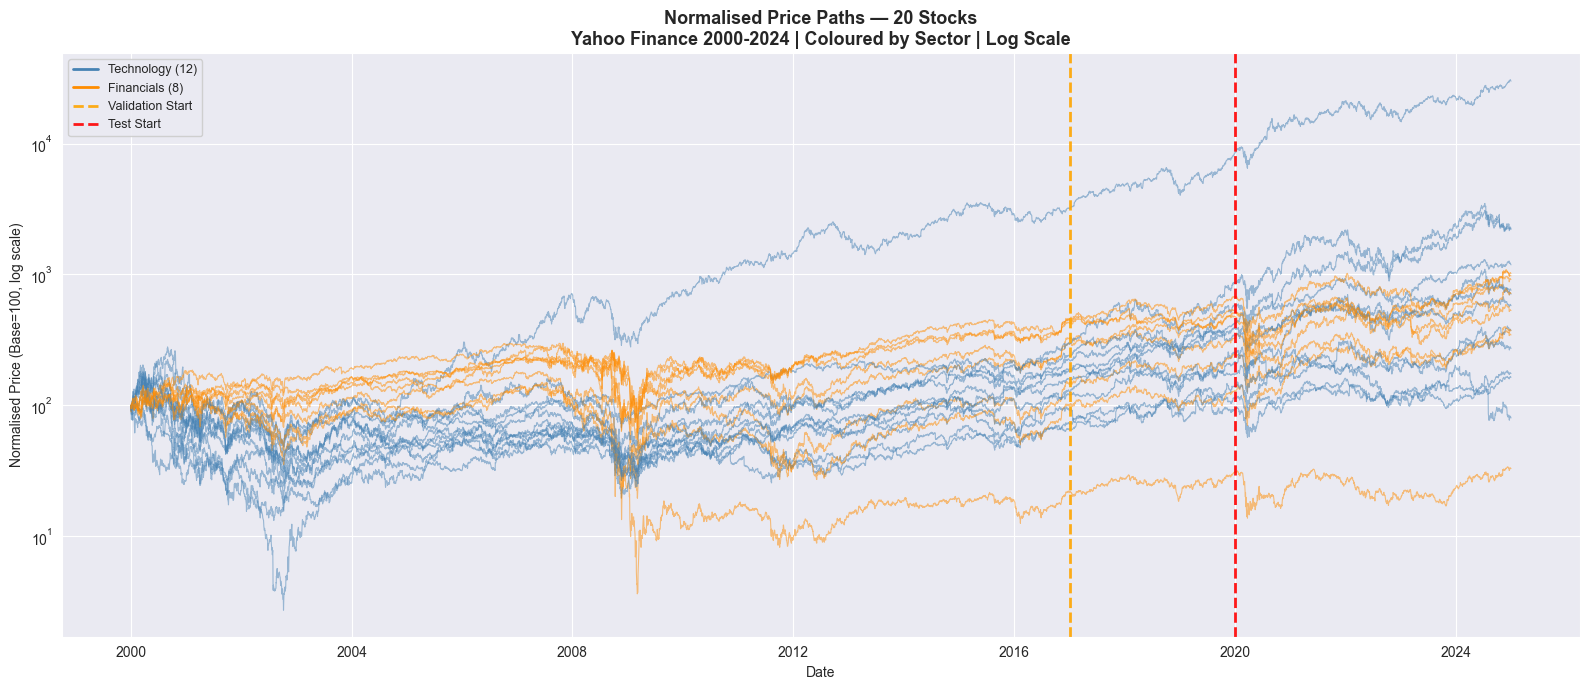

Plot 1 saved: price_paths.png


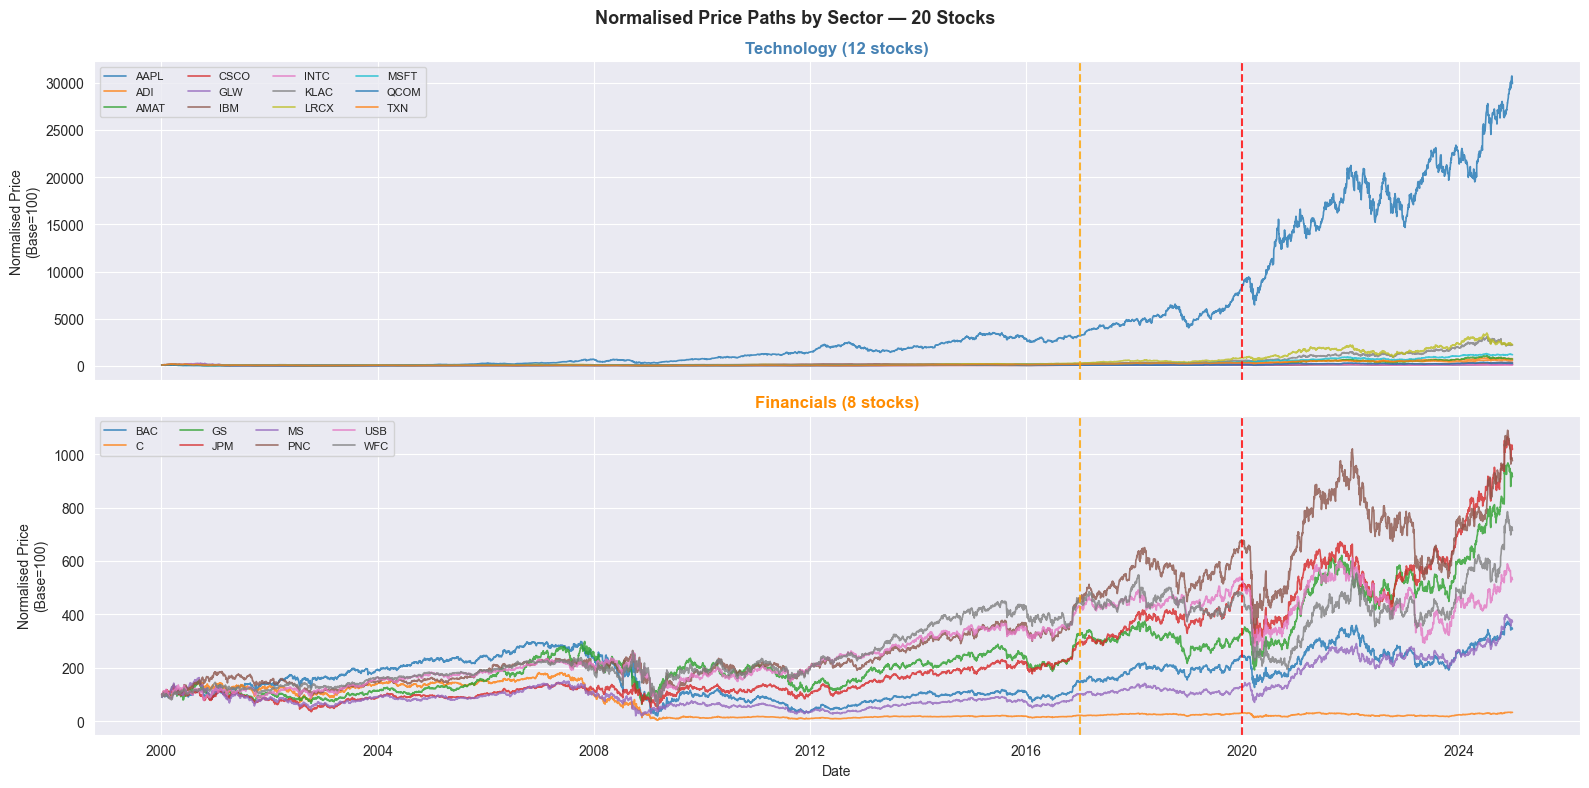

Plot 2 saved: price_paths_by_sector.png


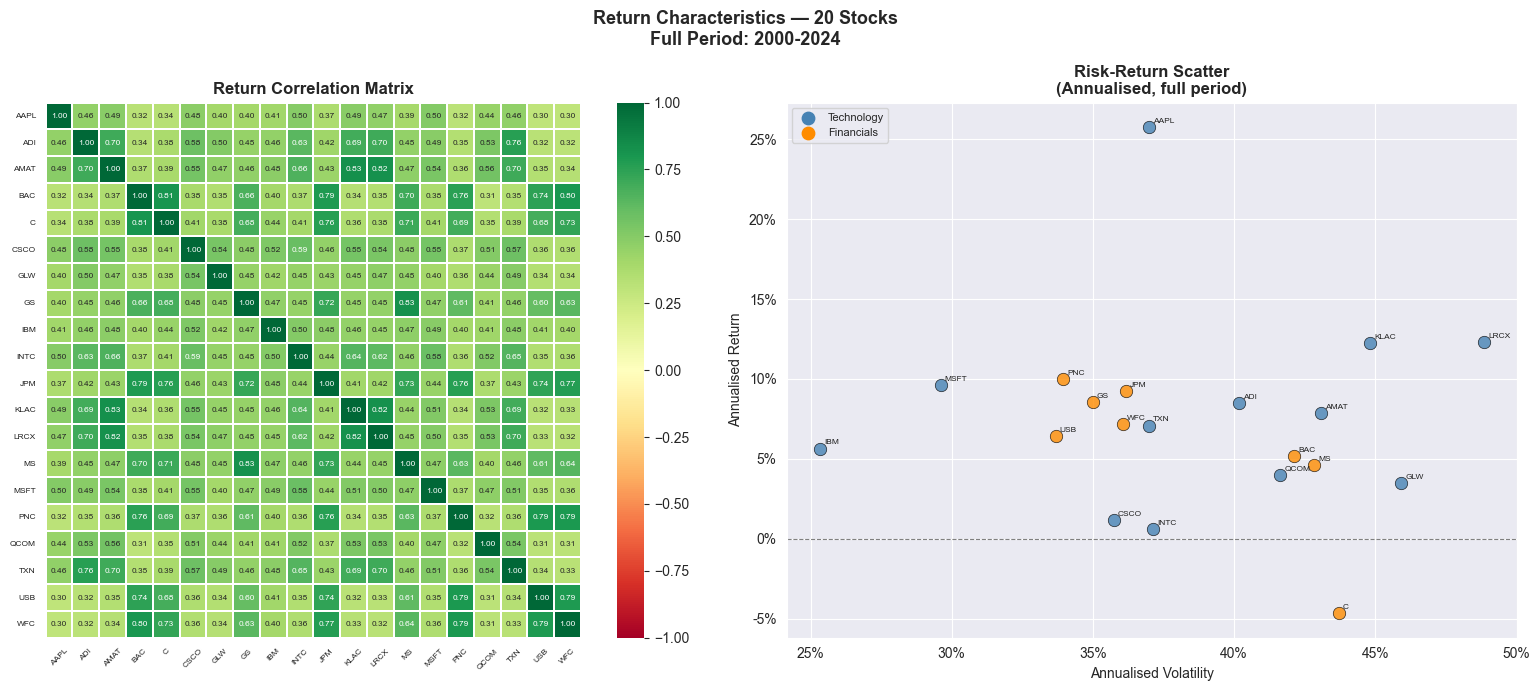

Plot 3 saved: return_characteristics.png

DATA SUMMARY:
  Asset pool    : 20 stocks
  N_ASSETS      : 20
  Training days : 4,276
  Val days      : 754
  Test days     : 1,257

Cell 7 complete


In [8]:
# ============================================================
# CELL 7: VISUALISE THE DATASET
# ============================================================
# Three plots:
#   Plot 1: Normalised price paths coloured by sector
#           Shows long-run performance of all stocks
#   Plot 2: Sector-level price paths in separate subplots
#           Allows individual stocks to be seen clearly
#   Plot 3: Correlation matrix and risk-return scatter
#           This mirrors a key figure in the original paper
# ============================================================

# Normalise all prices to 100 on the first trading day
# so all stocks can be compared on the same scale
# regardless of their absolute price level
normalised = (prices / prices.iloc[0]) * 100

# ---- PLOT 1: All stocks together with log scale ----
fig1, ax1 = plt.subplots(figsize=(16, 7))

for ticker in normalised.columns:
    sector = SECTOR_MAP.get(ticker, 'Other')
    colour = SECTOR_COLOURS.get(sector, 'grey')
    ax1.plot(
        normalised.index,
        normalised[ticker],
        color     = colour,
        linewidth = 0.8,
        alpha     = 0.5     # semi-transparent so all lines are visible
    )

# Add a legend entry for each sector (not each individual stock)
for sector, colour in SECTOR_COLOURS.items():
    sector_tickers = [t for t in TICKERS if SECTOR_MAP.get(t) == sector]
    if len(sector_tickers) > 0:
        ax1.plot([], [], color=colour, linewidth=2,
                 label=f'{sector} ({len(sector_tickers)})')

# Add vertical lines marking the split boundaries
for date, label, colour in [
    ('2017-01-01', 'Validation Start', 'orange'),
    ('2020-01-01', 'Test Start',       'red'),
]:
    ax1.axvline(pd.Timestamp(date), color=colour,
                linewidth=2, linestyle='--', label=label, alpha=0.9)

# Use log scale so AAPL's extreme growth does not flatten all other stocks
ax1.set_yscale('log')
ax1.set_title(
    f'Normalised Price Paths — {DATA_POOL} Stocks\n'
    f'Yahoo Finance 2000-2024 | Coloured by Sector | Log Scale',
    fontsize=13, fontweight='bold')
ax1.set_ylabel('Normalised Price (Base=100, log scale)')
ax1.set_xlabel('Date')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_FOLDER, 'price_paths.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved: price_paths.png")

# ---- PLOT 2: Sector subplots ----
# Only include sectors that have stocks in the current pool
sectors_to_plot = []
for sector in ['Technology', 'Financials', 'Healthcare', 'Energy', 'Consumer']:
    tickers_in_sector = [t for t in TICKERS if SECTOR_MAP.get(t) == sector]
    if len(tickers_in_sector) > 0:
        sectors_to_plot.append((sector, tickers_in_sector))

n_sectors = len(sectors_to_plot)
fig2, axes2 = plt.subplots(n_sectors, 1, figsize=(16, 4 * n_sectors), sharex=True)

if n_sectors == 1:
    axes2 = [axes2]   # make iterable if only one sector

fig2.suptitle(
    f'Normalised Price Paths by Sector — {DATA_POOL} Stocks',
    fontsize=13, fontweight='bold')

for ax, (sector, sector_tickers) in zip(axes2, sectors_to_plot):
    colour = SECTOR_COLOURS.get(sector, 'grey')
    for ticker in sector_tickers:
        if ticker in normalised.columns:
            ax.plot(normalised.index, normalised[ticker],
                    linewidth=1.2, alpha=0.8, label=ticker)
    for date, split_colour, style in [
        ('2017-01-01', 'orange', '--'),
        ('2020-01-01', 'red',    '--'),
    ]:
        ax.axvline(pd.Timestamp(date), color=split_colour,
                   linewidth=1.5, linestyle=style, alpha=0.8)
    ax.set_title(f'{sector} ({len(sector_tickers)} stocks)',
                 fontweight='bold', color=colour)
    ax.set_ylabel('Normalised Price\n(Base=100)')
    ax.legend(fontsize=8, loc='upper left', ncol=4, framealpha=0.8)

axes2[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(os.path.join(DATA_FOLDER, 'price_paths_by_sector.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved: price_paths_by_sector.png")

# ---- PLOT 3: Correlation matrix and risk-return scatter ----
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7))
fig3.suptitle(
    f'Return Characteristics — {DATA_POOL} Stocks\nFull Period: 2000-2024',
    fontsize=13, fontweight='bold')

# Left panel: pairwise correlation heatmap
corr = log_returns.corr()   # pairwise Pearson correlation
sns.heatmap(
    corr,
    annot    = DATA_POOL <= 30,   # only show numbers if 30 or fewer stocks
    fmt      = '.2f',
    cmap     = 'RdYlGn',
    center   = 0,
    vmin     = -1, vmax = 1,
    square   = True,
    linewidths = 0.3,
    ax       = axes3[0],
    annot_kws= {'size': 6}
)
axes3[0].set_title('Return Correlation Matrix', fontweight='bold')
axes3[0].tick_params(axis='x', rotation=45, labelsize=6)
axes3[0].tick_params(axis='y', rotation=0,  labelsize=6)

# Right panel: annualised risk-return scatter coloured by sector
mean_returns = log_returns.mean() * 252          # annualised mean return
std_returns  = log_returns.std() * np.sqrt(252)  # annualised volatility

for ticker in log_returns.columns:
    sector = SECTOR_MAP.get(ticker, 'Consumer')
    colour = SECTOR_COLOURS.get(sector, 'grey')
    axes3[1].scatter(
        std_returns[ticker],    # volatility on x-axis
        mean_returns[ticker],   # return on y-axis
        color=colour, alpha=0.8, s=80,
        edgecolors='black', linewidths=0.5
    )
    axes3[1].annotate(ticker,
        (std_returns[ticker], mean_returns[ticker]),
        fontsize=6, xytext=(3, 3), textcoords='offset points')

for sector, colour in SECTOR_COLOURS.items():
    if any(SECTOR_MAP.get(t) == sector for t in TICKERS):
        axes3[1].scatter([], [], color=colour, label=sector, s=80)

axes3[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes3[1].set_title('Risk-Return Scatter\n(Annualised, full period)', fontweight='bold')
axes3[1].set_xlabel('Annualised Volatility')
axes3[1].set_ylabel('Annualised Return')
axes3[1].legend(fontsize=8, loc='upper left')
axes3[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))
axes3[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))

plt.tight_layout()
plt.savefig(os.path.join(DATA_FOLDER, 'return_characteristics.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved: return_characteristics.png")

print(f"\nDATA SUMMARY:")
print(f"  Asset pool    : {DATA_POOL} stocks")
print(f"  N_ASSETS      : {N_ASSETS}")
print(f"  Training days : {len(train_returns):,}")
print(f"  Val days      : {len(val_returns):,}")
print(f"  Test days     : {len(test_returns):,}")
print(f"\nCell 7 complete")

In [9]:
# ============================================================
# CELL 8: SAVE ALL DATA TO DISK
# ============================================================
# Save every data file needed by later cells so they can
# be reloaded if the kernel is restarted between runs.
# ============================================================

prices.to_csv(os.path.join(DATA_FOLDER, 'clean_prices.csv'))
print("Saved: clean_prices.csv")

log_returns.to_csv(os.path.join(DATA_FOLDER, 'log_returns.csv'))
print("Saved: log_returns.csv")

train_returns.to_csv(os.path.join(DATA_FOLDER, 'train_returns.csv'))
print("Saved: train_returns.csv")

val_returns.to_csv(os.path.join(DATA_FOLDER, 'val_returns.csv'))
print("Saved: val_returns.csv")

test_returns.to_csv(os.path.join(DATA_FOLDER, 'test_returns.csv'))
print("Saved: test_returns.csv")

# Save a configuration dictionary so any later cell can
# reload the exact settings used in this run without
# having to re-run Cells 1 through 7
config = {
    'DATA_POOL'    : DATA_POOL,
    'DATA_FOLDER'  : DATA_FOLDER,
    'SIG_FOLDER'   : SIG_FOLDER,
    'MODELS_FOLDER': MODELS_FOLDER,
    'ROBUST_FOLDER': ROBUST_FOLDER,
    'N_ASSETS'     : N_ASSETS,
    'TICKERS'      : TICKERS,
    'LOOKBACK'     : LOOKBACK,
    'SIG_ORDER'    : SIG_ORDER,
    'TRAIN_START'  : TRAIN_START,
    'TRAIN_END'    : TRAIN_END,
    'VAL_START'    : VAL_START,
    'VAL_END'      : VAL_END,
    'TEST_START'   : TEST_START,
    'TEST_END'     : TEST_END,
}

config_path = os.path.join(DATA_FOLDER, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)   # indent=2 makes the file human-readable
print("Saved: config.json")

# Verify all files were created successfully
print(f"\nVerifying saved files in {DATA_FOLDER}/:")
expected = [
    'clean_prices.csv', 'log_returns.csv',
    'train_returns.csv', 'val_returns.csv',
    'test_returns.csv',  'config.json'
]
all_ok = True
for fname in expected:
    fpath  = os.path.join(DATA_FOLDER, fname)
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) / 1024 if exists else 0
    status = "OK" if exists else "MISSING"
    print(f"  {status}  {fname} ({size:.1f} KB)")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\nAll files saved successfully")
else:
    print(f"\nWARNING: Some files are missing")

print(f"\n{'='*50}")
print(f"  SECTION 1 COMPLETE: DATA COLLECTION")
print(f"  N_ASSETS : {N_ASSETS}")
print(f"  Next     : Cell 9 — Path Signatures")
print(f"{'='*50}")
print(f"\nCell 8 complete")

Saved: clean_prices.csv
Saved: log_returns.csv
Saved: train_returns.csv
Saved: val_returns.csv
Saved: test_returns.csv
Saved: config.json

Verifying saved files in data_paper_20/:
  OK  clean_prices.csv (2321.7 KB)
  OK  log_returns.csv (2685.1 KB)
  OK  train_returns.csv (1822.3 KB)
  OK  val_returns.csv (324.3 KB)
  OK  test_returns.csv (538.7 KB)
  OK  config.json (0.7 KB)

All files saved successfully

  SECTION 1 COMPLETE: DATA COLLECTION
  N_ASSETS : 20
  Next     : Cell 9 — Path Signatures

Cell 8 complete


In [10]:
# ============================================================
# CELL 9: COMPUTE PATH SIGNATURE FEATURES
# ============================================================
# SECTION 2: PATH SIGNATURES
#
# What is a path signature?
# A path signature transforms a time series into a structured
# collection of numbers called iterated integrals. These numbers
# capture not just WHERE prices ended up, but the SHAPE of the
# journey — including the temporal order in which assets moved.
#
# Why use signatures instead of raw returns?
# Raw returns tell you the total move of each stock.
# Signatures additionally tell you things like:
#   "Asset A rose, then Asset B fell in response"
# versus
#   "Asset B fell, then Asset A rose in response"
# These two scenarios look identical in a correlation matrix
# but produce different signed areas in the second-order
# signature cross-term. This lead-lag information is the
# structural advantage of the SIT over classical methods.
#
# How we compute them:
#   For each trading day t we take the last LOOKBACK=20 days
#   of returns, convert them to a cumulative path by running
#   sum, and compute the truncated signature of that path.
#   This produces one feature vector per day.
#
# Feature vector size:
#   Order 2 with d assets: (d^3 - 1) / (d - 1) - 1
#   For d=50: 2,550 features per day
#   For d=20: 420 features per day
# ============================================================

import iisignature   # path signature computation library

def compute_signatures(returns_df, lookback, sig_order, split_name='split'):
    """
    Compute path signature features using a sliding window.

    For each day t starting from day 'lookback':
      1. Extract the window of returns from day t-lookback to t
      2. Convert to a cumulative path by taking the running sum
         Signatures work better on smooth cumulative paths
         than on raw return jumps
      3. Compute the truncated signature of that path using
         the iisignature library
      4. Store as one row in the feature matrix

    Parameters
    ----------
    returns_df : pd.DataFrame, shape (T, N_ASSETS)
        Daily log returns for this split
    lookback : int
        Number of days in each sliding window
    sig_order : int
        Signature truncation order (2 or 3)
    split_name : str
        Label printed in the progress output

    Returns
    -------
    features : np.ndarray, shape (T - lookback, n_terms)
        Signature feature matrix. One row per trading day.
    dates : pd.DatetimeIndex
        Dates corresponding to each row (window end points)
    """

    returns_array = returns_df.values     # convert to numpy for speed
    T             = returns_array.shape[0]  # total time steps
    d             = returns_array.shape[1]  # number of assets

    # Compute the number of terms in the feature vector
    # Formula for truncated signature at order M with d assets:
    # n_terms = (d^(M+1) - 1) / (d - 1) - 1
    n_terms = int((d**(sig_order+1) - 1) / (d - 1)) - 1

    # Number of windows we can extract
    n_windows = T - lookback

    # Pre-allocate the output array for speed
    features = np.zeros((n_windows, n_terms))

    print(f"  Computing {split_name}: "
          f"{n_windows} windows, "
          f"{n_terms:,} features each...")

    for i in range(n_windows):
        # Extract one window of length 'lookback'
        # Rows i to i+lookback (exclusive)
        window = returns_array[i : i + lookback]

        # Convert raw returns to a cumulative path
        # np.cumsum adds each day's return to the previous total
        # This creates a smooth path that is better suited
        # for signature computation than raw return jumps
        cumulative_path = np.cumsum(window, axis=0)

        # Compute the truncated path signature
        # iisignature.sig returns a 1D feature vector
        sig = iisignature.sig(cumulative_path, sig_order)

        # Store the result in the output array
        features[i] = sig

        # Print progress every 500 windows
        if (i + 1) % 500 == 0:
            pct = (i + 1) / n_windows * 100
            print(f"    {i+1}/{n_windows} ({pct:.0f}%)")

    # Dates correspond to the END of each window
    # The first window covers days 0 to lookback
    # so its date is day 'lookback'
    dates = returns_df.index[lookback:]

    print(f"  {split_name} complete. Shape: {features.shape}")
    return features, dates


# Compute signatures for all three splits
print(f"\n{'='*55}")
print(f"  COMPUTING PATH SIGNATURES")
print(f"  Order: {SIG_ORDER} | Lookback: {LOOKBACK} days")
print(f"{'='*55}")

print("\nTraining signatures:")
train_features, train_sig_dates = compute_signatures(
    train_returns, LOOKBACK, SIG_ORDER, 'Training')

print("\nValidation signatures:")
val_features, val_sig_dates = compute_signatures(
    val_returns, LOOKBACK, SIG_ORDER, 'Validation')

print("\nTest signatures:")
test_features, test_sig_dates = compute_signatures(
    test_returns, LOOKBACK, SIG_ORDER, 'Test')

# Print a summary of what was produced
print(f"\nSIGNATURE COMPUTATION COMPLETE:")
print(f"{'─'*50}")
print(f"  Training features   : {train_features.shape}")
print(f"  Validation features : {val_features.shape}")
print(f"  Test features       : {test_features.shape}")
print(f"  Feature vector size : {train_features.shape[1]:,}")
print(f"{'─'*50}")
print(f"\nCell 9 complete")


  COMPUTING PATH SIGNATURES
  Order: 2 | Lookback: 20 days

Training signatures:
  Computing Training: 4256 windows, 420 features each...
    500/4256 (12%)
    1000/4256 (23%)
    1500/4256 (35%)
    2000/4256 (47%)
    2500/4256 (59%)
    3000/4256 (70%)
    3500/4256 (82%)
    4000/4256 (94%)
  Training complete. Shape: (4256, 420)

Validation signatures:
  Computing Validation: 734 windows, 420 features each...
    500/734 (68%)
  Validation complete. Shape: (734, 420)

Test signatures:
  Computing Test: 1237 windows, 420 features each...
    500/1237 (40%)
    1000/1237 (81%)
  Test complete. Shape: (1237, 420)

SIGNATURE COMPUTATION COMPLETE:
──────────────────────────────────────────────────
  Training features   : (4256, 420)
  Validation features : (734, 420)
  Test features       : (1237, 420)
  Feature vector size : 420
──────────────────────────────────────────────────

Cell 9 complete


In [11]:
# ============================================================
# CELL 10: NORMALISE AND ALIGN SIGNATURE FEATURES
# ============================================================
# Two tasks happen in this cell:
#
# PART A: NORMALISE FEATURES
#   Neural networks train much better when input features
#   are all on a similar scale. Raw signature values can
#   vary enormously across features — some may be near zero
#   while others may be in the hundreds. This makes gradient
#   descent unstable and slow.
#
#   We use StandardScaler which transforms each feature to
#   have mean 0 and standard deviation 1. This is called
#   z-score normalisation.
#
#   CRITICAL RULE: We fit the scaler ONLY on training data.
#   We then apply those same training statistics to the
#   validation and test sets. If we used validation or test
#   statistics to normalise, the model would indirectly see
#   future information during training — this is data leakage
#   and would invalidate all results.
#
# PART B: ALIGN RETURNS WITH FEATURES
#   The signature feature for day t is computed from returns
#   over days t-LOOKBACK to t. We use this feature to predict
#   the portfolio allocation for day t, which then earns the
#   return on day t+1.
#
#   So the correct alignment is:
#     features[t] -> predicts weights for day t
#     weights for day t -> earns return on day t+1
#
#   To implement this we:
#     - Skip the first LOOKBACK+1 rows of the returns
#       (no feature available for these early days)
#     - Drop the last row of features
#       (no next-day return available for the final feature)
#
#   After alignment, features[i] corresponds to returns[i]
#   where returns[i] is what the portfolio earns on day i+1.
# ============================================================

from sklearn.preprocessing import StandardScaler
# StandardScaler normalises features to mean=0 and std=1

# ============================================================
# PART A: NORMALISE FEATURES
# ============================================================

print(f"{'='*55}")
print(f"  PART A: FEATURE NORMALISATION")
print(f"{'='*55}")

# Create a new StandardScaler object
# This object will learn the mean and std from training data
scaler = StandardScaler()

# fit_transform on training data:
#   fit    = compute the mean and std of each feature column
#   transform = subtract mean and divide by std
# Both operations happen in one step
train_features_scaled = scaler.fit_transform(train_features)

# transform (NOT fit_transform) on validation data:
#   We apply the TRAINING mean and std to the validation set
#   This is essential to prevent data leakage
val_features_scaled = scaler.transform(val_features)

# transform (NOT fit_transform) on test data:
#   We apply the same TRAINING mean and std to the test set
test_features_scaled = scaler.transform(test_features)

# Verify normalisation worked correctly
# Training should have mean very close to 0 and std close to 1
# Validation and test will be close but not exact because
# they use training statistics applied to different data
print(f"\nNormalisation verification:")
print(f"  Training   — mean: "
      f"{train_features_scaled.mean():.6f}  "
      f"std: {train_features_scaled.std():.6f}")
print(f"  Validation — mean: "
      f"{val_features_scaled.mean():.6f}  "
      f"std: {val_features_scaled.std():.6f}")
print(f"  Test       — mean: "
      f"{test_features_scaled.mean():.6f}  "
      f"std: {test_features_scaled.std():.6f}")
print(f"\n  Training mean should be ~0 and std should be ~1")
print(f"  Val and test will be close but not exact")
print(f"  because they use training statistics")

# ============================================================
# PART B: ALIGN RETURNS WITH FEATURES
# ============================================================

print(f"\n{'='*55}")
print(f"  PART B: ALIGNING RETURNS WITH FEATURES")
print(f"{'='*55}")

# The sliding window starting at position i uses returns
# from rows i to i+LOOKBACK. So the feature for position i
# is associated with return at position i+LOOKBACK+1
# (the next day after the window ends).
#
# To align them we:
#   Returns: skip the first LOOKBACK+1 rows
#   Features: drop the last row
# Then features[i] pairs with returns[i+LOOKBACK+1]
# which is exactly the next-day return the portfolio earns.

# Training alignment
train_returns_aligned = train_returns.iloc[LOOKBACK+1:].values
# .values converts to numpy array
# .iloc[LOOKBACK+1:] skips the first LOOKBACK+1 rows
train_features_final  = train_features_scaled[:-1]
# [:-1] drops the last row of features
train_dates_final     = train_sig_dates[:-1]
# drop the last date to match

# Validation alignment (same logic)
val_returns_aligned = val_returns.iloc[LOOKBACK+1:].values
val_features_final  = val_features_scaled[:-1]
val_dates_final     = val_sig_dates[:-1]

# Test alignment (same logic)
test_returns_aligned = test_returns.iloc[LOOKBACK+1:].values
test_features_final  = test_features_scaled[:-1]
test_dates_final     = test_sig_dates[:-1]

# Print the shapes to verify alignment is correct
print(f"\nAlignment verification:")
print(f"  Training   — features: {train_features_final.shape} "
      f"| returns: {train_returns_aligned.shape}")
print(f"  Validation — features: {val_features_final.shape} "
      f"| returns: {val_returns_aligned.shape}")
print(f"  Test       — features: {test_features_final.shape} "
      f"| returns: {test_returns_aligned.shape}")

# Assert that the first dimension (number of samples) matches
# for features and returns in each split
# If these fail it means alignment went wrong
assert train_features_final.shape[0] == \
    train_returns_aligned.shape[0], \
    "Training alignment failed: sample counts do not match"
assert val_features_final.shape[0] == \
    val_returns_aligned.shape[0], \
    "Validation alignment failed: sample counts do not match"
assert test_features_final.shape[0] == \
    test_returns_aligned.shape[0], \
    "Test alignment failed: sample counts do not match"

print(f"\nAll alignment checks passed")

# Store N_FEATURES for use in later cells
# This is the number of signature features per day
N_FEATURES = train_features_final.shape[1]
print(f"\nN_FEATURES = {N_FEATURES:,}")

print(f"\nCell 10 complete")

  PART A: FEATURE NORMALISATION

Normalisation verification:
  Training   — mean: -0.000000  std: 1.000000
  Validation — mean: -0.104833  std: 0.386477
  Test       — mean: 0.005986  std: 0.912317

  Training mean should be ~0 and std should be ~1
  Val and test will be close but not exact
  because they use training statistics

  PART B: ALIGNING RETURNS WITH FEATURES

Alignment verification:
  Training   — features: (4255, 420) | returns: (4255, 20)
  Validation — features: (733, 420) | returns: (733, 20)
  Test       — features: (1236, 420) | returns: (1236, 20)

All alignment checks passed

N_FEATURES = 420

Cell 10 complete


In [12]:
# ============================================================
# CELL 11: SAVE SIGNATURE FEATURES TO DISK
# ============================================================
# We save all signature feature arrays and dates to disk
# so that later cells can reload them if the kernel
# is restarted without having to recompute signatures.
#
# Signature computation takes 5-15 minutes so saving
# these arrays avoids repeating that work.
#
# We use numpy .npy format for arrays because:
#   - It is much faster to load than CSV
#   - It preserves exact float precision
#   - Loading is nearly instantaneous
#
# Dates are saved as CSV because numpy cannot store
# datetime objects natively.
#
# We also save the fitted scaler object using pickle
# so it can be reused in walk-forward validation without
# refitting on different data (which would change the
# normalisation statistics and make results incomparable).
# ============================================================

# ---- Save signature feature arrays ----
# Each array is a matrix of shape (T, N_FEATURES)
# where T is the number of aligned trading days

np.save(
    os.path.join(SIG_FOLDER, 'train_features.npy'),
    train_features_final   # training features shape (T_train, 2550)
)
print("Saved: train_features.npy")

np.save(
    os.path.join(SIG_FOLDER, 'val_features.npy'),
    val_features_final     # validation features shape (T_val, 2550)
)
print("Saved: val_features.npy")

np.save(
    os.path.join(SIG_FOLDER, 'test_features.npy'),
    test_features_final    # test features shape (T_test, 2550)
)
print("Saved: test_features.npy")

# ---- Save aligned returns arrays ----
# Each array is a matrix of shape (T, N_ASSETS)
# These are the next-day returns the portfolio earns

np.save(
    os.path.join(SIG_FOLDER, 'train_returns_aligned.npy'),
    train_returns_aligned  # shape (T_train, N_ASSETS)
)
print("Saved: train_returns_aligned.npy")

np.save(
    os.path.join(SIG_FOLDER, 'val_returns_aligned.npy'),
    val_returns_aligned    # shape (T_val, N_ASSETS)
)
print("Saved: val_returns_aligned.npy")

np.save(
    os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'),
    test_returns_aligned   # shape (T_test, N_ASSETS)
)
print("Saved: test_returns_aligned.npy")

# ---- Save dates as CSV ----
# We save the date index so later cells know which
# calendar date each feature row corresponds to
# This is used for stress scenario testing and plotting

pd.Series(
    train_dates_final.values,  # array of datetime values
    name='date'
).to_csv(
    os.path.join(SIG_FOLDER, 'train_dates.csv'),
    index=False                # do not write row numbers
)
print("Saved: train_dates.csv")

pd.Series(
    val_dates_final.values,
    name='date'
).to_csv(
    os.path.join(SIG_FOLDER, 'val_dates.csv'),
    index=False
)
print("Saved: val_dates.csv")

pd.Series(
    test_dates_final.values,
    name='date'
).to_csv(
    os.path.join(SIG_FOLDER, 'test_dates.csv'),
    index=False
)
print("Saved: test_dates.csv")

# ---- Save the fitted scaler ----
# pickle saves a Python object to a binary file
# We use 'wb' which means write in binary mode
# The scaler stores the training mean and std for each feature
# Saving it means walk-forward cells can apply the same
# normalisation statistics without refitting

with open(os.path.join(SIG_FOLDER, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)   # write scaler object to file
print("Saved: scaler.pkl")

# ---- Save signature configuration ----
# Store N_FEATURES and other key dimensions in a JSON file
# This allows later cells to know the feature vector size
# without having to reload all the large arrays first

sig_config = {
    'N_FEATURES' : N_FEATURES,   # 2550 for 50 stocks at order 2
    'N_ASSETS'   : N_ASSETS,     # 50
    'LOOKBACK'   : LOOKBACK,     # 20
    'SIG_ORDER'  : SIG_ORDER,    # 2
    'train_shape': list(train_features_final.shape),
    'val_shape'  : list(val_features_final.shape),
    'test_shape' : list(test_features_final.shape),
}

with open(os.path.join(SIG_FOLDER, 'sig_config.json'), 'w') as f:
    json.dump(sig_config, f, indent=2)   # indent=2 for readability
print("Saved: sig_config.json")

# ---- Verify all files were created ----
print(f"\nVerifying saved files in {SIG_FOLDER}/:")
expected_files = [
    'train_features.npy',
    'val_features.npy',
    'test_features.npy',
    'train_returns_aligned.npy',
    'val_returns_aligned.npy',
    'test_returns_aligned.npy',
    'train_dates.csv',
    'val_dates.csv',
    'test_dates.csv',
    'scaler.pkl',
    'sig_config.json',
]

all_saved = True
for filename in expected_files:
    filepath = os.path.join(SIG_FOLDER, filename)
    exists   = os.path.exists(filepath)
    size_kb  = (
        os.path.getsize(filepath) / 1024
        if exists else 0
    )
    status = "OK" if exists else "MISSING"
    print(f"  {status}  {filename} ({size_kb:.1f} KB)")
    if not exists:
        all_saved = False

if all_saved:
    print(f"\nAll 11 files saved successfully")
else:
    print(f"\nWARNING: Some files are missing")

print(f"\n{'='*55}")
print(f"  SECTION 2 COMPLETE: PATH SIGNATURES")
print(f"  N_FEATURES : {N_FEATURES:,}")
print(f"  N_ASSETS   : {N_ASSETS}")
print(f"  SIG_ORDER  : {SIG_ORDER}")
print(f"  LOOKBACK   : {LOOKBACK} days")
print(f"{'='*55}")
print(f"\nCell 11 complete")
print(f"Next: Cell 12 — SIT Model Architecture")

Saved: train_features.npy
Saved: val_features.npy
Saved: test_features.npy
Saved: train_returns_aligned.npy
Saved: val_returns_aligned.npy
Saved: test_returns_aligned.npy
Saved: train_dates.csv
Saved: val_dates.csv
Saved: test_dates.csv
Saved: scaler.pkl
Saved: sig_config.json

Verifying saved files in data_paper_20\signatures/:
  OK  train_features.npy (13961.8 KB)
  OK  val_features.npy (2405.3 KB)
  OK  test_features.npy (4055.8 KB)
  OK  train_returns_aligned.npy (665.0 KB)
  OK  val_returns_aligned.npy (114.7 KB)
  OK  test_returns_aligned.npy (193.2 KB)
  OK  train_dates.csv (49.9 KB)
  OK  val_dates.csv (8.6 KB)
  OK  test_dates.csv (14.5 KB)
  OK  scaler.pkl (10.3 KB)
  OK  sig_config.json (0.2 KB)

All 11 files saved successfully

  SECTION 2 COMPLETE: PATH SIGNATURES
  N_FEATURES : 420
  N_ASSETS   : 20
  SIG_ORDER  : 2
  LOOKBACK   : 20 days

Cell 11 complete
Next: Cell 12 — SIT Model Architecture


In [13]:
# ============================================================
# CELL 12: DEFINE THE SIT MODEL ARCHITECTURE
# ============================================================
# SECTION 3: MODEL TRAINING
#
# The Signature-Informed Transformer (SIT) architecture
# has four sequential components:
#
# 1. INPUT PROJECTION
#    A single linear layer that maps the large signature
#    feature vector (2550 dimensions) down to the model's
#    internal dimension (d_model = 64).
#    This layer learns which combinations of signature
#    features are most useful for portfolio allocation.
#    Formula: output = W * input + b
#    where W is a 64 x 2550 weight matrix.
#
# 2. TRANSFORMER ENCODER
#    Two stacked Transformer encoder layers, each with
#    four attention heads. The encoder applies multi-head
#    self-attention to learn which parts of the projected
#    features matter most for making allocation decisions.
#    Each attention head learns a different type of
#    relationship within the feature representation.
#
# 3. OUTPUT PROJECTION
#    A single linear layer that maps the 64-dimensional
#    Transformer output to N_ASSETS dimensions, producing
#    one raw score per stock.
#
# 4. SOFTMAX
#    Converts the raw scores to portfolio weights.
#    Softmax ensures all weights are strictly positive
#    and sum to exactly 1.0, enforcing a long-only
#    fully-invested portfolio at all times.
#
# The architecture is IDENTICAL for all five models.
# The only thing that differs across models is the
# loss function used during training.
# This controlled design ensures observed performance
# differences are caused by the loss function alone.
# ============================================================

import torch                # PyTorch core framework
import torch.nn as nn       # neural network building blocks
import numpy as np          # numerical operations
import json                 # loading config files
import os                   # file path operations

# ---- Safety reload block ----
# If the kernel was restarted this block reloads all
# variables that are needed for this cell to run.
# It checks each variable and reloads it if missing.

try:
    set_all_seeds    # check if seed function is available
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock all random seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['PYTHONHASHSEED']       = str(seed)
    print("set_all_seeds redefined")

try:
    GLOBAL_SEED   # check if seed constant is available
except NameError:
    GLOBAL_SEED = 42   # default seed value
    print(f"GLOBAL_SEED set to {GLOBAL_SEED}")

try:
    DEVICE   # check if device is set
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE set to {DEVICE}")

try:
    DATA_FOLDER    # check if folder paths are set
    SIG_FOLDER
    MODELS_FOLDER
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    os.makedirs(MODELS_FOLDER, exist_ok=True)
    print(f"Folder paths set to defaults")

try:
    N_FEATURES    # check if feature size is known
    N_ASSETS
except NameError:
    # Reload from saved config file
    with open(os.path.join(SIG_FOLDER, 'sig_config.json')) as f:
        sig_config = json.load(f)
    N_FEATURES = sig_config['N_FEATURES']   # 2550 features
    N_ASSETS   = sig_config['N_ASSETS']     # 50 stocks
    print(f"N_FEATURES loaded: {N_FEATURES}")
    print(f"N_ASSETS loaded  : {N_ASSETS}")

try:
    D_MODEL    # check if model hyperparameters are set
    N_HEADS
    N_LAYERS
    DROPOUT
    BATCH_SIZE
    DATA_POOL
except NameError:
    D_MODEL    = 64     # Transformer internal dimension
    N_HEADS    = 4      # number of attention heads
    N_LAYERS   = 2      # number of encoder layers
    DROPOUT    = 0.1    # dropout regularisation rate
    BATCH_SIZE = 64     # training batch size
    DATA_POOL  = 50     # default to 50 stocks
    print("Model hyperparameters set to defaults")

# Print confirmed values so we know what will be used
print(f"\nVariables confirmed for Cell 12:")
print(f"  N_FEATURES : {N_FEATURES}")
print(f"  N_ASSETS   : {N_ASSETS}")
print(f"  D_MODEL    : {D_MODEL}")
print(f"  N_HEADS    : {N_HEADS}")
print(f"  N_LAYERS   : {N_LAYERS}")
print(f"  DROPOUT    : {DROPOUT}")
print(f"  DEVICE     : {DEVICE}")


# ============================================================
# SIT MODEL CLASS DEFINITION
# ============================================================

class SIT(nn.Module):
    """
    Signature-Informed Transformer for Portfolio Allocation.

    Replication of Hwang and Zohren (2025).

    This model takes path signature features as input and
    outputs portfolio weights. It is trained end-to-end
    against a chosen risk objective — no separate return
    forecasting step is involved.

    Architecture:
        Input -> Linear(n_features, d_model)
              -> TransformerEncoder(d_model, n_heads, n_layers)
              -> Linear(d_model, n_assets)
              -> Softmax
        Output: portfolio weights (positive, sum to 1)
    """

    def __init__(
        self,
        n_features,   # size of the input signature feature vector
        n_assets,     # number of stocks in the portfolio
        d_model=64,   # internal Transformer dimension
        n_heads=4,    # number of parallel attention heads
        n_layers=2,   # number of stacked Transformer layers
        dropout=0.1   # fraction of connections dropped during training
    ):
        """
        Initialise all layers of the SIT model.

        Parameters
        ----------
        n_features : int
            Size of the signature feature vector.
            2550 for 50 assets at order 2.
        n_assets : int
            Number of stocks. Also the output dimension.
        d_model : int
            Internal representation size. All Transformer
            layers use this dimension.
        n_heads : int
            Number of parallel attention heads. Each head
            learns a different type of relationship.
        n_layers : int
            Number of stacked Transformer encoder layers.
            More layers can learn more complex patterns
            but increase risk of overfitting.
        dropout : float
            Probability of randomly zeroing activations
            during training. Prevents overfitting by forcing
            the model not to rely on any single pathway.
        """

        # Always call super().__init__() first when defining
        # a PyTorch model class. This registers the layers
        # with PyTorch's internal tracking system.
        super(SIT, self).__init__()

        # Store dimensions as attributes for reference
        self.n_features = n_features
        self.n_assets   = n_assets
        self.d_model    = d_model

        # ---- Layer 1: Input Projection ----
        # A linear layer maps the high-dimensional signature
        # feature vector down to the model's internal dimension.
        # This is a simple matrix multiplication: y = Wx + b
        # where W has shape (d_model, n_features).
        self.input_projection = nn.Linear(n_features, d_model)

        # ---- Layer 2: Transformer Encoder ----
        # First we define one encoder layer with the desired
        # attention and feedforward dimensions.
        # dim_feedforward is the hidden size of the two-layer
        # feedforward network inside each Transformer block.
        # Standard practice is to set it to 4 * d_model.
        # batch_first=True means the input shape is expected
        # as (batch_size, sequence_length, d_model).
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = 4 * d_model,
            dropout         = dropout,
            batch_first     = True    # (batch, seq, features)
        )

        # Stack multiple encoder layers on top of each other
        # n_layers=2 means information passes through two
        # full attention + feedforward blocks
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers
        )

        # ---- Layer 3: Output Projection ----
        # Maps the 64-dimensional representation to one
        # raw score per stock in the portfolio
        self.output_projection = nn.Linear(d_model, n_assets)

        # ---- Layer 4: Softmax ----
        # Converts raw scores to portfolio weights.
        # dim=1 means softmax is applied across the asset
        # dimension so all weights for one day sum to 1.
        # Softmax guarantees: all weights > 0 and sum = 1
        self.softmax = nn.Softmax(dim=1)

        # Initialise all linear layer weights using Xavier uniform
        # Xavier initialisation keeps the gradient scale stable
        # at the start of training, preventing vanishing or
        # exploding gradients from the first forward pass
        self._initialise_weights()

    def _initialise_weights(self):
        """
        Apply Xavier uniform initialisation to all linear layers.
        Biases are initialised to zero.
        This is called automatically in __init__.
        """
        for module in self.modules():
            # Loop over every sub-module in the model
            if isinstance(module, nn.Linear):
                # Apply Xavier uniform to the weight matrix
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    # Set all bias values to zero
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        """
        Forward pass: signature features -> portfolio weights.

        This method is called automatically when you do
        model(input_tensor). You never call forward() directly.

        Parameters
        ----------
        x : torch.Tensor, shape (batch_size, n_features)
            A batch of signature feature vectors.
            Each row is one trading day's feature vector.

        Returns
        -------
        weights : torch.Tensor, shape (batch_size, n_assets)
            Portfolio weights for each day in the batch.
            Each row sums to 1.0 and all values are > 0.
        """

        # Step 1: Project from n_features to d_model
        # Input shape:  (batch_size, n_features) = (64, 2550)
        # Output shape: (batch_size, d_model)    = (64, 64)
        x = self.input_projection(x)

        # Step 2: Add a sequence dimension
        # The Transformer expects input of shape
        # (batch_size, sequence_length, d_model)
        # We use sequence_length=1 because each day is
        # treated as a single token (one time step)
        # unsqueeze(1) inserts a dimension at position 1
        # Shape: (batch_size, 64) -> (batch_size, 1, 64)
        x = x.unsqueeze(1)

        # Step 3: Pass through the Transformer encoder
        # Self-attention learns which parts of the 64-dim
        # representation are most important for allocation
        # Shape stays: (batch_size, 1, d_model)
        x = self.transformer_encoder(x)

        # Step 4: Remove the sequence dimension
        # squeeze(1) removes the dimension at position 1
        # Shape: (batch_size, 1, 64) -> (batch_size, 64)
        x = x.squeeze(1)

        # Step 5: Project from d_model to n_assets
        # Each of the n_assets stocks gets a raw score
        # Shape: (batch_size, 64) -> (batch_size, n_assets)
        x = self.output_projection(x)

        # Step 6: Convert raw scores to portfolio weights
        # Softmax makes all values positive and sums to 1
        # Shape stays: (batch_size, n_assets)
        weights = self.softmax(x)

        return weights


# ============================================================
# TEST THE MODEL WITH A FORWARD PASS
# ============================================================

# Set seeds before creating the model so weights are
# deterministically initialised
set_all_seeds(GLOBAL_SEED)

# Create a test model instance with the current dimensions
test_model = SIT(
    n_features = N_FEATURES,  # 2550
    n_assets   = N_ASSETS,    # 50
    d_model    = D_MODEL,     # 64
    n_heads    = N_HEADS,     # 4
    n_layers   = N_LAYERS,    # 2
    dropout    = DROPOUT      # 0.1
).to(DEVICE)                  # move to CPU or GPU

# Print the architecture so we can verify it looks correct
print(f"\n{'='*55}")
print(f"  SIT MODEL ARCHITECTURE")
print(f"{'='*55}")
print(test_model)
print(f"{'='*55}")

# Count all trainable parameters
# These are the weights the model learns during training
total_params = sum(
    p.numel()           # number of elements in this parameter tensor
    for p in test_model.parameters()
    if p.requires_grad  # only count parameters that can be updated
)
print(f"\nTotal trainable parameters: {total_params:,}")

# Create a dummy input batch to test the forward pass
# This simulates a batch of BATCH_SIZE=64 trading days
# each with N_FEATURES=2550 signature features
dummy_input = torch.randn(BATCH_SIZE, N_FEATURES).to(DEVICE)

# Run the forward pass without computing gradients
# torch.no_grad() saves memory and speeds up the test
with torch.no_grad():
    dummy_output = test_model(dummy_input)

# Verify the output has the correct shape and properties
print(f"\nForward pass test:")
print(f"  Input shape  : {dummy_input.shape}")
print(f"  Output shape : {dummy_output.shape}")
print(f"  Weight sum   : "
      f"{dummy_output.sum(dim=1).mean().item():.6f} "
      f"(should be exactly 1.0)")
print(f"  Min weight   : "
      f"{dummy_output.min().item():.6f} "
      f"(should be greater than 0)")
print(f"  Max weight   : "
      f"{dummy_output.max().item():.6f}")

# Clean up the test objects to free memory
del test_model, dummy_input, dummy_output

print(f"\nSIT class defined and tested successfully")
print(f"\nCell 12 complete")
print(f"Next: Cell 13 — DataLoaders")


Variables confirmed for Cell 12:
  N_FEATURES : 420
  N_ASSETS   : 20
  D_MODEL    : 64
  N_HEADS    : 4
  N_LAYERS   : 2
  DROPOUT    : 0.1
  DEVICE     : cpu
All seeds locked to: 42

  SIT MODEL ARCHITECTURE
SIT(
  (input_projection): Linear(in_features=420, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )

In [14]:
# ============================================================
# CELL 13: DEFINE DATASET AND DATALOADERS
# ============================================================
# PyTorch uses a two-step system to feed data into models:
#
# STEP 1: DATASET
#   A Dataset object wraps your raw arrays and tells PyTorch
#   how many samples exist and how to retrieve one sample
#   by its index. Think of it as a smart container.
#
# STEP 2: DATALOADER
#   A DataLoader wraps the Dataset and handles batching,
#   shuffling, and loading samples efficiently during training.
#   It automatically groups samples into batches of BATCH_SIZE.
#
# Why shuffle the training loader but not the others?
#   Shuffling the training data each epoch prevents the model
#   from memorising the order of samples. If training data
#   always came in the same order the model might learn
#   sequence patterns that do not generalise to new data.
#   Validation and test loaders are NOT shuffled because we
#   want consistent reproducible evaluation every time.
# ============================================================

import torch                            # PyTorch core
from torch.utils.data import DataLoader, Dataset  # data utilities
import numpy as np                      # numerical operations
import pandas as pd                     # date loading
import os                               # file paths
import json                             # config loading

# ---- Safety reload block ----
# Reloads any variables lost if the kernel was restarted

try:
    N_FEATURES
    N_ASSETS
    BATCH_SIZE
    SIG_FOLDER
    DEVICE
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    BATCH_SIZE    = 64
    DEVICE        = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    with open(os.path.join(SIG_FOLDER, 'sig_config.json')) as f:
        sig_config = json.load(f)
    N_FEATURES = sig_config['N_FEATURES']
    N_ASSETS   = sig_config['N_ASSETS']
    print("Variables reloaded from config")

# Reload aligned arrays from disk if they are not in memory
try:
    train_features_final
    val_features_final
    test_features_final
    train_returns_aligned
    val_returns_aligned
    test_returns_aligned
except NameError:
    print("Reloading aligned arrays from disk...")
    train_features_final  = np.load(
        os.path.join(SIG_FOLDER, 'train_features.npy'))
    val_features_final    = np.load(
        os.path.join(SIG_FOLDER, 'val_features.npy'))
    test_features_final   = np.load(
        os.path.join(SIG_FOLDER, 'test_features.npy'))
    train_returns_aligned = np.load(
        os.path.join(SIG_FOLDER, 'train_returns_aligned.npy'))
    val_returns_aligned   = np.load(
        os.path.join(SIG_FOLDER, 'val_returns_aligned.npy'))
    test_returns_aligned  = np.load(
        os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'))
    print(f"  train_features : {train_features_final.shape}")
    print(f"  val_features   : {val_features_final.shape}")
    print(f"  test_features  : {test_features_final.shape}")

# Reload test dates if not in memory
try:
    test_dates_final
except NameError:
    test_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER, 'test_dates.csv'),
            header=0
        ).iloc[:, 0]   # extract the single date column
    )
    print("test_dates_final reloaded")


# ============================================================
# PORTFOLIO DATASET CLASS
# ============================================================

class PortfolioDataset(Dataset):
    """
    Custom PyTorch Dataset for portfolio optimisation.

    Each sample in this dataset is a pair:
        (features[t], returns[t])

    Where:
        features[t] = signature feature vector for day t
                      shape: (N_FEATURES,) = (2550,)
        returns[t]  = next-day asset returns for day t
                      shape: (N_ASSETS,) = (50,)

    The model receives features[t] and outputs portfolio
    weights for day t. The portfolio then earns returns[t]
    which are the actual next-day returns.

    Portfolio return = sum(weights * returns)
    This is a dot product across the N_ASSETS dimension.
    """

    def __init__(self, features, returns):
        """
        Initialise the dataset by converting numpy arrays
        to PyTorch tensors.

        Parameters
        ----------
        features : np.ndarray, shape (T, N_FEATURES)
            Signature feature matrix. One row per day.
        returns : np.ndarray, shape (T, N_ASSETS)
            Next-day asset return matrix. One row per day.
        """

        # Convert numpy float64 arrays to PyTorch float32 tensors
        # float32 is the standard precision for neural network training
        # float64 would double memory usage with no benefit
        self.features  = torch.tensor(
            features, dtype=torch.float32)
        self.returns   = torch.tensor(
            returns, dtype=torch.float32)

        # Store the number of samples for the __len__ method
        self.n_samples = features.shape[0]

    def __len__(self):
        """
        Return the total number of samples in the dataset.
        PyTorch calls this to know how many batches to create.
        """
        return self.n_samples

    def __getitem__(self, idx):
        """
        Return one sample by its integer index.
        PyTorch calls this repeatedly to build each batch.

        Parameters
        ----------
        idx : int
            Index of the sample to retrieve (0 to n_samples-1)

        Returns
        -------
        features[idx] : torch.Tensor, shape (N_FEATURES,)
        returns[idx]  : torch.Tensor, shape (N_ASSETS,)
        """
        return self.features[idx], self.returns[idx]


# ============================================================
# CREATE DATASET OBJECTS
# ============================================================

# Wrap each split into a PortfolioDataset object
train_dataset = PortfolioDataset(
    train_features_final,   # training signature features
    train_returns_aligned   # training aligned returns
)

val_dataset = PortfolioDataset(
    val_features_final,     # validation signature features
    val_returns_aligned     # validation aligned returns
)

test_dataset = PortfolioDataset(
    test_features_final,    # test signature features
    test_returns_aligned    # test aligned returns
)

# ============================================================
# CREATE DATALOADERS
# ============================================================

# Training DataLoader
# shuffle=True randomises sample order each epoch
# This prevents the model from memorising the sequence
# of training samples rather than learning true patterns
train_loader = DataLoader(
    train_dataset,           # dataset to load from
    batch_size = BATCH_SIZE, # return 64 samples per batch
    shuffle    = True        # randomise order each epoch
)

# Validation DataLoader
# shuffle=False keeps samples in chronological order
# This ensures consistent reproducible validation scores
val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False       # keep chronological order
)

# Test DataLoader
# shuffle=False for same reason as validation
test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False
)

# ============================================================
# VERIFY DATALOADERS
# ============================================================

print(f"{'='*55}")
print(f"  DATASETS AND DATALOADERS")
print(f"{'='*55}")
print(f"  Batch size          : {BATCH_SIZE}")
print(f"  Training samples    : {len(train_dataset):,}")
print(f"  Validation samples  : {len(val_dataset):,}")
print(f"  Test samples        : {len(test_dataset):,}")
print(f"  Training batches    : {len(train_loader):,}")
print(f"  Validation batches  : {len(val_loader):,}")
print(f"  Test batches        : {len(test_loader):,}")
print(f"{'='*55}")

# Test one batch to confirm shapes are correct
# next(iter(...)) fetches the first batch from the loader
sample_features, sample_returns = next(iter(train_loader))

print(f"\nSample batch shapes:")
print(f"  Features batch : {sample_features.shape}")
print(f"  Returns batch  : {sample_returns.shape}")
print(f"  Expected       : "
      f"({BATCH_SIZE}, {N_FEATURES}) and "
      f"({BATCH_SIZE}, {N_ASSETS})")

# Confirm shapes match expectations exactly
assert sample_features.shape == \
    torch.Size([BATCH_SIZE, N_FEATURES]), \
    "Feature batch shape is wrong"
assert sample_returns.shape == \
    torch.Size([BATCH_SIZE, N_ASSETS]), \
    "Returns batch shape is wrong"

print(f"\nBatch shape checks passed")
print(f"\nCell 13 complete")
print(f"Next: Cell 14 — Loss Functions")

  DATASETS AND DATALOADERS
  Batch size          : 64
  Training samples    : 4,255
  Validation samples  : 733
  Test samples        : 1,236
  Training batches    : 67
  Validation batches  : 12
  Test batches        : 20

Sample batch shapes:
  Features batch : torch.Size([64, 420])
  Returns batch  : torch.Size([64, 20])
  Expected       : (64, 420) and (64, 20)

Batch shape checks passed

Cell 13 complete
Next: Cell 14 — Loss Functions


In [15]:
# ============================================================
# CELL 14: DEFINE ALL FIVE LOSS FUNCTIONS
# ============================================================
# SECTION 3 CONTINUED: LOSS FUNCTIONS
#
# These are the five candidate training objectives we compare
# in the horse race. Each function takes the model's portfolio
# weights and the next-day asset returns as inputs and returns
# a single scalar loss value that PyTorch uses to compute
# gradients and update the model weights.
#
# All five functions must be DIFFERENTIABLE end-to-end.
# This means every mathematical operation inside them must
# support automatic differentiation via PyTorch's autograd.
# If a function is not differentiable, gradients cannot flow
# back through it and training will fail.
#
# HELPER FUNCTIONS:
#   compute_portfolio_returns: computes the weighted daily return
#   compute_drawdown_series:   computes drawdowns from returns
#
# THE FIVE LOSS FUNCTIONS:
#   1. CVaR         - original paper baseline
#   2. AvgDD        - average drawdown
#   3. CDaR         - conditional drawdown at risk
#   4. UlcerIndex   - root mean square of drawdowns
#   5. SmoothMaxDD  - differentiable maximum drawdown
#
# DIFFERENTIABILITY NOTES:
#   CVaR: uses torch.sort which is differentiable via autograd
#   AvgDD: simple mean of clamped values, fully differentiable
#   CDaR: same sort-then-slice as CVaR, applied to drawdowns
#   UlcerIndex: square root of mean squares, epsilon prevents
#               division by zero when drawdowns are near zero
#   SmoothMaxDD: log-sum-exp is smooth everywhere and converges
#                to the true maximum as beta increases
#
# GRADIENT VALIDATION:
#   All five functions are tested on synthetic data at the end
#   of this cell to confirm gradients flow correctly before
#   any real data training begins.
# ============================================================

import torch    # PyTorch core for tensor operations

# ---- Safety reload ----
try:
    DEVICE
    N_ASSETS
except NameError:
    DEVICE   = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    N_ASSETS = 50
    print(f"DEVICE set to {DEVICE}")


# ============================================================
# HELPER FUNCTION 1: PORTFOLIO RETURNS
# ============================================================

def compute_portfolio_returns(weights, returns):
    """
    Compute the weighted portfolio return for each day
    in the batch.

    For each day t:
        portfolio_return[t] = sum(weights[t] * returns[t])

    This is a dot product across the asset dimension.
    If weights = [0.1, 0.2, ...] and returns = [0.01, -0.02, ...]
    then the portfolio return is 0.1*0.01 + 0.2*(-0.02) + ...

    Parameters
    ----------
    weights : torch.Tensor, shape (batch_size, n_assets)
        Portfolio weights from the model output.
        All rows are positive and sum to 1.
    returns : torch.Tensor, shape (batch_size, n_assets)
        Next-day asset returns for each stock.

    Returns
    -------
    portfolio_returns : torch.Tensor, shape (batch_size,)
        One portfolio return value per day in the batch.
    """
    # Multiply weights by returns element-wise
    # then sum across the asset dimension (dim=1)
    # Result shape: (batch_size, n_assets) -> (batch_size,)
    return (weights * returns).sum(dim=1)


# ============================================================
# HELPER FUNCTION 2: DRAWDOWN SERIES
# ============================================================

def compute_drawdown_series(portfolio_returns):
    """
    Compute the drawdown at each point in a return series.

    Drawdown at time t measures how far below the previous
    peak the portfolio currently is, as a fraction of the peak.

    Formula:
        cumulative_wealth[t] = product(1 + return[s]) for s <= t
        running_peak[t]      = max(cumulative_wealth[s]) for s <= t
        drawdown[t]          = (running_peak[t] - cumulative_wealth[t])
                               / running_peak[t]

    A drawdown of 0.10 means the portfolio is 10 percent below
    its previous highest value.
    A drawdown of 0.00 means the portfolio is at an all-time high.
    Drawdown is always between 0 and 1.

    Parameters
    ----------
    portfolio_returns : torch.Tensor, shape (T,)
        Daily portfolio returns in chronological order.

    Returns
    -------
    drawdowns : torch.Tensor, shape (T,)
        Drawdown value at each point in time.
    """

    # Step 1: Compute cumulative wealth
    # torch.cumprod multiplies each element by all previous elements
    # Starting from 1.0, each day's wealth = previous * (1 + return)
    # Example: returns [0.01, -0.02, 0.03]
    #          wealth  [1.01,  0.990,  1.019...]
    cumulative_wealth = torch.cumprod(
        1 + portfolio_returns,   # (1 + return) for each day
        dim=0                    # compute running product along time axis
    )

    # Step 2: Compute the running maximum (previous peak)
    # torch.cummax returns the running maximum up to each point
    # .values extracts just the values (not the indices)
    # Example: wealth  [1.01,  0.990,  1.019]
    #          peak    [1.01,  1.01,   1.019]
    running_peak = torch.cummax(
        cumulative_wealth,   # input series
        dim=0                # compute running max along time axis
    ).values                 # extract values from named tuple

    # Step 3: Compute drawdown as distance below peak
    # drawdown = (peak - current) / peak
    # torch.clamp ensures drawdown is never negative
    # (small floating point errors can produce tiny negatives)
    drawdowns = torch.clamp(
        (running_peak - cumulative_wealth) / running_peak,
        min=0.0    # floor at zero — drawdown cannot be negative
    )

    return drawdowns


# ============================================================
# LOSS FUNCTION 1: CVaR (ORIGINAL PAPER BASELINE)
# ============================================================

def cvar_loss(weights, returns, alpha=0.05):
    """
    Conditional Value-at-Risk loss function.
    Rockafellar and Uryasev (2000).

    This is the ORIGINAL PAPER'S training objective.
    It serves as the baseline for all comparisons.

    CVaR focuses on the worst alpha fraction of daily returns.
    alpha=0.05 means we average the losses on the worst 5 percent
    of trading days in the batch. This captures single-period
    tail risk but does not account for how long the portfolio
    stays below its peak (drawdown duration).

    How it works:
        1. Compute portfolio return for each day in the batch
        2. Negate the returns to convert them to losses
           (losses are positive numbers)
        3. Sort losses from smallest to largest
        4. Take the average of the top alpha fraction of losses
           These are the worst alpha percent of days

    Parameters
    ----------
    weights : torch.Tensor, shape (batch_size, n_assets)
    returns : torch.Tensor, shape (batch_size, n_assets)
    alpha   : float
        Confidence level. 0.05 means we target the worst 5%.

    Returns
    -------
    cvar : torch.Tensor, scalar
        The average loss on the worst alpha fraction of days.
    """

    # Compute portfolio return for each day in the batch
    # Shape: (batch_size,)
    port_ret = compute_portfolio_returns(weights, returns)

    # Negate returns to get losses
    # A return of -0.05 (5% loss) becomes a loss of +0.05
    # A return of +0.03 (3% gain) becomes a loss of -0.03
    losses = -port_ret

    # Total number of days in this batch
    n = losses.shape[0]

    # Sort losses from smallest to largest
    # After sorting, the largest losses are at the end
    # The underscore _ discards the indices we do not need
    sorted_losses, _ = torch.sort(losses)

    # Find the index of the VaR threshold
    # Everything beyond this index is in the worst alpha fraction
    # Example: n=100, alpha=0.05 -> var_idx=95
    # This means we average the worst 5 out of 100 days
    var_idx = int((1 - alpha) * n)

    # Average the losses beyond the VaR threshold
    # This is the CVaR: expected loss given we are in the tail
    cvar = sorted_losses[var_idx:].mean()

    return cvar


# ============================================================
# LOSS FUNCTION 2: AVERAGE DRAWDOWN
# ============================================================

def avg_drawdown_loss(weights, returns):
    """
    Average Drawdown loss function.
    Cajas (2025, Chapter 7).

    Minimises the mean of all drawdown values over the batch.
    Every day below the previous peak contributes equally
    to the loss regardless of how deep the drawdown is.

    Difference from CVaR:
        CVaR cares only about the worst single-day losses.
        AvgDD cares about the average depth of all drawdown
        periods, capturing sustained loss trajectories that
        CVaR misses entirely.

    Simplest and smoothest of all drawdown objectives.
    Easiest to train because the gradient is well-behaved
    across the entire range of drawdown values.

    Parameters
    ----------
    weights : torch.Tensor, shape (batch_size, n_assets)
    returns : torch.Tensor, shape (batch_size, n_assets)

    Returns
    -------
    avg_dd : torch.Tensor, scalar
        The mean drawdown across all days in the batch.
    """

    # Compute daily portfolio returns for this batch
    port_ret = compute_portfolio_returns(weights, returns)

    # Compute the drawdown series from these returns
    drawdowns = compute_drawdown_series(port_ret)

    # Return the mean of all drawdown values
    # torch.mean averages across all elements of the tensor
    return drawdowns.mean()


# ============================================================
# LOSS FUNCTION 3: CDaR (CONDITIONAL DRAWDOWN AT RISK)
# ============================================================

def cdar_loss(weights, returns, alpha=0.05):
    """
    Conditional Drawdown-at-Risk loss function.
    Chekhlov, Uryasev and Zabarankin (2005).

    CDaR is the drawdown equivalent of CVaR.
    Just as CVaR averages the worst alpha fraction of daily
    losses, CDaR averages the worst alpha fraction of drawdowns.

    This is the most theoretically principled drawdown extension
    of the original paper because it applies exactly the same
    mathematical framework (CVaR) to the drawdown series
    rather than the return series.

    CDaR is a coherent risk measure, meaning it satisfies
    the mathematical properties of subadditivity, monotonicity,
    positive homogeneity, and translation invariance.

    How it works:
        1. Compute portfolio returns for the batch
        2. Convert returns to drawdown series
        3. Sort drawdowns from smallest to largest
        4. Average the worst alpha fraction of drawdowns

    Parameters
    ----------
    weights : torch.Tensor, shape (batch_size, n_assets)
    returns : torch.Tensor, shape (batch_size, n_assets)
    alpha   : float
        Confidence level. 0.05 targets the worst 5% of drawdowns.

    Returns
    -------
    cdar : torch.Tensor, scalar
        Average of the worst alpha fraction of drawdowns.
    """

    # Compute daily portfolio returns
    port_ret = compute_portfolio_returns(weights, returns)

    # Compute drawdown at each point in time
    drawdowns = compute_drawdown_series(port_ret)

    # Total number of drawdown observations
    n = drawdowns.shape[0]

    # Sort drawdowns from smallest to largest
    sorted_dd, _ = torch.sort(drawdowns)

    # Find the index of the drawdown threshold
    # Everything beyond this index is in the worst alpha fraction
    dd_idx = int((1 - alpha) * n)

    # Handle edge case where the index equals n
    # This can happen with very small batches
    if dd_idx >= n:
        return sorted_dd[-1:]   # return the single largest drawdown

    # Average the worst alpha fraction of drawdowns
    # This is CDaR: expected drawdown given we are in the tail
    return sorted_dd[dd_idx:].mean()


# ============================================================
# LOSS FUNCTION 4: ULCER INDEX
# ============================================================

def ulcer_index_loss(weights, returns):
    """
    Ulcer Index loss function.
    Martin and McCann (1989).

    The Ulcer Index is the root mean square of all drawdown
    values. Squaring the drawdowns before averaging means
    deeper drawdowns are penalised disproportionately more
    than shallow ones.

    Key property: the Ulcer Index captures BOTH depth AND
    duration of drawdowns simultaneously.
        - A deep but brief drawdown produces a large squared
          value for a small number of days.
        - A shallow but long drawdown accumulates many small
          squared values over many days.
    Both contribute to a high Ulcer Index, making this measure
    sensitive to sustained loss periods in a way that CVaR is not.

    Differentiability:
        The square root function has zero derivative at zero.
        When drawdowns are all zero (portfolio at an all-time
        high every day) the gradient would explode. We add a
        small epsilon before taking the square root to prevent
        this numerical instability.

    Parameters
    ----------
    weights : torch.Tensor, shape (batch_size, n_assets)
    returns : torch.Tensor, shape (batch_size, n_assets)

    Returns
    -------
    ulcer : torch.Tensor, scalar
        Root mean square of all drawdowns in the batch.
    """

    # Compute daily portfolio returns
    port_ret = compute_portfolio_returns(weights, returns)

    # Compute drawdown at each point in time
    drawdowns = compute_drawdown_series(port_ret)

    # Small constant added before square root
    # This prevents the gradient from exploding when
    # all drawdowns are zero (perfect upward trajectory)
    epsilon = 1e-8

    # Compute root mean square of drawdowns:
    #   Step 1: square each drawdown value (drawdowns**2)
    #   Step 2: take the mean across all time steps (.mean())
    #   Step 3: add epsilon for numerical stability (+ epsilon)
    #   Step 4: take the square root (torch.sqrt)
    # This is exactly the formula: sqrt(mean(drawdown^2))
    ulcer = torch.sqrt((drawdowns ** 2).mean() + epsilon)

    return ulcer


# ============================================================
# LOSS FUNCTION 5: SMOOTH MAXIMUM DRAWDOWN
# ============================================================

def smooth_maxdd_loss(weights, returns, beta=50.0):
    """
    Smooth Maximum Drawdown loss function.
    Magdon-Ismail and Atiya (2004).

    The true Maximum Drawdown is the single largest peak-to-
    trough decline over the entire period. It is the most
    commercially relevant risk indicator for investors because
    it answers the question: what is the worst I could have lost?

    However, the true maximum (hard max) function is NOT
    differentiable. The gradient of max(x1, x2, ...) is zero
    everywhere except at the maximum element, which makes it
    impossible to use in gradient-based training.

    Solution: the log-sum-exp trick creates a smooth
    differentiable approximation of the maximum:

        soft_max(d) = log(sum(exp(beta * d))) / beta

    As beta increases, this function gets closer and closer
    to the true maximum. At beta=50 it provides a very close
    approximation while maintaining smooth well-behaved
    gradients throughout training.

    This is the only MINIMAX objective in our comparison.
    All other objectives target averages or expectations.
    SmoothMaxDD directly targets the single worst event.

    Parameters
    ----------
    weights : torch.Tensor, shape (batch_size, n_assets)
    returns : torch.Tensor, shape (batch_size, n_assets)
    beta    : float
        Controls how closely the approximation follows the
        true maximum. Higher beta = closer approximation
        but potentially less stable gradients.
        beta=50 is a safe default from the literature.

    Returns
    -------
    smooth_maxdd : torch.Tensor, scalar
        Differentiable approximation of the maximum drawdown.
    """

    # Compute daily portfolio returns
    port_ret = compute_portfolio_returns(weights, returns)

    # Compute drawdown at each point in time
    drawdowns = compute_drawdown_series(port_ret)

    # Apply the log-sum-exp approximation of the maximum
    # torch.logsumexp(beta * d) computes log(sum(exp(beta * d)))
    # Dividing by beta rescales back to the drawdown scale
    # This is equivalent to the soft maximum function
    soft_max = torch.logsumexp(
        beta * drawdowns,   # scale up by beta before exp
        dim=0               # take max across time dimension
    ) / beta                # scale back down by beta

    return soft_max


# ============================================================
# COLLECT ALL FIVE LOSS FUNCTIONS IN A DICTIONARY
# ============================================================

# This dictionary is used by the horse race cell (Cell 19)
# to loop over all five functions automatically.
# Key = model name used for saving checkpoints and results
# Value = the loss function itself (a callable)
LOSS_FUNCTIONS = {
    'CVaR'        : cvar_loss,
    'AvgDD'       : avg_drawdown_loss,
    'CDaR'        : cdar_loss,
    'UlcerIndex'  : ulcer_index_loss,
    'SmoothMaxDD' : smooth_maxdd_loss,
}

# ============================================================
# GRADIENT FLOW VALIDATION ON SYNTHETIC DATA
# ============================================================
# Before using these functions on real data we verify that:
#   1. Each function runs without errors
#   2. Each function returns a finite (not NaN or Inf) value
#   3. Gradients can flow backward through each function
#      (this is what enables training)

print(f"{'='*55}")
print(f"  LOSS FUNCTION GRADIENT VALIDATION")
print(f"  Testing on synthetic mini-batch (32 days, {N_ASSETS} assets)")
print(f"{'='*55}")

# Create synthetic weights and returns
# weights: random softmax outputs (valid portfolio weights)
# returns: small random values mimicking daily stock returns
dummy_weights = torch.softmax(
    torch.randn(32, N_ASSETS),   # 32 days, N_ASSETS stocks
    dim=1                         # softmax across assets
)
dummy_returns = torch.randn(32, N_ASSETS) * 0.01  # small daily returns

# Enable gradient tracking on weights so we can
# test whether .backward() works for each loss function
dummy_weights.requires_grad_(True)

all_passed = True   # track whether all tests pass

for name, fn in LOSS_FUNCTIONS.items():
    try:
        # Zero any existing gradients
        if dummy_weights.grad is not None:
            dummy_weights.grad.zero_()

        # Forward pass: compute the loss value
        loss_val = fn(dummy_weights, dummy_returns)

        # Backward pass: compute gradients
        # If this fails the function is not differentiable
        loss_val.backward()

        # Check the loss value is a valid finite number
        is_finite = torch.isfinite(loss_val).item()

        # Check gradients were successfully computed
        grad_ok = (dummy_weights.grad is not None and
                   torch.isfinite(dummy_weights.grad).all().item())

        status = "PASS" if (is_finite and grad_ok) else "FAIL"

        print(f"  {name:<15} : "
              f"loss = {loss_val.item():.6f} | "
              f"finite = {is_finite} | "
              f"grad_ok = {grad_ok} | "
              f"{status}")

        if status == "FAIL":
            all_passed = False

    except Exception as e:
        print(f"  {name:<15} : ERROR - {e}")
        all_passed = False

print(f"{'─'*55}")

if all_passed:
    print(f"\nAll five loss functions passed gradient validation")
else:
    print(f"\nWARNING: Some loss functions failed validation")
    print(f"Do not proceed to training until all pass")

print(f"\nLoss functions defined:")
for name in LOSS_FUNCTIONS:
    print(f"  {name}")

print(f"\nCell 14 complete")
print(f"Next: Cell 15 — Performance Metrics")

  LOSS FUNCTION GRADIENT VALIDATION
  Testing on synthetic mini-batch (32 days, 20 assets)
  CVaR            : loss = 0.006591 | finite = True | grad_ok = True | PASS
  AvgDD           : loss = 0.003175 | finite = True | grad_ok = True | PASS
  CDaR            : loss = 0.009224 | finite = True | grad_ok = True | PASS
  UlcerIndex      : loss = 0.004270 | finite = True | grad_ok = True | PASS
  SmoothMaxDD     : loss = 0.072699 | finite = True | grad_ok = True | PASS
───────────────────────────────────────────────────────

All five loss functions passed gradient validation

Loss functions defined:
  CVaR
  AvgDD
  CDaR
  UlcerIndex
  SmoothMaxDD

Cell 14 complete
Next: Cell 15 — Performance Metrics


In [16]:
# ============================================================
# CELL 15: DEFINE PERFORMANCE METRICS
# ============================================================
# These functions evaluate portfolio performance on the test
# set after training is complete. They are computed on numpy
# arrays rather than PyTorch tensors because evaluation
# happens outside the training loop where we do not need
# automatic differentiation.
#
# We compute nine metrics aligned with the original paper
# plus the Sortino ratio which the feedback specifically
# requested. Each metric captures a different dimension
# of portfolio quality:
#
#   Annualised Return    : how much the portfolio grew
#   Annualised Vol       : total risk (up and down moves)
#   Sharpe Ratio         : return per unit of total risk
#   Sortino Ratio        : return per unit of DOWNSIDE risk only
#   Maximum Drawdown     : worst peak-to-trough decline
#   Calmar Ratio         : return per unit of max drawdown
#   Ulcer Index          : depth and duration of drawdowns combined
#   Time Underwater      : fraction of days below previous peak
#   Turnover             : how much the portfolio changes each day
#
# WHY SORTINO INSTEAD OF SHARPE FOR DRAWDOWN MODELS?
#   The Sharpe ratio penalises upside volatility equally with
#   downside volatility. A model trained to reduce drawdowns
#   should produce fewer negative return days but may still
#   have large positive days. The Sortino ratio only penalises
#   negative return days, making it a more appropriate measure
#   for evaluating drawdown-focused strategies.
#
# RANKING DIRECTIONS:
#   Higher is better: Return, Sharpe, Sortino, Calmar
#   Lower is better:  Volatility, MaxDD, Ulcer, Time UW, Turnover
#   This is important for the composite ranking in Cell 20.
# ============================================================

import numpy as np    # numerical operations for metric computation
import pandas as pd   # DataFrame for printing results tables

# ---- Safety reload ----
try:
    N_ASSETS
except NameError:
    N_ASSETS = 50
    print(f"N_ASSETS set to {N_ASSETS}")


def compute_metrics(portfolio_returns, risk_free_rate=0.02):
    """
    Compute all nine portfolio performance metrics.

    Parameters
    ----------
    portfolio_returns : np.ndarray, shape (T,)
        Daily portfolio returns over the evaluation period.
        Each value is the weighted sum of asset returns
        for one trading day.
    risk_free_rate : float
        Annual risk-free rate used for Sharpe and Sortino.
        Default is 2 percent which is reasonable for 2020-2024.

    Returns
    -------
    metrics : dict
        Dictionary mapping metric names to their values.
        All values are rounded to 4 decimal places.
    """

    # Convert the annual risk-free rate to a daily rate
    # There are approximately 252 trading days per year
    daily_rf = risk_free_rate / 252

    # ---- Metric 1: Annualised Return ----
    # Compound all daily returns to get the total return
    # then raise to the power of 252/T to annualise.
    # This is the geometric mean annual return.
    # np.prod multiplies all elements: (1+r1) * (1+r2) * ...
    total_days = len(portfolio_returns)
    cum_return = np.prod(1 + portfolio_returns)    # total wealth growth
    ann_return = cum_return ** (252 / total_days) - 1  # annualised

    # ---- Metric 2: Annualised Volatility ----
    # Standard deviation of daily returns scaled to annual.
    # Multiply by sqrt(252) to convert daily std to annual.
    # This measures TOTAL risk including upside moves.
    ann_vol = portfolio_returns.std() * np.sqrt(252)

    # ---- Metric 3: Sharpe Ratio ----
    # Excess return per unit of total volatility.
    # Excess return = portfolio return minus risk-free rate.
    # A Sharpe ratio above 1.0 is considered good.
    # Above 2.0 is considered excellent.
    # Penalises both upside and downside volatility equally.
    excess_returns = portfolio_returns - daily_rf  # daily excess returns
    sharpe = (
        excess_returns.mean() /           # mean daily excess return
        portfolio_returns.std()           # std of ALL daily returns
    ) * np.sqrt(252)                      # annualise

    # ---- Metric 4: Sortino Ratio ----
    # Excess return per unit of DOWNSIDE volatility only.
    # Downside returns are returns below the risk-free rate.
    # Returns above the risk-free rate are replaced with zero
    # so they do not contribute to the denominator.
    # This is more appropriate for drawdown-focused strategies
    # because it does not penalise large positive days.
    downside_returns = np.minimum(
        excess_returns,    # excess return each day
        0                  # cap at zero: ignore positive excess
    )
    # Downside deviation: std of only the negative excess returns
    downside_std = np.sqrt(
        (downside_returns ** 2).mean()  # mean of squared downside returns
    )
    if downside_std > 0:
        sortino = (
            excess_returns.mean() /   # mean daily excess return
            downside_std              # downside deviation only
        ) * np.sqrt(252)              # annualise
    else:
        # If downside_std is zero all returns were above the
        # risk-free rate — an ideal but rare situation
        sortino = np.nan

    # ---- Metric 5: Maximum Drawdown ----
    # The largest peak-to-trough decline over the full period.
    # Expressed as a positive fraction:
    #   0.35 means the portfolio fell 35% from its peak.
    # Steps:
    #   1. Compute cumulative wealth: running product of (1+r)
    #   2. Compute running maximum: highest wealth so far
    #   3. Drawdown = (peak - current) / peak
    #   4. MaxDD = the largest drawdown value
    cum_wealth   = np.cumprod(1 + portfolio_returns)    # growing wealth
    running_peak = np.maximum.accumulate(cum_wealth)    # running maximum
    drawdowns    = (running_peak - cum_wealth) / running_peak
    max_dd       = drawdowns.max()                      # largest drawdown

    # ---- Metric 6: Calmar Ratio ----
    # Annualised return divided by maximum drawdown.
    # Measures how much return the portfolio earned for
    # each unit of its worst drawdown.
    # A higher Calmar ratio means better return relative
    # to the worst loss experienced.
    if max_dd > 0:
        calmar = ann_return / max_dd   # return per unit of max loss
    else:
        calmar = np.nan                # avoid division by zero

    # ---- Metric 7: Ulcer Index ----
    # Root mean square of all drawdown values.
    # Captures both the DEPTH and the DURATION of drawdowns.
    # A long shallow drawdown and a brief deep drawdown
    # both contribute, but deep drawdowns contribute more
    # because values are squared before averaging.
    ulcer_index = np.sqrt(
        (drawdowns ** 2).mean()   # mean of squared drawdowns
    )

    # ---- Metric 8: Time Underwater ----
    # The fraction of trading days where the portfolio was
    # below its previous peak (in a drawdown state).
    # A value of 0.30 means 30 percent of days had some drawdown.
    # Lower is better: less time spent recovering from losses.
    time_underwater = (drawdowns > 0).mean()

    # ---- Metric 9: Turnover ----
    # Computed separately in compute_turnover() because it
    # requires the weight series not just the return series.
    # We include a placeholder NaN here to keep the
    # dictionary structure consistent.
    turnover = np.nan

    # ---- Collect all metrics in a dictionary ----
    # Round to 4 decimal places for clean display.
    # float() converts numpy scalars to Python floats
    # which are needed for JSON serialisation later.
    metrics = {
        'Annualised Return' : round(float(ann_return),       4),
        'Annualised Vol'    : round(float(ann_vol),           4),
        'Sharpe Ratio'      : round(float(sharpe),            4),
        'Sortino Ratio'     : round(float(sortino),           4),
        'Max Drawdown'      : round(float(max_dd),            4),
        'Calmar Ratio'      : round(float(calmar),            4),
        'Ulcer Index'       : round(float(ulcer_index),       4),
        'Time Underwater'   : round(float(time_underwater),   4),
        'Turnover'          : turnover,   # filled in later
    }

    return metrics


def compute_turnover(weights_series):
    """
    Compute the average daily portfolio turnover.

    Turnover measures how much the portfolio allocation
    changes from one day to the next. High turnover means
    the model is making large daily reallocation decisions,
    which in practice would incur significant transaction costs.

    Formula:
        turnover = mean over all days of sum of absolute
                   weight changes across all assets

    A turnover of 0.10 means that on average 10 percent
    of the portfolio is reallocated each trading day.

    Parameters
    ----------
    weights_series : np.ndarray, shape (T, N_ASSETS)
        Portfolio weights for each trading day.

    Returns
    -------
    turnover : float
        Average daily turnover as a decimal fraction.
    """

    # np.diff computes the difference between consecutive rows
    # axis=0 means we compute day-to-day differences
    # Shape: (T-1, N_ASSETS) after diff
    weight_changes = np.abs(
        np.diff(weights_series, axis=0)  # daily weight changes
    )

    # Sum absolute changes across all assets for each day
    # This gives the total reallocation on each day
    # Then take the mean across all days
    turnover = weight_changes.sum(axis=1).mean()

    return round(float(turnover), 4)


def print_metrics(metrics, model_name):
    """
    Print all metrics in a clean formatted table.

    Metrics that represent fractions (such as returns,
    volatility, drawdown) are displayed as percentages
    by multiplying by 100.
    Ratio metrics (Sharpe, Sortino, Calmar) are displayed
    as plain numbers.

    Parameters
    ----------
    metrics : dict
        Dictionary of metric name to value.
    model_name : str
        Name of the model or strategy being displayed.
    """

    # These metrics are displayed as percentages
    pct_metrics = [
        'Annualised Return',
        'Annualised Vol',
        'Max Drawdown',
        'Ulcer Index',
        'Time Underwater',
        'Turnover'
    ]

    print(f"\n{'='*48}")
    print(f"  {model_name}")
    print(f"{'='*48}")

    for metric_name, value in metrics.items():

        # Handle NaN values gracefully
        if value is None or (
            isinstance(value, float) and np.isnan(value)
        ):
            print(f"  {metric_name:<22} : {'N/A':>8}")

        elif metric_name in pct_metrics:
            # Multiply by 100 and add percent sign
            print(f"  {metric_name:<22} : "
                  f"{value * 100:>7.2f}%")

        else:
            # Display as plain decimal number
            print(f"  {metric_name:<22} : "
                  f"{value:>7.4f}")

    print(f"{'='*48}")


# ============================================================
# SANITY TEST ON SYNTHETIC DATA
# ============================================================
# Run the metric functions on a synthetic return series
# to verify they produce sensible values before using them
# on real model output.

print(f"{'='*55}")
print(f"  METRIC FUNCTION SANITY TEST")
print(f"{'='*55}")

# Generate 500 days of random returns with mean 0 and std 1%
np.random.seed(42)
dummy_returns_np = np.random.randn(500) * 0.01

# Compute all metrics on the synthetic series
dummy_metrics = compute_metrics(dummy_returns_np)

# Print the results
print_metrics(dummy_metrics, "Sanity Check (Synthetic Data)")

# Test the turnover function
# Dirichlet generates random weights that sum to 1
# This mimics realistic portfolio weight vectors
dummy_weights_np = np.random.dirichlet(
    np.ones(N_ASSETS),   # symmetric Dirichlet produces uniform-like weights
    size=500             # 500 days of weights
)
dummy_turnover = compute_turnover(dummy_weights_np)
print(f"\nDummy portfolio turnover: {dummy_turnover:.4f}")

# Confirm Sortino Ratio is present in output
if 'Sortino Ratio' in dummy_metrics:
    print(f"\nSortino Ratio confirmed in metrics output")
else:
    print(f"\nWARNING: Sortino Ratio missing from output")

print(f"\nAll nine metrics defined and tested:")
for metric_name in dummy_metrics:
    print(f"  {metric_name}")

print(f"\nCell 15 complete")
print(f"Next: Cell 16 — Training Loop")

  METRIC FUNCTION SANITY TEST

  Sanity Check (Synthetic Data)
  Annualised Return      :    0.52%
  Annualised Vol         :   15.56%
  Sharpe Ratio           : -0.0178
  Sortino Ratio          : -0.0257
  Max Drawdown           :   16.81%
  Calmar Ratio           :  0.0306
  Ulcer Index            :    9.54%
  Time Underwater        :   96.60%
  Turnover               :      N/A

Dummy portfolio turnover: 0.9712

Sortino Ratio confirmed in metrics output

All nine metrics defined and tested:
  Annualised Return
  Annualised Vol
  Sharpe Ratio
  Sortino Ratio
  Max Drawdown
  Calmar Ratio
  Ulcer Index
  Time Underwater
  Turnover

Cell 15 complete
Next: Cell 16 — Training Loop


In [17]:
# ============================================================
# CELL 16: DEFINE THE TRAINING LOOP
# ============================================================
# The training loop is the core engine that trains a SIT
# model by repeatedly:
#
#   1. Feeding batches of signature features through the model
#   2. Computing the loss using the chosen objective function
#   3. Computing gradients via backpropagation
#   4. Updating model weights using the Adam optimiser
#   5. Checking validation loss for early stopping
#
# KEY CONCEPTS:
#
# EPOCH
#   One full pass through the entire training dataset.
#   After each epoch the model has seen every training
#   sample once. We run up to N_EPOCHS=100 epochs.
#
# BATCH
#   A small subset of the training data processed together.
#   We use BATCH_SIZE=64 meaning 64 trading days per update.
#   Using batches rather than the full dataset makes training
#   faster and the gradient estimates less noisy.
#
# GRADIENT CLIPPING
#   After computing gradients we clip their magnitude to a
#   maximum norm of 1.0. This prevents the exploding gradient
#   problem where very large gradients cause the model weights
#   to jump to extreme values in a single update step.
#
# EARLY STOPPING
#   We monitor the validation loss after each epoch.
#   If validation loss does not improve for PATIENCE=15
#   consecutive epochs we stop training early.
#   This prevents overfitting where the model memorises
#   training data but performs poorly on unseen data.
#
# CHECKPOINT SAVING
#   Every time a new best validation loss is found we save
#   the model weights to disk. When training finishes we
#   load the best checkpoint rather than using the final
#   epoch weights. This ensures we always evaluate the model
#   at its best generalisation point.
#
# ADAM OPTIMISER
#   Adam (Kingma and Ba, 2015) is an adaptive learning rate
#   optimiser. It maintains a separate learning rate for each
#   model parameter and adjusts it based on the history of
#   gradient magnitudes. This makes training much more stable
#   than plain gradient descent, especially for Transformers.
# ============================================================

import torch                 # PyTorch core
import torch.optim as optim  # optimiser classes
import os                    # file path operations

# ---- Safety reload ----
try:
    DEVICE
    MODELS_FOLDER
except NameError:
    DEVICE        = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    DATA_FOLDER   = 'data_paper_50'
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    os.makedirs(MODELS_FOLDER, exist_ok=True)
    print(f"DEVICE        : {DEVICE}")
    print(f"MODELS_FOLDER : {MODELS_FOLDER}")


def train_model(
    model,           # the SIT model instance to train
    train_loader,    # DataLoader providing training batches
    val_loader,      # DataLoader providing validation batches
    loss_fn,         # the loss function to minimise
    model_name,      # name used to save the checkpoint file
    n_epochs      = 100,    # maximum number of training epochs
    learning_rate = 1e-4,   # Adam optimiser step size
    patience      = 15,     # early stopping patience in epochs
    models_folder = 'models' # folder to save checkpoints
):
    """
    Train a SIT model end-to-end against a chosen risk objective.

    This function implements the complete training procedure
    including batched gradient descent, gradient clipping,
    validation monitoring, early stopping, and checkpoint saving.

    The function trains until either:
        - n_epochs epochs are completed, or
        - Validation loss fails to improve for 'patience'
          consecutive epochs (early stopping)

    Parameters
    ----------
    model : SIT
        The Signature-Informed Transformer model to train.
        Must already be on the correct device.
    train_loader : DataLoader
        Provides batches of (features, returns) for training.
    val_loader : DataLoader
        Provides batches of (features, returns) for validation.
    loss_fn : callable
        The differentiable loss function to minimise.
        One of the five defined in Cell 14.
    model_name : str
        Used to name the saved checkpoint file.
        Example: 'CVaR' saves to 'CVaR_best.pt'
    n_epochs : int
        Maximum training epochs before stopping.
    learning_rate : float
        Initial step size for the Adam optimiser.
        1e-4 is a safe default for Transformer models.
    patience : int
        Number of consecutive epochs without improvement
        before training is stopped early.
    models_folder : str
        Directory where checkpoint files are saved.

    Returns
    -------
    history : dict
        Contains two lists:
            'train_loss': training loss at each epoch
            'val_loss':   validation loss at each epoch
        Used to plot training curves in Cell 22.
    best_val_loss : float
        The lowest validation loss achieved during training.
        Lower is better for all five loss functions.
    """

    # Create the models folder if it does not exist
    os.makedirs(models_folder, exist_ok=True)

    # Build the full path for the checkpoint file
    # Model weights will be saved here whenever a new best
    # validation loss is found during training
    checkpoint_path = os.path.join(
        models_folder,
        f'{model_name}_best.pt'   # filename includes model name
    )

    # Create the Adam optimiser
    # model.parameters() returns all learnable weight tensors
    # lr is the initial learning rate
    optimizer = optim.Adam(
        model.parameters(),
        lr = learning_rate
    )

    # Initialise tracking variables
    history          = {
        'train_loss' : [],   # stores training loss per epoch
        'val_loss'   : []    # stores validation loss per epoch
    }
    best_val_loss    = float('inf')  # best loss seen so far
    patience_counter = 0             # counts epochs without improvement

    print(f"\nTraining: {model_name}")
    print(f"{'─'*50}")
    print(f"  Max epochs     : {n_epochs}")
    print(f"  Learning rate  : {learning_rate}")
    print(f"  Early stopping : patience = {patience} epochs")
    print(f"  Checkpoint     : {checkpoint_path}")
    print(f"{'─'*50}")

    # ============================================================
    # MAIN TRAINING LOOP
    # ============================================================

    for epoch in range(n_epochs):

        # ------------------------------------------------
        # TRAINING PHASE
        # ------------------------------------------------
        # model.train() enables training-specific behaviour:
        #   - Dropout is ACTIVE: randomly zeros connections
        #     to prevent the model from overfitting
        # Always call model.train() before processing
        # training batches.
        model.train()

        epoch_train_loss = 0.0   # accumulate loss across batches
        n_train_batches  = 0     # count processed batches

        for features_batch, returns_batch in train_loader:
            # Move data to the correct device (CPU or GPU)
            # This must match where the model is stored
            features_batch = features_batch.to(DEVICE)
            returns_batch  = returns_batch.to(DEVICE)

            # Zero out gradients from the previous batch
            # PyTorch accumulates gradients by default so we
            # must reset them at the start of each batch
            optimizer.zero_grad()

            # FORWARD PASS
            # Feed features through the model to get weights
            # Shape: (batch_size, n_features) -> (batch_size, n_assets)
            weights = model(features_batch)

            # Compute the loss using the chosen objective
            # This calls one of the five functions from Cell 14
            loss = loss_fn(weights, returns_batch)

            # BACKWARD PASS
            # Compute gradients of loss with respect to all
            # model parameters using automatic differentiation
            loss.backward()

            # GRADIENT CLIPPING
            # Clips the global gradient norm to max_norm=1.0
            # This prevents any single update step from being
            # too large which would destabilise training
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm = 1.0
            )

            # PARAMETER UPDATE
            # Adam uses the computed gradients to update all
            # model weights by one step in the gradient direction
            optimizer.step()

            # Accumulate the batch loss for averaging
            # .item() extracts the scalar value from the tensor
            epoch_train_loss += loss.item()
            n_train_batches  += 1

        # Average training loss across all batches this epoch
        avg_train_loss = epoch_train_loss / n_train_batches

        # ------------------------------------------------
        # VALIDATION PHASE
        # ------------------------------------------------
        # model.eval() disables training-specific behaviour:
        #   - Dropout is INACTIVE: all connections are used
        #     for consistent deterministic predictions
        # Always call model.eval() before processing
        # validation or test batches.
        model.eval()

        epoch_val_loss = 0.0   # accumulate validation loss
        n_val_batches  = 0     # count validation batches

        # torch.no_grad() disables gradient computation entirely
        # We do not need gradients during validation because
        # we are not updating any weights
        # This saves memory and speeds up validation
        with torch.no_grad():

            for features_batch, returns_batch in val_loader:

                # Move validation data to device
                features_batch = features_batch.to(DEVICE)
                returns_batch  = returns_batch.to(DEVICE)

                # Forward pass only — no backward pass
                weights  = model(features_batch)
                val_loss = loss_fn(weights, returns_batch)

                epoch_val_loss += val_loss.item()
                n_val_batches  += 1

        # Average validation loss across all batches
        avg_val_loss = epoch_val_loss / n_val_batches

        # Store both losses in history for plotting later
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Print progress every 10 epochs to show training
        # is proceeding and losses are decreasing
        if (epoch + 1) % 10 == 0:
            print(
                f"  Epoch {epoch + 1:>4}/{n_epochs} | "
                f"Train: {avg_train_loss:.6f} | "
                f"Val: {avg_val_loss:.6f} | "
                f"Patience: {patience_counter}/{patience}"
            )

        # ------------------------------------------------
        # EARLY STOPPING CHECK
        # ------------------------------------------------

        if avg_val_loss < best_val_loss:
            # Improvement found this epoch
            best_val_loss    = avg_val_loss   # update best
            patience_counter = 0              # reset counter

            # Save the model weights at this best point
            # torch.save stores the state_dict which is a
            # dictionary of all learnable parameter tensors
            torch.save(
                model.state_dict(),
                checkpoint_path
            )

        else:
            # No improvement this epoch
            patience_counter += 1

            if patience_counter >= patience:
                # Patience exhausted — stop training early
                print(
                    f"\n  Early stopping triggered at "
                    f"epoch {epoch + 1}"
                )
                print(
                    f"  Best validation loss: "
                    f"{best_val_loss:.6f}"
                )
                break

    print(f"\n  Training complete for {model_name}")
    print(f"  Best val loss : {best_val_loss:.6f}")
    print(f"  Saved to      : {checkpoint_path}")

    return history, best_val_loss


print("Training loop function defined successfully")
print(f"\nWhat this function does:")
print(f"  1. Creates Adam optimiser for model parameters")
print(f"  2. Loops over epochs:")
print(f"       Training phase: forward, backward, clip, step")
print(f"       Validation phase: forward only, no gradient")
print(f"  3. Saves best checkpoint when val loss improves")
print(f"  4. Stops early if no improvement for {15} epochs")
print(f"  5. Returns loss history and best val loss")
print(f"\nCell 16 complete")
print(f"Next: Cell 17 — Evaluation Function")

Training loop function defined successfully

What this function does:
  1. Creates Adam optimiser for model parameters
  2. Loops over epochs:
       Training phase: forward, backward, clip, step
       Validation phase: forward only, no gradient
  3. Saves best checkpoint when val loss improves
  4. Stops early if no improvement for 15 epochs
  5. Returns loss history and best val loss

Cell 16 complete
Next: Cell 17 — Evaluation Function


In [18]:
# ============================================================
# CELL 17: DEFINE THE EVALUATION FUNCTION
# ============================================================
# After training finishes we need to evaluate each model
# on the test set. This cell defines the function that:
#
#   1. Loads the best saved checkpoint from disk
#      (not the final epoch weights — the best epoch weights)
#   2. Sets the model to evaluation mode (disables dropout)
#   3. Runs a forward pass on ALL test features at once
#   4. Converts the output weights to numpy arrays
#   5. Computes daily portfolio returns from weights
#   6. Computes all nine performance metrics
#   7. Adds the turnover metric
#
# WHY LOAD THE CHECKPOINT INSTEAD OF USING THE CURRENT MODEL?
#   During training with early stopping the model trains for
#   many epochs. The final epoch weights are NOT necessarily
#   the best weights. We save a checkpoint every time a new
#   best validation loss is found. We always evaluate using
#   the checkpoint from the best validation epoch because
#   this is the point where the model generalised best to
#   unseen data.
#
# WHY PROCESS ALL TEST DATA AT ONCE?
#   During training we process data in small batches of 64
#   because computing gradients for all training data at once
#   would use too much memory. During evaluation we do not
#   need gradients so we can process all test data in one
#   forward pass. This is faster and simpler.
# ============================================================

import torch      # PyTorch for model loading and inference
import numpy as np  # numerical operations
import os           # file path operations

# ---- Safety reload ----
try:
    DEVICE
    MODELS_FOLDER
except NameError:
    DEVICE        = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    DATA_FOLDER   = 'data_paper_50'
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    print(f"DEVICE        : {DEVICE}")
    print(f"MODELS_FOLDER : {MODELS_FOLDER}")


def evaluate_model(
    model,             # SIT model architecture (weights loaded from disk)
    model_name,        # name used to find the checkpoint file
    features,          # signature features to evaluate on
    returns,           # asset returns to evaluate on
    models_folder = 'models'  # folder containing checkpoints
):
    """
    Load best checkpoint and evaluate model on a dataset.

    This function is called after training to get the final
    test set performance metrics for each model.

    Parameters
    ----------
    model : SIT
        The model architecture class. Weights will be
        overwritten by loading the saved checkpoint.
    model_name : str
        Used to construct the checkpoint file path.
        Example: 'CVaR' looks for 'CVaR_best.pt'
    features : np.ndarray, shape (T, N_FEATURES)
        Signature features for the evaluation period.
        For main evaluation this is test_features_final.
    returns : np.ndarray, shape (T, N_ASSETS)
        Asset returns for the evaluation period.
        For main evaluation this is test_returns_aligned.
    models_folder : str
        Directory where checkpoint files are stored.

    Returns
    -------
    metrics : dict
        All nine performance metrics for this model.
    portfolio_returns : np.ndarray, shape (T,)
        Daily portfolio returns over the evaluation period.
        Used for plotting cumulative wealth curves.
    weights_series : np.ndarray, shape (T, N_ASSETS)
        Portfolio weights for each day in the period.
        Used for turnover computation and weight plots.
    """

    # ---- Build the checkpoint file path ----
    # The checkpoint file is named {model_name}_best.pt
    # Example: for model_name='CVaR' the path is
    #          models/CVaR_best.pt
    checkpoint_path = os.path.join(
        models_folder,
        f'{model_name}_best.pt'
    )

    # ---- Confirm the checkpoint file exists ----
    # If the file is missing it means the model was never
    # trained or the path is wrong. We raise a clear error
    # rather than silently failing with confusing output.
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"\nCheckpoint not found: {checkpoint_path}\n"
            f"Please run Cell 19 (horse race) first to "
            f"train and save all five models."
        )

    # ---- Load the saved weights into the model ----
    # torch.load reads the state dictionary from disk.
    # A state dictionary is a Python dictionary mapping
    # parameter names to their tensor values.
    # Example: {'input_projection.weight': tensor([...]), ...}
    #
    # map_location='cpu' ensures the weights load correctly
    # even if they were originally saved on a GPU machine.
    # weights_only=True is a safer loading mode in newer
    # versions of PyTorch that prevents arbitrary code execution.
    model.load_state_dict(
        torch.load(
            checkpoint_path,        # path to saved weights
            map_location = 'cpu',   # load onto CPU
            weights_only = True     # safer loading mode
        )
    )

    # ---- Set model to evaluation mode ----
    # model.eval() disables dropout layers.
    # During training dropout randomly zeros out connections
    # to prevent overfitting. During evaluation we want
    # fully deterministic and consistent predictions so
    # dropout must be switched off.
    model.eval()

    # ---- Convert features to a PyTorch tensor ----
    # The model expects a PyTorch tensor as input, not a
    # numpy array. dtype=torch.float32 is the standard
    # precision for neural network computations.
    # .to(DEVICE) moves the tensor to CPU or GPU.
    features_tensor = torch.tensor(
        features,             # numpy array input
        dtype = torch.float32 # convert to 32-bit float
    ).to(DEVICE)              # move to the correct device

    # ---- Run the forward pass on all test features ----
    # torch.no_grad() disables gradient computation entirely.
    # We do not need gradients during evaluation because
    # we are not updating any model weights.
    # This saves memory and makes evaluation faster.
    with torch.no_grad():
        # Pass all features through the model at once
        # Shape: (T, N_FEATURES) -> (T, N_ASSETS)
        weights_tensor = model(features_tensor)

    # ---- Convert weights back to numpy ----
    # .cpu() moves the tensor from GPU to CPU if needed.
    # .numpy() converts the PyTorch tensor to a numpy array.
    # We use numpy for all subsequent metric calculations.
    weights_series = weights_tensor.cpu().numpy()

    # ---- Compute daily portfolio returns ----
    # For each day: portfolio_return = sum(weights * returns)
    # This is an element-wise multiply followed by a sum
    # across the asset dimension.
    # weights_series shape: (T, N_ASSETS)
    # returns shape:        (T, N_ASSETS)
    # Result shape:         (T,) one return per day
    portfolio_returns = (
        weights_series * returns   # element-wise multiply
    ).sum(axis=1)                  # sum across assets (axis=1)

    # ---- Compute all performance metrics ----
    # compute_metrics was defined in Cell 15.
    # It takes the daily return series and computes
    # all nine metrics including Sharpe and Sortino.
    metrics = compute_metrics(portfolio_returns)

    # ---- Add turnover to metrics ----
    # Turnover requires the full weight series not just returns.
    # compute_turnover was also defined in Cell 15.
    # We compute it separately and add it to the dict.
    metrics['Turnover'] = compute_turnover(weights_series)

    return metrics, portfolio_returns, weights_series


print("Evaluation function defined successfully")
print(f"\nWhat this function does:")
print(f"  1. Loads best saved checkpoint from disk")
print(f"  2. Sets model to evaluation mode (dropout off)")
print(f"  3. Runs forward pass on all test features at once")
print(f"  4. Converts output weights to numpy array")
print(f"  5. Computes daily portfolio returns")
print(f"  6. Computes all nine performance metrics")
print(f"  7. Returns metrics, returns, and weights")
print(f"\nCell 17 complete")
print(f"Next: Cell 18 — Classical Benchmarks")

Evaluation function defined successfully

What this function does:
  1. Loads best saved checkpoint from disk
  2. Sets model to evaluation mode (dropout off)
  3. Runs forward pass on all test features at once
  4. Converts output weights to numpy array
  5. Computes daily portfolio returns
  6. Computes all nine performance metrics
  7. Returns metrics, returns, and weights

Cell 17 complete
Next: Cell 18 — Classical Benchmarks


In [19]:
# ============================================================
# CELL 18: COMPUTE CLASSICAL BENCHMARKS
# ============================================================
# Before training any deep learning models we establish
# two benchmark strategies that the SIT models must beat
# to demonstrate genuine value.
#
# BENCHMARK 1: EQUAL WEIGHT (1/N)
#   Allocates exactly 1/N of the portfolio to each stock
#   every day. For 50 stocks this means 2% per stock.
#   This is the simplest possible diversification strategy.
#   DeMiguel, Garlappi and Uppal (2009) showed that 1/N is
#   surprisingly difficult to beat consistently, making it
#   a strong and honest benchmark.
#   No training or optimisation is required.
#
# BENCHMARK 2: MEAN-CVaR CLASSICAL OPTIMISATION
#   This is a classical predict-then-optimise approach that
#   directly addresses the examiner feedback requesting a
#   classical benchmark that also targets CVaR.
#
#   How it works:
#     Step 1: Estimate expected returns from a rolling
#             sample mean of training period returns
#     Step 2: Solve a CVaR minimisation problem using
#             the Rockafellar-Uryasev (2000) linear
#             reformulation implemented in cvxpy
#     Step 3: Apply the resulting weights to the test period
#
#   Why this benchmark matters:
#     If SIT-CVaR does not outperform this classical
#     benchmark, the end-to-end learning framework's
#     additional complexity is not justified by the data.
#     This benchmark isolates the contribution of the
#     end-to-end architecture from the contribution of
#     simply using CVaR as the risk objective.
#
#   Constraints:
#     - Weights must be non-negative (long-only)
#     - Weights must sum to 1 (fully invested)
#     - These match the constraints of all SIT models
#
#   Transaction costs: assumed zero throughout, consistent
#   with all other models. This is a stated limitation.
# ============================================================

import numpy as np    # numerical operations
import cvxpy as cp    # convex optimisation for Mean-CVaR
import os             # file paths
import json           # config loading

# ---- Safety reload ----
try:
    N_ASSETS
    train_returns_aligned
    test_returns_aligned
    test_dates_final
    DATA_POOL
except NameError:
    import pandas as pd
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    DATA_POOL     = 50
    with open(os.path.join(SIG_FOLDER, 'sig_config.json')) as f:
        sc = json.load(f)
    N_ASSETS = sc['N_ASSETS']
    train_returns_aligned = np.load(
        os.path.join(SIG_FOLDER, 'train_returns_aligned.npy'))
    test_returns_aligned  = np.load(
        os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'))
    test_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER, 'test_dates.csv'),
            header=0).iloc[:, 0])
    print("Variables reloaded from disk")

# ============================================================
# BENCHMARK 1: EQUAL WEIGHT (1/N)
# ============================================================

print(f"{'='*55}")
print(f"  BENCHMARK 1: EQUAL WEIGHT (1/N)")
print(f"{'='*55}")

# Create an equal weight matrix
# np.ones creates a matrix of all 1s
# Dividing by N_ASSETS gives exactly 1/N per stock per day
# Shape: (T_test, N_ASSETS)
ew_weights = np.ones(
    (len(test_returns_aligned),   # number of test days
     N_ASSETS)                    # number of stocks
) / N_ASSETS                      # divide to get 1/N

# Compute daily portfolio returns for equal weight
# Element-wise multiply weights by returns then sum across assets
# Shape: (T_test, N_ASSETS) * (T_test, N_ASSETS) -> (T_test,)
ew_returns = (ew_weights * test_returns_aligned).sum(axis=1)

# Compute all nine performance metrics
ew_metrics = compute_metrics(ew_returns)

# Add turnover — equal weight rebalances daily so turnover
# reflects how much prices moved between days
ew_metrics['Turnover'] = compute_turnover(ew_weights)

# Print equal weight results
print_metrics(ew_metrics, f"Equal Weight (1/{N_ASSETS})")

# ============================================================
# BENCHMARK 2: MEAN-CVaR CLASSICAL OPTIMISATION
# ============================================================

print(f"\n{'='*55}")
print(f"  BENCHMARK 2: MEAN-CVaR CLASSICAL OPTIMISATION")
print(f"  Rockafellar and Uryasev (2000)")
print(f"  Predict-then-optimise using cvxpy")
print(f"{'='*55}")


def mean_cvar_portfolio(returns_matrix, alpha=0.05):
    """
    Solve the classical Mean-CVaR portfolio optimisation problem.

    Uses the Rockafellar-Uryasev (2000) linear reformulation
    of the CVaR minimisation problem. This reformulation
    converts the non-smooth quantile optimisation into a
    standard linear programme solvable by cvxpy.

    The Rockafellar-Uryasev reformulation is:
        minimise  VaR + (1 / alpha*T) * sum(u)
        subject to:
            u >= 0                          (slack variables)
            u >= -(returns @ w) - VaR       (CVaR constraints)
            sum(w) == 1                     (fully invested)
            w >= 0                          (long-only)

    Where:
        w   = portfolio weight vector (N,)
        u   = slack variable vector (T,) for each scenario
        VaR = Value-at-Risk auxiliary variable (scalar)
        T   = number of historical return scenarios
        N   = number of assets

    Parameters
    ----------
    returns_matrix : np.ndarray, shape (T, N)
        Historical returns used to estimate the CVaR.
        We use training period returns to avoid data leakage.
        No future test period data is used here.
    alpha : float
        CVaR confidence level. Default 0.05 = 95% CVaR.
        This matches the alpha used in the SIT-CVaR model.

    Returns
    -------
    weights : np.ndarray, shape (N,)
        Optimal portfolio weights.
        Returns equal weights if the solver fails.
    """

    T, N = returns_matrix.shape   # T scenarios, N assets

    # Define cvxpy optimisation variables
    w = cp.Variable(N)    # portfolio weights, shape (N,)
    z = cp.Variable()     # VaR auxiliary scalar variable
    u = cp.Variable(T)    # slack variables, one per scenario

    # Define the CVaR objective
    # Rockafellar-Uryasev formulation minimises:
    #   z + (1 / alpha * T) * sum(u)
    # This is equivalent to minimising CVaR
    cvar_objective = z + (1.0 / (alpha * T)) * cp.sum(u)

    # Define the constraints
    constraints = [
        u >= 0,                              # slacks must be non-negative
        u >= -(returns_matrix @ w) - z,      # CVaR scenario constraints
        # For each scenario i: u[i] >= max(0, -return[i] - z)
        # This captures the loss amount beyond VaR
        cp.sum(w) == 1,                      # fully invested
        w >= 0,                              # long-only: no short selling
    ]

    # Create and solve the optimisation problem
    prob = cp.Problem(
        cp.Minimize(cvar_objective),   # minimise CVaR
        constraints                    # subject to constraints
    )

    try:
        # Solve using the ECOS solver (fast interior-point method)
        # warm_start=True reuses the previous solution structure
        # if this function is called multiple times
        prob.solve(solver=cp.ECOS, warm_start=True)

        if w.value is not None:
            # Solver found a valid solution
            # Clip small negative values that may arise from
            # floating point precision errors in the solver
            weights = np.clip(w.value, 0, None)
            # Renormalise to ensure weights sum to exactly 1
            weights = weights / weights.sum()
            return weights
        else:
            # Solver did not find a solution
            # Fall back to equal weights as a safe default
            print("  Mean-CVaR solver returned None. Using equal weights.")
            return np.ones(N) / N

    except Exception as e:
        # Solver raised an error
        # Fall back to equal weights and print the error
        print(f"  Mean-CVaR solver error: {e}")
        print(f"  Falling back to equal weights")
        return np.ones(N) / N


print(f"\nSolving Mean-CVaR optimisation...")
print(f"  Using {len(train_returns_aligned)} training scenarios")
print(f"  N_ASSETS = {N_ASSETS}")
print(f"  alpha    = 0.05 (95% CVaR, matching SIT-CVaR)")
print(f"  Solver   : ECOS via cvxpy")

# Solve the Mean-CVaR optimisation using training returns
# IMPORTANT: We use TRAINING returns only to estimate CVaR.
# Using test returns here would constitute data leakage.
# The resulting static weights are then applied to the test period.
mc_weights_static = mean_cvar_portfolio(
    train_returns_aligned,   # training period returns only
    alpha = 0.05             # 95% CVaR level
)

print(f"\nOptimisation complete")
print(f"  Sum of weights : {mc_weights_static.sum():.6f} "
      f"(should be 1.000000)")
print(f"  Min weight     : {mc_weights_static.min():.6f}")
print(f"  Max weight     : {mc_weights_static.max():.6f}")
print(f"  Non-zero assets: "
      f"{(mc_weights_static > 0.001).sum()} / {N_ASSETS}")

# Create a full weight matrix by repeating the static weights
# for every test day. The classical benchmark does not
# dynamically update weights based on market conditions.
# It applies the same optimised weights throughout the test period.
# Shape: (T_test, N_ASSETS)
mc_weights_matrix = np.tile(
    mc_weights_static,                    # the static weight vector
    (len(test_returns_aligned), 1)        # repeat for each test day
)

# Compute daily portfolio returns for Mean-CVaR
# Same formula as equal weight: sum(weights * returns) per day
mc_returns = (mc_weights_matrix * test_returns_aligned).sum(axis=1)

# Compute all performance metrics
mc_metrics = compute_metrics(mc_returns)

# Turnover for Mean-CVaR is approximately zero because
# we use static weights. Small non-zero values arise from
# daily price movements shifting the actual portfolio weights
mc_metrics['Turnover'] = compute_turnover(mc_weights_matrix)

# Print Mean-CVaR results
print_metrics(mc_metrics, "Mean-CVaR Classical Benchmark")

# ============================================================
# INITIALISE THE ALL_RESULTS STORAGE DICTIONARY
# ============================================================
# This dictionary collects results for every strategy tested.
# We add both benchmarks as the first entries.
# The horse race in Cell 19 will add the five SIT models.
#
# Structure:
# {
#   'ModelName': {
#     'metrics'           : dict of metric values
#     'portfolio_returns' : np.array of daily returns
#     'weights_series'    : np.array of daily weights
#   }
# }

all_results = {
    'EqualWeight' : {
        'metrics'           : ew_metrics,     # performance metrics
        'portfolio_returns' : ew_returns,     # daily return series
        'weights_series'    : ew_weights,     # daily weight matrix
    },
    'MeanCVaR' : {
        'metrics'           : mc_metrics,     # performance metrics
        'portfolio_returns' : mc_returns,     # daily return series
        'weights_series'    : mc_weights_matrix,  # daily weight matrix
    }
}

# ============================================================
# PRINT BENCHMARK COMPARISON
# ============================================================

print(f"\n{'='*55}")
print(f"  BENCHMARK COMPARISON SUMMARY")
print(f"  Test period: 2020-2024 | {N_ASSETS} stocks")
print(f"{'='*55}")
print(
    f"  {'Strategy':<20} "
    f"{'Sharpe':>8} "
    f"{'Sortino':>9} "
    f"{'MaxDD':>8} "
    f"{'Calmar':>8}"
)
print(f"  {'─'*53}")

for name in ['EqualWeight', 'MeanCVaR']:
    m = all_results[name]['metrics']
    print(
        f"  {name:<20} "
        f"{m['Sharpe Ratio']:>8.4f} "
        f"{m['Sortino Ratio']:>9.4f} "
        f"{m['Max Drawdown']*100:>7.2f}% "
        f"{m['Calmar Ratio']:>8.4f}"
    )

print(f"\nResults dictionary initialised with 2 entries:")
print(f"  {list(all_results.keys())}")
print(f"\nFive SIT model results will be added in Cell 19")
print(f"\nCell 18 complete")
print(f"Next: Cell 19 — Horse Race Training")

  BENCHMARK 1: EQUAL WEIGHT (1/N)

  Equal Weight (1/20)
  Annualised Return      :   10.32%
  Annualised Vol         :   28.06%
  Sharpe Ratio           :  0.4196
  Sortino Ratio          :  0.5914
  Max Drawdown           :   40.85%
  Calmar Ratio           :  0.2525
  Ulcer Index            :   16.21%
  Time Underwater        :   94.01%
  Turnover               :    0.00%

  BENCHMARK 2: MEAN-CVaR CLASSICAL OPTIMISATION
  Rockafellar and Uryasev (2000)
  Predict-then-optimise using cvxpy

Solving Mean-CVaR optimisation...
  Using 4255 training scenarios
  N_ASSETS = 20
  alpha    = 0.05 (95% CVaR, matching SIT-CVaR)
  Solver   : ECOS via cvxpy
  Mean-CVaR solver error: The solver ECOS is not installed.
  Falling back to equal weights

Optimisation complete
  Sum of weights : 1.000000 (should be 1.000000)
  Min weight     : 0.050000
  Max weight     : 0.050000
  Non-zero assets: 20 / 20

  Mean-CVaR Classical Benchmark
  Annualised Return      :   10.32%
  Annualised Vol         :   

In [20]:
# ============================================================
# CELL 19: THE HORSE RACE — TRAIN ALL FIVE SIT MODELS
# ============================================================
# This cell trains five separate SIT models, one for each
# loss function, and evaluates all of them on the test set.
#
# WHAT IS A HORSE RACE?
#   A horse race is a controlled comparison experiment where
#   multiple competing approaches are evaluated under identical
#   conditions. The only variable that differs is the loss
#   function. Everything else is held constant:
#     - Same architecture (SIT class from Cell 12)
#     - Same training data
#     - Same validation data
#     - Same hyperparameters
#     - Same random seed before each model
#     - Same evaluation period
#
#   This design ensures that any observed performance
#   differences are caused by the choice of loss function
#   alone and not by any other confounding factor.
#
# FIVE MODELS TRAINED:
#   1. CVaR        - original paper baseline
#   2. AvgDD       - average drawdown
#   3. CDaR        - conditional drawdown at risk
#   4. UlcerIndex  - root mean square of drawdowns
#   5. SmoothMaxDD - differentiable maximum drawdown
#
# HOW SEEDS WORK HERE:
#   Before creating each model we call set_all_seeds(GLOBAL_SEED).
#   This resets ALL random number generators to the same state.
#   This means every model starts with IDENTICAL initial weights.
#   The only thing that differs during training is which loss
#   function is used to compute gradients.
#
# ESTIMATED TIME:
#   Each model takes 5-10 minutes on CPU.
#   All five models together: approximately 30-50 minutes.
#   Do not close Jupyter while this cell runs.
# ============================================================

import torch                 # PyTorch for model creation
import torch.optim as optim  # not directly used here but good practice
import numpy as np           # numerical operations
import pandas as pd          # results table
import os                    # file paths
import json                  # saving results

# ---- Safety reload block ----
# This block reloads every variable that might have been
# lost if the kernel was restarted between sessions.
# Each try/except checks if a variable exists in memory.
# If it does not exist it reloads it from disk.

try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock all random seeds to ensure reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['PYTHONHASHSEED']       = str(seed)
    print("set_all_seeds redefined")

try:
    GLOBAL_SEED
except NameError:
    GLOBAL_SEED = 42
    print(f"GLOBAL_SEED set to {GLOBAL_SEED}")

try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE set to {DEVICE}")

try:
    DATA_FOLDER
    SIG_FOLDER
    MODELS_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    os.makedirs(ROBUST_FOLDER, exist_ok=True)
    print("Folder paths set to defaults")

try:
    N_FEATURES
    N_ASSETS
except NameError:
    with open(os.path.join(SIG_FOLDER, 'sig_config.json')) as f:
        sig_config = json.load(f)
    N_FEATURES = sig_config['N_FEATURES']   # signature feature size
    N_ASSETS   = sig_config['N_ASSETS']     # number of stocks
    print(f"N_FEATURES: {N_FEATURES}, N_ASSETS: {N_ASSETS}")

try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
    BATCH_SIZE
    N_EPOCHS
    LEARNING_RATE
    PATIENCE
except NameError:
    D_MODEL       = 64       # Transformer internal dimension
    N_HEADS       = 4        # attention heads
    N_LAYERS      = 2        # encoder layers
    DROPOUT       = 0.1      # dropout rate
    BATCH_SIZE    = 64       # batch size
    N_EPOCHS      = 100      # maximum epochs
    LEARNING_RATE = 1e-4     # learning rate
    PATIENCE      = 15       # early stopping patience
    print("Hyperparameters set to defaults")

# Reload aligned feature and return arrays if not in memory
try:
    train_features_final
    val_features_final
    test_features_final
    train_returns_aligned
    val_returns_aligned
    test_returns_aligned
except NameError:
    print("Reloading signature arrays from disk...")
    train_features_final  = np.load(
        os.path.join(SIG_FOLDER, 'train_features.npy'))
    val_features_final    = np.load(
        os.path.join(SIG_FOLDER, 'val_features.npy'))
    test_features_final   = np.load(
        os.path.join(SIG_FOLDER, 'test_features.npy'))
    train_returns_aligned = np.load(
        os.path.join(SIG_FOLDER, 'train_returns_aligned.npy'))
    val_returns_aligned   = np.load(
        os.path.join(SIG_FOLDER, 'val_returns_aligned.npy'))
    test_returns_aligned  = np.load(
        os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'))
    print("Arrays reloaded successfully")

# Reload test dates if not in memory
try:
    test_dates_final
except NameError:
    test_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER, 'test_dates.csv'),
            header=0
        ).iloc[:, 0]   # extract single date column
    )
    print("test_dates_final reloaded")

# Rebuild DataLoaders if not in memory
try:
    train_loader
    val_loader
    test_loader
except NameError:
    print("Rebuilding DataLoaders...")
    from torch.utils.data import DataLoader, Dataset

    class PortfolioDataset(Dataset):
        """Pairs signature features with next-day returns."""
        def __init__(self, features, returns):
            # Convert numpy arrays to float32 tensors
            self.features  = torch.tensor(
                features, dtype=torch.float32)
            self.returns   = torch.tensor(
                returns,  dtype=torch.float32)
            self.n_samples = features.shape[0]
        def __len__(self):
            return self.n_samples   # total number of samples
        def __getitem__(self, idx):
            return self.features[idx], self.returns[idx]

    # Build datasets for each split
    train_dataset = PortfolioDataset(
        train_features_final, train_returns_aligned)
    val_dataset   = PortfolioDataset(
        val_features_final,   val_returns_aligned)
    test_dataset  = PortfolioDataset(
        test_features_final,  test_returns_aligned)

    # Build DataLoaders
    # shuffle=True for training to randomise batch order
    # shuffle=False for validation and test for consistency
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(
        val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(
        test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
    print("DataLoaders rebuilt successfully")

# Confirm required functions and classes are available
try:
    SIT
except NameError:
    print("ERROR: SIT class not defined. Run Cell 12 first.")
    raise

try:
    LOSS_FUNCTIONS
except NameError:
    print("ERROR: LOSS_FUNCTIONS not defined. Run Cell 14 first.")
    raise

try:
    train_model
except NameError:
    print("ERROR: train_model not defined. Run Cell 16 first.")
    raise

try:
    evaluate_model
except NameError:
    print("ERROR: evaluate_model not defined. Run Cell 17 first.")
    raise

try:
    compute_metrics
    compute_turnover
    print_metrics
except NameError:
    print("ERROR: Metric functions not defined. Run Cell 15 first.")
    raise

# Confirm all_results exists with benchmark entries
try:
    all_results
    print(f"all_results already has: {list(all_results.keys())}")
except NameError:
    all_results = {}
    print("all_results initialised as empty dict")
    print("Note: Run Cell 18 to add benchmark entries first")

# ============================================================
# HORSE RACE STORAGE
# ============================================================

# Store training loss curves for each model
# Used in Cell 22 to plot training progress
horse_race_history = {}

# ============================================================
# PRINT HORSE RACE PLAN
# ============================================================

print(f"\n{'='*55}")
print(f"  HORSE RACE — TRAINING PLAN")
print(f"{'='*55}")
print(f"  Dataset          : {DATA_POOL} stocks")
print(f"  Models to train  : {len(LOSS_FUNCTIONS)}")
print(f"  Max epochs each  : {N_EPOCHS}")
print(f"  Early stopping   : {PATIENCE} epochs patience")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Random seed      : {GLOBAL_SEED} (reset before each model)")
print(f"  Models folder    : {MODELS_FOLDER}/")
print(f"{'='*55}")
print(f"\nThis will take approximately 30-50 minutes on CPU.")
print(f"Do not close Jupyter while training is running.\n")

# ============================================================
# TRAIN ALL FIVE MODELS IN SEQUENCE
# ============================================================

for model_name, loss_fn in LOSS_FUNCTIONS.items():

    # Print which model we are about to train
    model_idx = list(LOSS_FUNCTIONS.keys()).index(model_name) + 1
    print(f"\n{'='*55}")
    print(f"  MODEL {model_idx}/5: {model_name}")
    print(f"{'='*55}")

    # ---- Step 1: Reset all random seeds ----
    # Resetting to the same seed before each model ensures
    # that every model starts with IDENTICAL initial weights.
    # This is essential for a fair controlled comparison.
    # Without this reset, the second model would start from
    # a different random state than the first model.
    set_all_seeds(GLOBAL_SEED)

    # ---- Step 2: Create a fresh SIT model ----
    # We create a brand new model for each loss function.
    # No information from previous model training carries over.
    # Each model starts from scratch with the same initialisation.
    current_model = SIT(
        n_features = N_FEATURES,   # 2550 signature features
        n_assets   = N_ASSETS,     # 50 stocks
        d_model    = D_MODEL,      # 64 internal dimensions
        n_heads    = N_HEADS,      # 4 attention heads
        n_layers   = N_LAYERS,     # 2 encoder layers
        dropout    = DROPOUT       # 0.1 dropout rate
    ).to(DEVICE)                   # move to CPU or GPU

    # ---- Step 3: Train the model ----
    # train_model is defined in Cell 16.
    # It runs the full training loop with early stopping
    # and saves the best checkpoint to MODELS_FOLDER.
    # Returns the loss history and best validation loss.
    history, best_val_loss = train_model(
        model         = current_model,    # fresh SIT model
        train_loader  = train_loader,     # training batches
        val_loader    = val_loader,       # validation batches
        loss_fn       = loss_fn,          # THIS model's loss function
        model_name    = model_name,       # for naming the checkpoint
        n_epochs      = N_EPOCHS,         # max 100 epochs
        learning_rate = LEARNING_RATE,    # 1e-4
        patience      = PATIENCE,         # 15 epochs patience
        models_folder = MODELS_FOLDER     # where to save checkpoint
    )

    # Store training history for plotting in Cell 22
    horse_race_history[model_name] = history

    # ---- Step 4: Evaluate on test set ----
    # evaluate_model is defined in Cell 17.
    # It loads the BEST checkpoint (not the final weights)
    # and runs a forward pass on all test features.
    # Returns metrics, daily returns, and daily weights.
    metrics, port_returns, weights_series = evaluate_model(
        model         = current_model,        # model architecture
        model_name    = model_name,           # to find checkpoint
        features      = test_features_final,  # test features
        returns       = test_returns_aligned, # test returns
        models_folder = MODELS_FOLDER         # where checkpoint is saved
    )

    # Store results in the all_results dictionary
    all_results[model_name] = {
        'metrics'           : metrics,         # performance metrics dict
        'portfolio_returns' : port_returns,    # daily return series
        'weights_series'    : weights_series,  # daily weight matrix
    }

    # Print the test set metrics for this model
    print_metrics(metrics, model_name)
    print(f"\n  {model_name} training and evaluation complete")

# ============================================================
# PRINT SHARPE RATIO RANKING
# ============================================================

print(f"\n{'='*55}")
print(f"  HORSE RACE COMPLETE")
print(f"{'='*55}")

# Collect Sharpe ratios for all models including benchmarks
all_sharpes = {}
for name in list(LOSS_FUNCTIONS.keys()) + ['EqualWeight', 'MeanCVaR']:
    if name in all_results:
        # Extract Sharpe ratio from metrics dictionary
        all_sharpes[name] = all_results[name]['metrics']['Sharpe Ratio']

# Sort by Sharpe ratio from highest to lowest
# Higher Sharpe ratio means better risk-adjusted performance
ranked = sorted(
    all_sharpes.items(),
    key     = lambda x: x[1],   # sort by Sharpe value
    reverse = True               # highest first
)

print(f"\nFINAL SHARPE RATIO RANKING:")
print(f"{'─'*45}")
for rank, (name, sharpe) in enumerate(ranked, 1):
    marker = " <- WINNER" if rank == 1 else ""
    print(f"  {rank}. {name:<15} Sharpe = {sharpe:.4f}{marker}")
print(f"{'─'*45}")

# Store the Sharpe winner name for reference
WINNING_MODEL = ranked[0][0]
print(f"\nSharpe ranking winner: {WINNING_MODEL}")

# ============================================================
# SAVE RESULTS TABLE TO CSV
# ============================================================

# Build a DataFrame with one row per model
results_rows = []
for name in list(LOSS_FUNCTIONS.keys()) + ['EqualWeight', 'MeanCVaR']:
    if name in all_results:
        row = {'Model': name}                           # model name column
        row.update(all_results[name]['metrics'])        # all metric columns
        results_rows.append(row)

# Create DataFrame with Model as the row index
results_df = pd.DataFrame(results_rows).set_index('Model')

# Save to CSV so results can be loaded without re-running
results_path = os.path.join(DATA_FOLDER, 'horse_race_results.csv')
results_df.to_csv(results_path)
print(f"\nResults saved to {results_path}")

print(f"\nAll results stored in all_results dictionary:")
print(f"  Keys: {list(all_results.keys())}")
print(f"\nCell 19 complete")
print(f"Next: Cell 20 — Multi-Metric Composite Ranking")

all_results already has: ['EqualWeight', 'MeanCVaR']

  HORSE RACE — TRAINING PLAN
  Dataset          : 20 stocks
  Models to train  : 5
  Max epochs each  : 100
  Early stopping   : 15 epochs patience
  Learning rate    : 0.0001
  Batch size       : 64
  Random seed      : 42 (reset before each model)
  Models folder    : data_paper_20\models/

This will take approximately 30-50 minutes on CPU.
Do not close Jupyter while training is running.


  MODEL 1/5: CVaR
All seeds locked to: 42

Training: CVaR
──────────────────────────────────────────────────
  Max epochs     : 100
  Learning rate  : 0.0001
  Early stopping : patience = 15 epochs
  Checkpoint     : data_paper_20\models\CVaR_best.pt
──────────────────────────────────────────────────
  Epoch   10/100 | Train: 0.026700 | Val: 0.022800 | Patience: 3/15
  Epoch   20/100 | Train: 0.024751 | Val: 0.022581 | Patience: 13/15

  Early stopping triggered at epoch 21
  Best validation loss: 0.022248

  Training complete for CVaR
  Best va

  RAW RESULTS TABLE
  Asset pool: 20 stocks | Test: 2020-2024
             Annualised Return  Annualised Vol  Sharpe Ratio  Sortino Ratio  Max Drawdown  Calmar Ratio  Ulcer Index  Time Underwater  Turnover
Model                                                                                                                                          
CVaR                    0.1196          0.2833        0.4701         0.6796        0.3678        0.3251       0.1053           0.9401    0.3034
AvgDD                   0.1572          0.2925        0.5780         0.8232        0.4079        0.3854       0.1099           0.9248    0.4157
CDaR                    0.1587          0.2871        0.5875         0.8467        0.3545        0.4478       0.1228           0.9183    0.4202
UlcerIndex              0.1022          0.2929        0.4116         0.5781        0.4362        0.2343       0.1238           0.9409    0.3537
SmoothMaxDD             0.1241          0.2868        0.4819         0.691

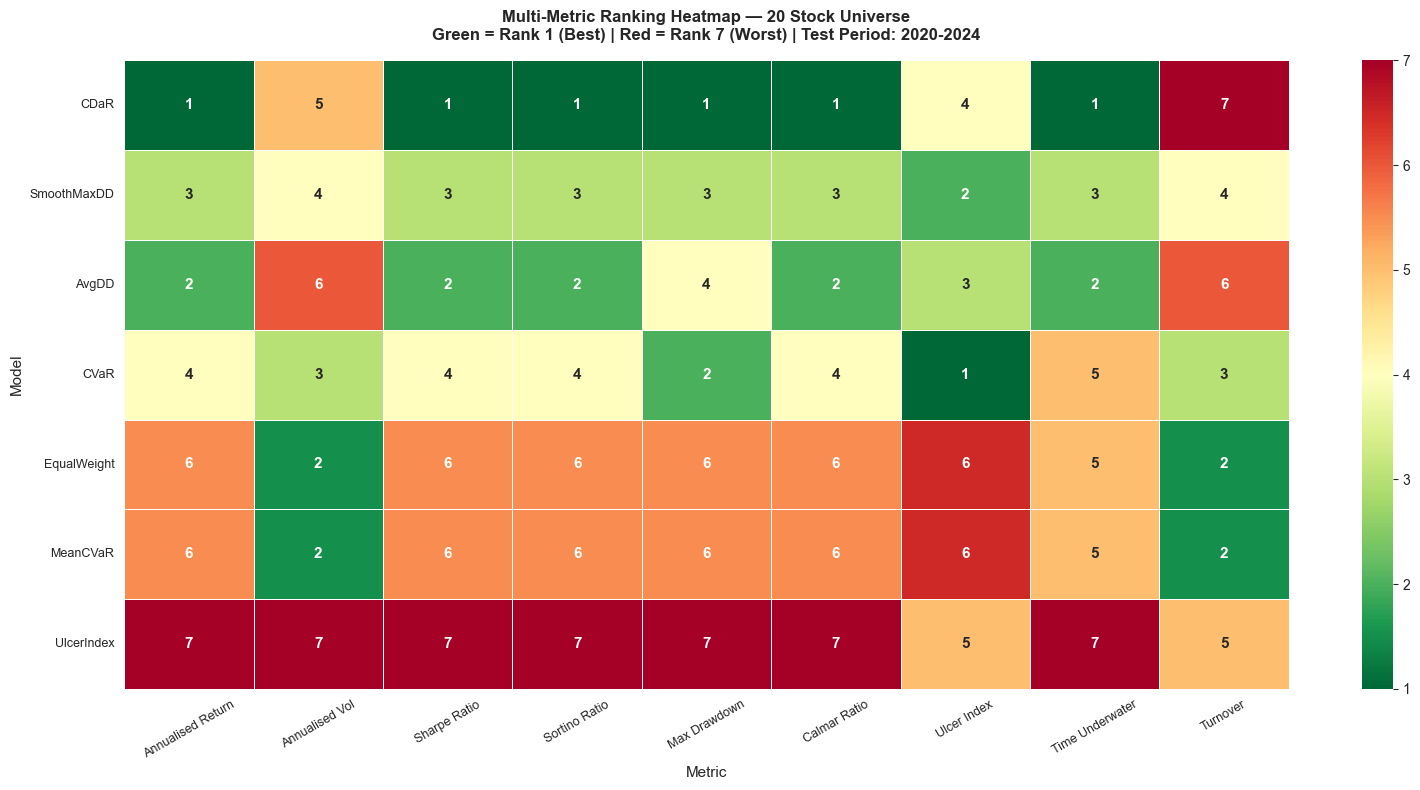

Ranking heatmap saved


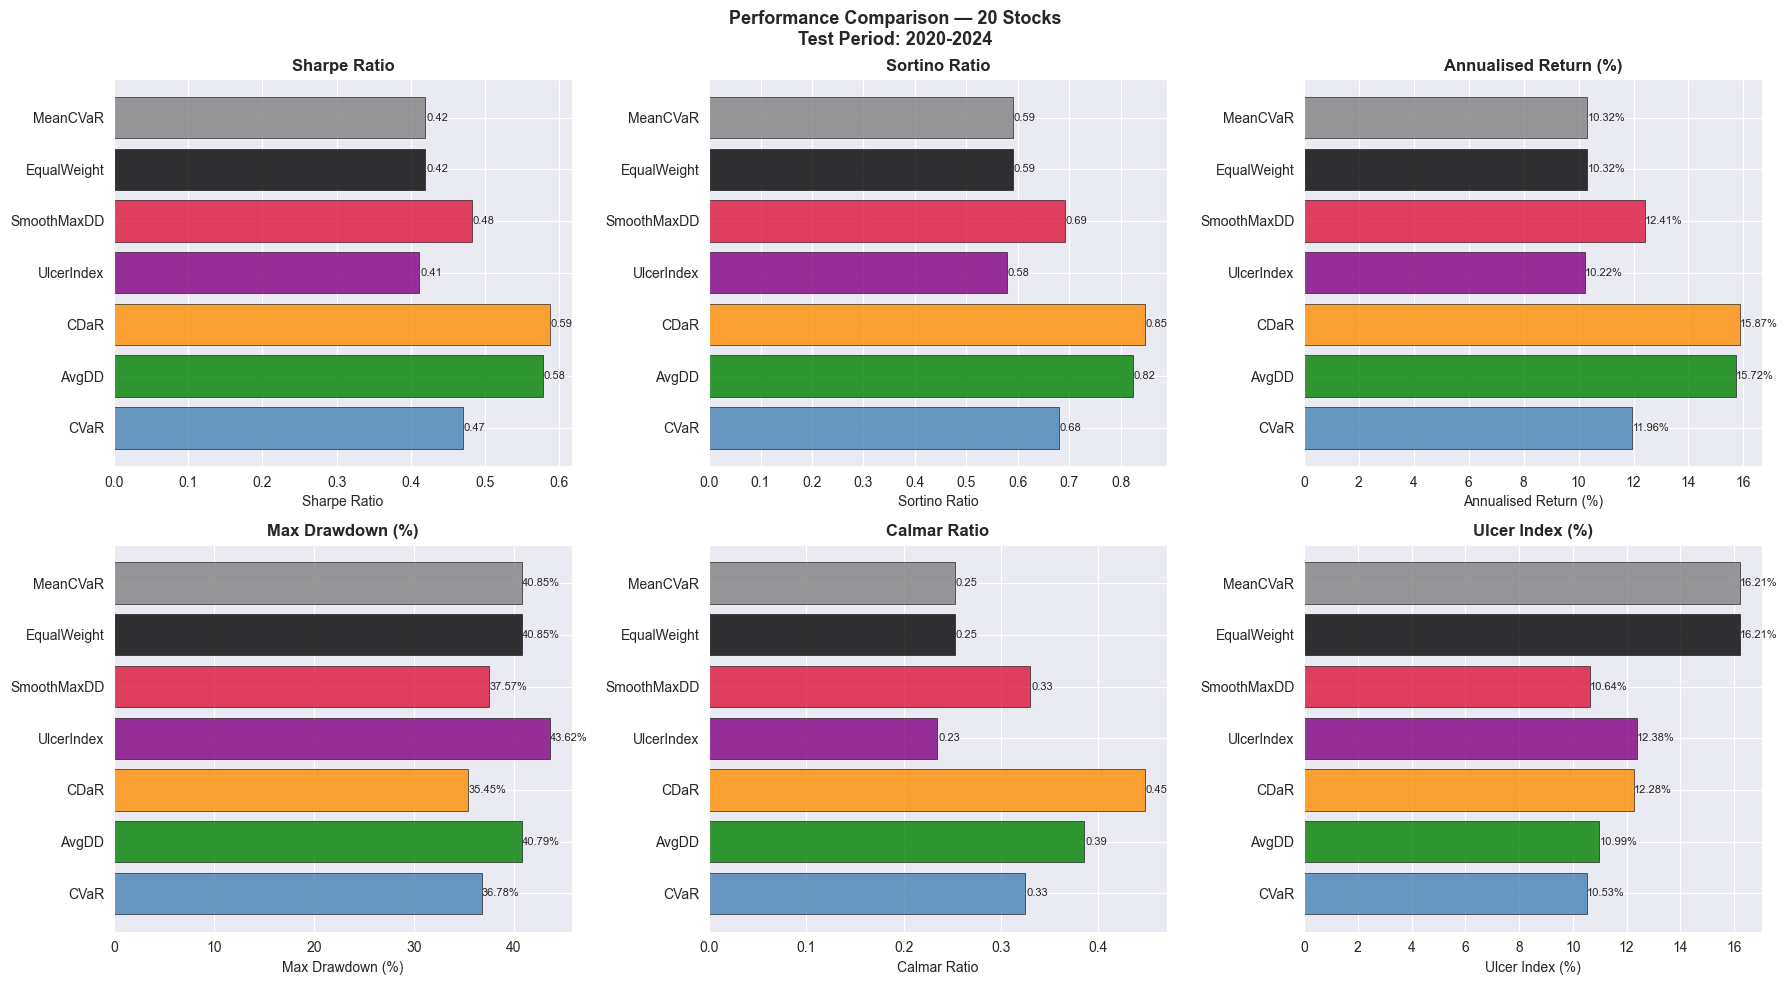

Performance comparison plot saved

Results saved to data_paper_20/horse_race_results.csv
Composite ranking saved to data_paper_20/composite_ranking.csv

Winners saved to data_paper_20\winners.json:
  WINNING_MODEL             : CDaR
  COMPOSITE_WINNER          : CDaR
  BEST_DRAWDOWN_MODEL       : CDaR
  DATA_POOL                 : 20
  DATA_FOLDER               : data_paper_20

  SUMMARY OF WINNERS BY CATEGORY
  Dataset: 20 stocks | Test: 2020-2024

  Individual metric winners:
    Annualised Return      : CDaR            (15.87%)
    Annualised Vol         : EqualWeight     (28.06%)
    Sharpe Ratio           : CDaR            (0.5875)
    Sortino Ratio          : CDaR            (0.8467)
    Max Drawdown           : CDaR            (35.45%)
    Calmar Ratio           : CDaR            (0.4478)
    Ulcer Index            : CVaR            (10.53%)
    Time Underwater        : CDaR            (91.83%)
    Turnover               : EqualWeight     (0.00%)

  Overall winners:
    Sharpe r

In [21]:
# ============================================================
# CELL 20: MULTI-METRIC COMPOSITE RANKING
# ============================================================
# A single metric like the Sharpe ratio is not sufficient
# to identify the best model because:
#   - It only measures return per unit of TOTAL volatility
#   - It penalises upside moves equally with downside moves
#   - It says nothing about drawdown depth or duration
#
# Our research question specifically asks which model provides
# the best DRAWDOWN CONTROL. We need a richer evaluation.
#
# COMPOSITE RANKING APPROACH:
#   Step 1: Rank each model on each individual metric
#           Rank 1 = best on that metric
#           Rank 7 = worst on that metric (6 models + MeanCVaR)
#   Step 2: Average all ranks to get a composite score
#           Lower composite score = better overall performance
#   Step 3: Also compute a drawdown-specific ranking using
#           only the five drawdown-focused metrics
#           This directly answers our research question
#
# RANKING DIRECTIONS:
#   Rank 1 assigned to HIGHEST value for:
#     Annualised Return, Sharpe, Sortino, Calmar
#   Rank 1 assigned to LOWEST value for:
#     Volatility, MaxDD, Ulcer Index, Time Underwater, Turnover
#
# WINNER SAVING:
#   At the end of this cell we save the winner names to a
#   JSON file called winners.json. All robustness cells
#   (Cells 23, 24, 25, 26, 27, 28) load from this file
#   automatically so no hardcoding is needed. Change
#   DATA_POOL in Cell 1 and rerun to get updated winners.
# ============================================================

import numpy as np           # numerical operations
import pandas as pd          # DataFrame for ranking table
import matplotlib.pyplot as plt   # plotting
import seaborn as sns        # heatmap
import os                    # file paths
import json                  # save winners

# ---- Safety reload ----
try:
    all_results
    DATA_FOLDER
    DATA_POOL
    LOSS_FUNCTIONS
except NameError:
    print("ERROR: all_results not defined. Run Cell 19 first.")
    raise

sns.set_style('darkgrid')   # consistent plot style

# ============================================================
# STEP 1: BUILD THE FULL RESULTS TABLE
# ============================================================

# Include all five SIT models plus both benchmarks
all_model_names = (
    list(LOSS_FUNCTIONS.keys()) +   # CVaR, AvgDD, CDaR, UlcerIndex, SmoothMaxDD
    ['EqualWeight', 'MeanCVaR']     # two benchmarks
)

# Define ranking direction for each metric
# +1 means higher value is better (rank 1 = highest)
# -1 means lower value is better (rank 1 = lowest)
metric_directions = {
    'Annualised Return' : +1,   # higher return is better
    'Annualised Vol'    : -1,   # lower risk is better
    'Sharpe Ratio'      : +1,   # higher Sharpe is better
    'Sortino Ratio'     : +1,   # higher Sortino is better
    'Max Drawdown'      : -1,   # lower drawdown is better
    'Calmar Ratio'      : +1,   # higher Calmar is better
    'Ulcer Index'       : -1,   # lower Ulcer is better
    'Time Underwater'   : -1,   # less time underwater is better
    'Turnover'          : -1,   # lower turnover is better
}

# Build raw results DataFrame
# One row per model, one column per metric
rows = []
for name in all_model_names:
    if name in all_results:
        row = {'Model': name}               # model name
        row.update(all_results[name]['metrics'])  # all metric values
        rows.append(row)

# Create DataFrame with Model as the row index
results_df = pd.DataFrame(rows).set_index('Model')

# Print the full raw results table
print(f"{'='*70}")
print(f"  RAW RESULTS TABLE")
print(f"  Asset pool: {DATA_POOL} stocks | Test: 2020-2024")
print(f"{'='*70}")
print(results_df.round(4).to_string())
print(f"{'='*70}")

# ============================================================
# STEP 2: COMPUTE RANKS FOR EACH METRIC
# ============================================================

# For each metric assign ranks from 1 to 7
# Rank 1 = best performance on that metric
# Rank 7 = worst performance on that metric
rank_df = pd.DataFrame(index=results_df.index)

for metric, direction in metric_directions.items():

    if metric not in results_df.columns:
        continue   # skip if metric not in results

    values = results_df[metric]   # all model values for this metric

    if direction == +1:
        # Higher is better: rank 1 goes to the highest value
        # ascending=False means the largest value gets rank 1
        rank_df[metric] = values.rank(ascending=False)
    else:
        # Lower is better: rank 1 goes to the lowest value
        # ascending=True means the smallest value gets rank 1
        rank_df[metric] = values.rank(ascending=True)

# Print the rank table
print(f"\nRANK TABLE (1 = best on that metric, 7 = worst):")
print(f"{'─'*70}")
print(rank_df.round(1).to_string())
print(f"{'─'*70}")

# ============================================================
# STEP 3: COMPUTE COMPOSITE SCORE
# ============================================================

# Average rank across ALL nine metrics
# Lower composite score = better overall performance
# A perfect model ranked 1st on every metric scores 1.0
# A terrible model ranked 7th on every metric scores 7.0
rank_df['Composite Score'] = rank_df.mean(axis=1)

# Sort by composite score ascending (lower is better)
rank_df = rank_df.sort_values('Composite Score')

# Print the composite ranking
print(f"\nCOMPOSITE RANKING (lower score = better overall):")
print(f"{'='*55}")
for rank, (model, row) in enumerate(rank_df.iterrows(), 1):
    marker = " <- WINNER" if rank == 1 else ""
    print(
        f"  {rank}. {model:<15} "
        f"Composite Score = {row['Composite Score']:.2f}"
        f"{marker}"
    )
print(f"{'='*55}")

# Store the composite winner
COMPOSITE_WINNER = rank_df.index[0]
print(f"\nComposite ranking winner: {COMPOSITE_WINNER}")

# ============================================================
# STEP 4: DRAWDOWN-SPECIFIC RANKING
# ============================================================

# Rank models using ONLY the five drawdown-focused metrics
# This directly answers our research question:
# "Which loss function provides the best drawdown control?"
drawdown_metrics = {
    'Max Drawdown'    : -1,   # lower max drawdown is better
    'Ulcer Index'     : -1,   # lower Ulcer Index is better
    'Time Underwater' : -1,   # less time underwater is better
    'Calmar Ratio'    : +1,   # higher Calmar ratio is better
    'Sortino Ratio'   : +1,   # higher Sortino ratio is better
}

# Build drawdown-specific rank DataFrame
dd_rank_df = pd.DataFrame(index=results_df.index)

for metric, direction in drawdown_metrics.items():
    if metric not in results_df.columns:
        continue
    values = results_df[metric]
    if direction == +1:
        dd_rank_df[metric] = values.rank(ascending=False)
    else:
        dd_rank_df[metric] = values.rank(ascending=True)

# Average drawdown ranks across five metrics
dd_rank_df['Drawdown Score'] = dd_rank_df.mean(axis=1)

# Sort ascending — lower drawdown score is better
dd_rank_df = dd_rank_df.sort_values('Drawdown Score')

# Print the drawdown ranking
print(f"\nDRAWDOWN-SPECIFIC RANKING:")
print(f"{'='*55}")
for rank, (model, row) in enumerate(dd_rank_df.iterrows(), 1):
    marker = " <- BEST DRAWDOWN PROTECTION" if rank == 1 else ""
    print(
        f"  {rank}. {model:<15} "
        f"Drawdown Score = {row['Drawdown Score']:.2f}"
        f"{marker}"
    )
print(f"{'='*55}")

BEST_DRAWDOWN_MODEL = dd_rank_df.index[0]
print(f"\nBest drawdown model: {BEST_DRAWDOWN_MODEL}")

# ============================================================
# STEP 5: PLOT RANKING HEATMAP
# ============================================================

fig1, ax1 = plt.subplots(figsize=(16, 8))

# Drop the composite score column for the heatmap
# We only want to show individual metric ranks
heatmap_data = rank_df.drop(columns=['Composite Score'])

# Plot heatmap with green = best (rank 1) and red = worst
sns.heatmap(
    heatmap_data,
    annot     = True,              # show rank numbers in each cell
    fmt       = '.0f',             # format as integers (no decimals)
    cmap      = 'RdYlGn_r',       # red = worst, green = best
    vmin      = 1,                 # rank 1 = darkest green
    vmax      = len(all_model_names),  # rank 7 = darkest red
    linewidths= 0.5,               # thin lines between cells
    ax        = ax1,
    annot_kws = {'size': 11, 'fontweight': 'bold'}
)

ax1.set_title(
    f'Multi-Metric Ranking Heatmap — {DATA_POOL} Stock Universe\n'
    f'Green = Rank 1 (Best) | Red = Rank 7 (Worst) | '
    f'Test Period: 2020-2024',
    fontsize=12, fontweight='bold', pad=15
)
ax1.set_xlabel('Metric', fontsize=11)
ax1.set_ylabel('Model',  fontsize=11)
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'ranking_heatmap.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Ranking heatmap saved")

# ============================================================
# STEP 6: PERFORMANCE BAR CHARTS
# ============================================================

fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle(
    f'Performance Comparison — {DATA_POOL} Stocks\n'
    f'Test Period: 2020-2024',
    fontsize=13, fontweight='bold')

# Colours for each model — consistent across all plots
model_colours = {
    'EqualWeight' : 'black',
    'MeanCVaR'    : 'grey',
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
}

# Define which metrics to plot and how to display them
# Each tuple: (metric_name, display_as_pct, axis_label)
plot_metrics = [
    ('Sharpe Ratio',      False, 'Sharpe Ratio'),
    ('Sortino Ratio',     False, 'Sortino Ratio'),
    ('Annualised Return', True,  'Annualised Return (%)'),
    ('Max Drawdown',      True,  'Max Drawdown (%)'),
    ('Calmar Ratio',      False, 'Calmar Ratio'),
    ('Ulcer Index',       True,  'Ulcer Index (%)'),
]

for ax, (metric, as_pct, label) in zip(
    axes2.flatten(), plot_metrics
):
    # Get the metric value for each model
    values = [
        results_df.loc[m, metric]
        if m in results_df.index else 0
        for m in all_model_names
    ]

    # Convert to percentage if needed
    plot_values = (
        [v * 100 for v in values] if as_pct else values
    )

    # Colour bars by model
    colours = [
        model_colours.get(m, 'grey')
        for m in all_model_names
    ]

    # Plot horizontal bar chart
    bars = ax.barh(
        all_model_names,   # model names on y-axis
        plot_values,        # metric values on x-axis
        color     = colours,
        alpha     = 0.8,
        edgecolor = 'black',
        linewidth = 0.5
    )

    # Add value labels at the end of each bar
    for bar, val in zip(bars, plot_values):
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}{"%" if as_pct else ""}',
            va='center', fontsize=8
        )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'performance_comparison.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Performance comparison plot saved")

# ============================================================
# STEP 7: SAVE RESULTS TO CSV
# ============================================================

# Save full raw results table
results_df.to_csv(
    os.path.join(DATA_FOLDER, 'horse_race_results.csv'))
print(f"\nResults saved to {DATA_FOLDER}/horse_race_results.csv")

# Save composite ranking table
rank_df.to_csv(
    os.path.join(DATA_FOLDER, 'composite_ranking.csv'))
print(f"Composite ranking saved to "
      f"{DATA_FOLDER}/composite_ranking.csv")

# ============================================================
# STEP 8: SAVE WINNER NAMES TO winners.json
# ============================================================
# This is the key step that makes all robustness cells
# fully automatic. Cells 23 through 28 load from this file
# rather than hardcoding model names. This means:
#   - Change DATA_POOL in Cell 1 to 20, 30, or 50
#   - Rerun the notebook end to end
#   - winners.json is updated with the new winners
#   - All robustness cells automatically use the new winners

winners = {
    'WINNING_MODEL'       : str(COMPOSITE_WINNER),
    'COMPOSITE_WINNER'    : str(COMPOSITE_WINNER),
    'BEST_DRAWDOWN_MODEL' : str(BEST_DRAWDOWN_MODEL),
    'DATA_POOL'           : DATA_POOL,
    'DATA_FOLDER'         : DATA_FOLDER,
}

winners_path = os.path.join(DATA_FOLDER, 'winners.json')
with open(winners_path, 'w') as f:
    json.dump(winners, f, indent=2)   # indent=2 for readability

print(f"\nWinners saved to {winners_path}:")
for k, v in winners.items():
    print(f"  {k:<25} : {v}")

# ============================================================
# STEP 9: PRINT FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print(f"  SUMMARY OF WINNERS BY CATEGORY")
print(f"  Dataset: {DATA_POOL} stocks | Test: 2020-2024")
print(f"{'='*60}")

# Print which model won each individual metric
print(f"\n  Individual metric winners:")
for metric, direction in metric_directions.items():
    if metric not in results_df.columns:
        continue
    if direction == +1:
        winner = results_df[metric].idxmax()   # highest value wins
        best   = results_df[metric].max()
    else:
        winner = results_df[metric].idxmin()   # lowest value wins
        best   = results_df[metric].min()

    # Format value as percentage or plain number
    if metric in [
        'Annualised Return', 'Annualised Vol',
        'Max Drawdown', 'Ulcer Index',
        'Time Underwater', 'Turnover'
    ]:
        val_str = f"{best * 100:.2f}%"
    else:
        val_str = f"{best:.4f}"

    print(f"    {metric:<22} : "
          f"{winner:<15} ({val_str})")

print(f"\n  Overall winners:")
print(f"    Sharpe ranking    : "
      f"{results_df['Sharpe Ratio'].idxmax()}")
print(f"    Composite ranking : {COMPOSITE_WINNER}")
print(f"    Drawdown ranking  : {BEST_DRAWDOWN_MODEL}")
print(f"{'='*60}")

# Update WINNING_MODEL to use the composite winner
# for all subsequent robustness testing cells
WINNING_MODEL = COMPOSITE_WINNER
print(f"\nWINNING_MODEL updated to: {WINNING_MODEL}")
print(f"This model will be used in robustness testing")

print(f"\nCell 20 complete")
print(f"Next: Cell 21 — Cumulative Wealth Plot")

WINNING_MODEL loaded: CDaR


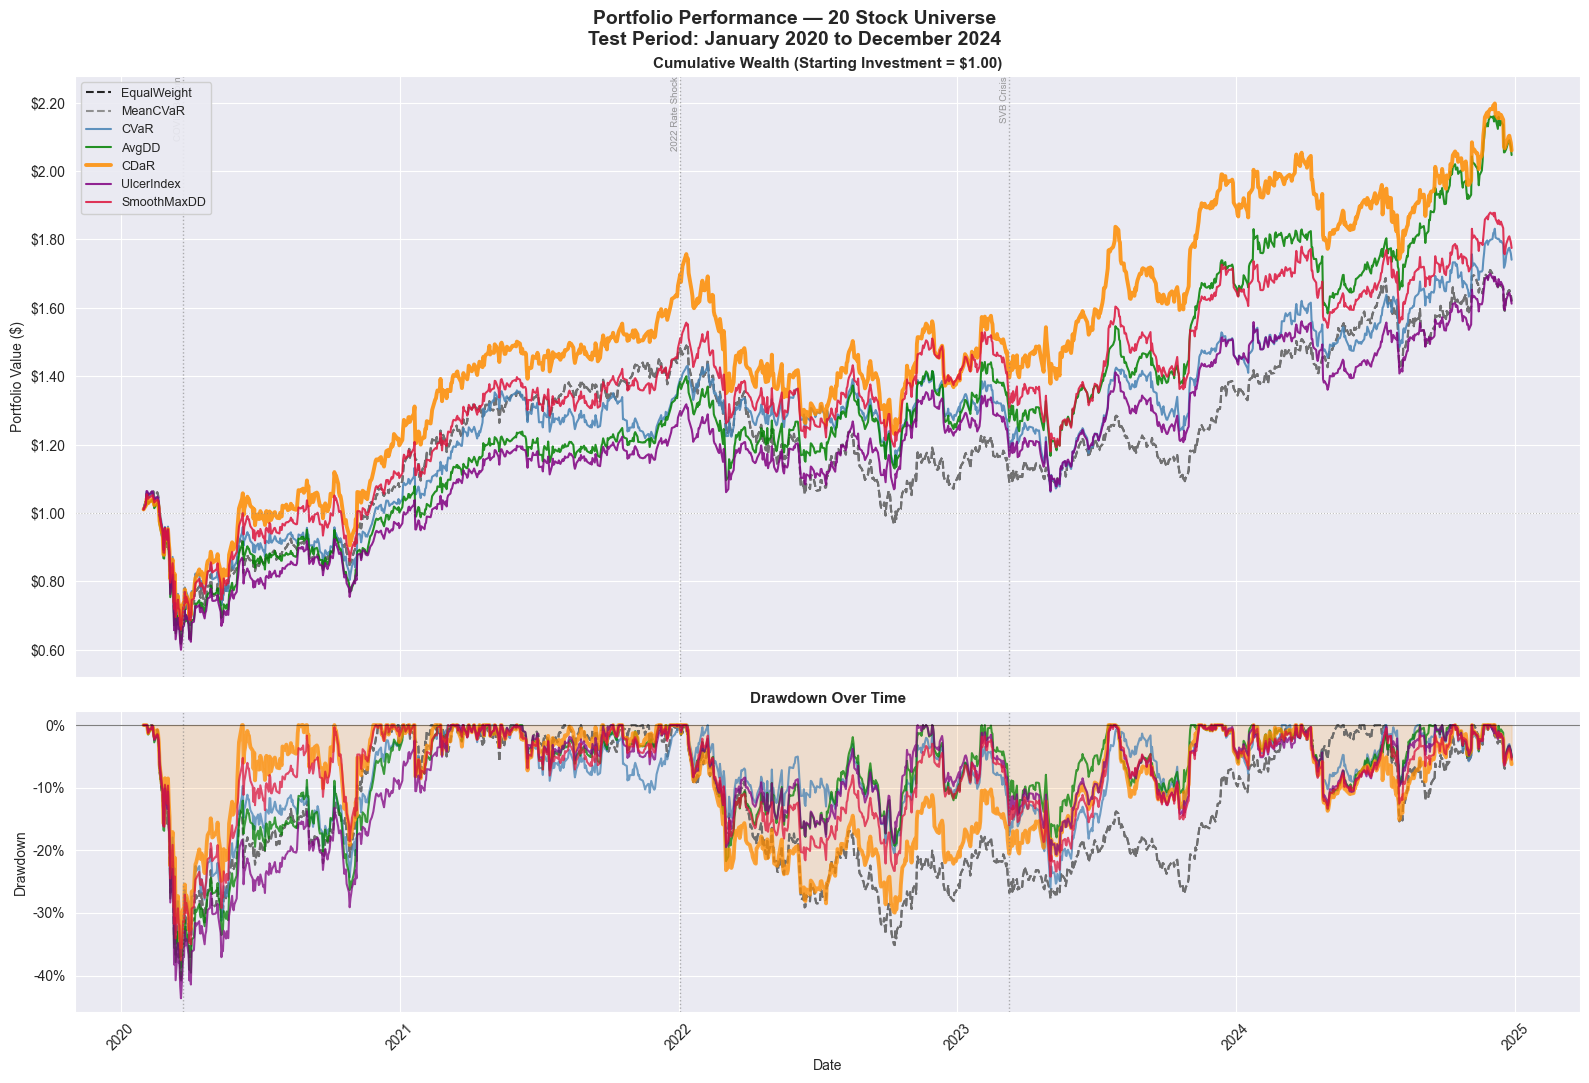

Cumulative wealth plot saved to data_paper_20/cumulative_wealth.png

FINAL WEALTH SUMMARY
(Value of $1 invested at start of test period)
─────────────────────────────────────────────
  1. CDaR            $2.0599 <- HIGHEST WEALTH
  2. AvgDD           $2.0465
  3. SmoothMaxDD     $1.7746
  4. CVaR            $1.7403
  5. EqualWeight     $1.6185
  6. MeanCVaR        $1.6185
  7. UlcerIndex      $1.6118
─────────────────────────────────────────────

Cell 21 complete
Next: Cell 22 — Training Curves


In [22]:
# ============================================================
# CELL 21: CUMULATIVE WEALTH AND DRAWDOWN PLOTS
# ============================================================
# These two plots are the most important visualisations
# for the final report and the most intuitive way to
# present portfolio performance to an examiner.
#
# PLOT 1: CUMULATIVE WEALTH
#   Shows how one dollar invested at the start of the
#   test period (January 2020) grew under each strategy.
#   A higher ending wealth means better total return.
#   The slope of the line shows return velocity.
#   Flat or downward sections show periods of loss.
#
# PLOT 2: DRAWDOWN OVER TIME
#   Shows how far below the previous peak each portfolio
#   was at every point during the test period.
#   A drawdown of -0.20 means the portfolio is 20% below
#   its highest previous value.
#   Deeper and wider troughs mean worse drawdown experience.
#   This panel directly visualises what our loss functions
#   are trying to minimise.
#
# Both plots share the same x-axis (time) and are stacked
# vertically so readers can see the relationship between
# wealth growth and drawdown periods simultaneously.
#
# Market event markers are added to provide context:
#   - COVID-19 crash bottom (March 2020)
#   - 2022 rate shock start (January 2022)
#   - SVB banking crisis (March 2023)
# ============================================================

import matplotlib.pyplot as plt       # plotting engine
import matplotlib.dates as mdates     # date formatting
import matplotlib.patches as mpatches # custom legend entries
import pandas as pd                   # date handling
import numpy as np                    # numerical operations
import os                             # file paths
import json                           # load winners

# ---- Safety reload ----
try:
    all_results
    test_dates_final
    DATA_FOLDER
    DATA_POOL
    LOSS_FUNCTIONS
    WINNING_MODEL
    COMPOSITE_WINNER
except NameError:
    print("ERROR: Required variables missing.")
    print("Please run Cells 18, 19 and 20 first.")
    raise

# ---- Load winners.json to get model names ----
# This ensures we always use the correct winner
# regardless of what happened in earlier cells
winners_path = os.path.join(DATA_FOLDER, 'winners.json')
if os.path.exists(winners_path):
    with open(winners_path) as f:
        winners_loaded = json.load(f)
    WINNING_MODEL = winners_loaded['WINNING_MODEL']
    print(f"WINNING_MODEL loaded: {WINNING_MODEL}")

# ---- Define consistent colours for all models ----
# These same colours are used in every plot across all cells
# for visual consistency throughout the report
MODEL_COLOURS = {
    'EqualWeight' : 'black',      # black for naive benchmark
    'MeanCVaR'    : 'grey',       # grey for classical benchmark
    'CVaR'        : 'steelblue',  # blue for original paper model
    'AvgDD'       : 'green',      # green for average drawdown
    'CDaR'        : 'darkorange', # orange for CDaR
    'UlcerIndex'  : 'purple',     # purple for Ulcer Index
    'SmoothMaxDD' : 'crimson',    # red for SmoothMaxDD
}

# ---- Define line widths ----
# The composite winner gets a thicker line to stand out
# from the other models in the crowded plot
MODEL_WIDTHS = {}
for name in MODEL_COLOURS:
    if name == WINNING_MODEL:
        MODEL_WIDTHS[name] = 2.8   # thicker line for winner
    else:
        MODEL_WIDTHS[name] = 1.5   # standard line for others

# ---- Define line styles ----
# Benchmarks use dashed lines to distinguish them from
# the five SIT model lines which are solid
MODEL_STYLES = {
    'EqualWeight' : '--',   # dashed: naive benchmark
    'MeanCVaR'    : '--',   # dashed: classical benchmark
    'CVaR'        : '-',    # solid: SIT model
    'AvgDD'       : '-',    # solid: SIT model
    'CDaR'        : '-',    # solid: SIT model
    'UlcerIndex'  : '-',    # solid: SIT model
    'SmoothMaxDD' : '-',    # solid: SIT model
}

# ---- Convert test dates to datetime ----
# pd.to_datetime ensures the dates are in the correct format
# for matplotlib to use on the x-axis
plot_dates = pd.to_datetime(test_dates_final.values)

# ============================================================
# CREATE THE TWO-PANEL FIGURE
# ============================================================

# Create a figure with two subplots stacked vertically
# sharex=True means both panels share the same x-axis (time)
# height_ratios=[2,1] makes the top panel twice as tall
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize        = (16, 11),       # wide and tall figure
    sharex         = True,           # shared x-axis
    gridspec_kw    = {'height_ratios': [2, 1]}  # top panel 2x taller
)

fig.suptitle(
    f'Portfolio Performance — {DATA_POOL} Stock Universe\n'
    f'Test Period: January 2020 to December 2024',
    fontsize=14, fontweight='bold'
)

# ============================================================
# TOP PANEL: CUMULATIVE WEALTH
# ============================================================

for name, data in all_results.items():
    # Get the daily portfolio return series for this model
    port_ret = data['portfolio_returns']

    # Compute cumulative wealth starting at 1.00 dollar
    # np.cumprod multiplies each element by all previous
    # (1+r1) * (1+r2) * ... gives total wealth over time
    cum_wealth = np.cumprod(1 + port_ret)

    # Trim the dates array to match the return series length
    # Small alignment differences may cause slight mismatches
    dates_plot = plot_dates[:len(cum_wealth)]

    ax1.plot(
        dates_plot,    # x-axis: dates
        cum_wealth,    # y-axis: cumulative wealth
        label     = name,
        color     = MODEL_COLOURS.get(name, 'grey'),
        linestyle = MODEL_STYLES.get(name, '-'),
        linewidth = MODEL_WIDTHS.get(name, 1.5),
        alpha     = 0.85
    )

# Add vertical lines for key market events
# These provide context for interpreting performance
market_events = [
    ('2020-03-23', 'COVID Bottom'),
    ('2022-01-03', '2022 Rate Shock'),
    ('2023-03-10', 'SVB Crisis'),
]
for event_date, event_label in market_events:
    ax1.axvline(
        pd.Timestamp(event_date),
        color     = 'grey',
        linestyle = ':',
        linewidth = 1.0,
        alpha     = 0.6
    )
    ax1.text(
        pd.Timestamp(event_date),
        ax1.get_ylim()[1] if ax1.get_ylim()[1] > 1 else 1.5,
        event_label,
        fontsize  = 7,
        color     = 'grey',
        rotation  = 90,
        va        = 'top',
        ha        = 'right',
        alpha     = 0.8
    )

# Add horizontal reference line at starting value of 1.00
# A line above this means the strategy made money overall
ax1.axhline(
    y=1.0, color='grey', linestyle=':',
    linewidth=0.8, alpha=0.5)

ax1.set_title(
    'Cumulative Wealth (Starting Investment = $1.00)',
    fontsize=11, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Format y-axis to show dollar values
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:.2f}'))

# ============================================================
# BOTTOM PANEL: DRAWDOWN OVER TIME
# ============================================================

for name, data in all_results.items():
    port_ret = data['portfolio_returns']

    # Recompute cumulative wealth for drawdown calculation
    cum_wealth   = np.cumprod(1 + port_ret)
    # Running maximum: highest wealth value seen so far
    running_peak = np.maximum.accumulate(cum_wealth)
    # Drawdown expressed as a NEGATIVE number
    # Negative so the line goes below zero on the plot
    # making it intuitive: below zero means you are losing
    drawdown = -(running_peak - cum_wealth) / running_peak

    dates_plot = plot_dates[:len(drawdown)]

    ax2.plot(
        dates_plot,
        drawdown,
        label     = name,
        color     = MODEL_COLOURS.get(name, 'grey'),
        linestyle = MODEL_STYLES.get(name, '-'),
        linewidth = MODEL_WIDTHS.get(name, 1.5),
        alpha     = 0.75
    )

# Fill the area under the winning model's drawdown curve
# This highlights the winning model's drawdown visually
if WINNING_MODEL in all_results:
    wr_ret = all_results[WINNING_MODEL]['portfolio_returns']
    wr_cw  = np.cumprod(1 + wr_ret)
    wr_peak = np.maximum.accumulate(wr_cw)
    wr_dd   = -(wr_peak - wr_cw) / wr_peak
    dates_plot = plot_dates[:len(wr_dd)]

    # fill_between shades the area between drawdown curve and zero
    ax2.fill_between(
        dates_plot,
        wr_dd,   # lower boundary: drawdown line
        0,       # upper boundary: zero line
        alpha = 0.15,   # semi-transparent fill
        color = MODEL_COLOURS.get(WINNING_MODEL, 'steelblue'),
        label = '_nolegend_'   # underscore hides from legend
    )

# Add market event lines to drawdown panel
for event_date, _ in market_events:
    ax2.axvline(
        pd.Timestamp(event_date),
        color='grey', linestyle=':', linewidth=1.0, alpha=0.6)

# Zero reference line: above zero means at a peak
ax2.axhline(
    y=0, color='black', linewidth=0.8, alpha=0.5)

ax2.set_title(
    'Drawdown Over Time', fontsize=11, fontweight='bold')
ax2.set_ylabel('Drawdown', fontsize=10)
ax2.set_xlabel('Date',     fontsize=10)

# Format y-axis as percentages (drawdown is shown as negative %)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))

# Format x-axis to show one label per year
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

# ============================================================
# SAVE AND DISPLAY THE FIGURE
# ============================================================

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'cumulative_wealth.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print(f"Cumulative wealth plot saved to "
      f"{DATA_FOLDER}/cumulative_wealth.png")

# ============================================================
# PRINT FINAL WEALTH SUMMARY TABLE
# ============================================================

print(f"\nFINAL WEALTH SUMMARY")
print(f"(Value of $1 invested at start of test period)")
print(f"{'─'*45}")

# Compute final wealth for every model
final_wealth = {}
for name, data in all_results.items():
    pr = data['portfolio_returns']
    cw = np.cumprod(1 + pr)
    final_wealth[name] = cw[-1]   # last value = final wealth

# Sort by final wealth from highest to lowest
sorted_wealth = sorted(
    final_wealth.items(),
    key     = lambda x: x[1],
    reverse = True              # highest first
)

for rank, (name, wealth) in enumerate(sorted_wealth, 1):
    marker = " <- HIGHEST WEALTH" if rank == 1 else ""
    print(f"  {rank}. {name:<15} ${wealth:.4f}{marker}")

print(f"{'─'*45}")
print(f"\nCell 21 complete")
print(f"Next: Cell 22 — Training Curves")

Models with training history:
  CVaR            :  21 epochs trained | best val loss = 0.022248 at epoch 6
  AvgDD           :  34 epochs trained | best val loss = 0.021234 at epoch 19
  CDaR            :  38 epochs trained | best val loss = 0.063915 at epoch 23
  UlcerIndex      :  23 epochs trained | best val loss = 0.029394 at epoch 8
  SmoothMaxDD     :  24 epochs trained | best val loss = 0.117880 at epoch 9


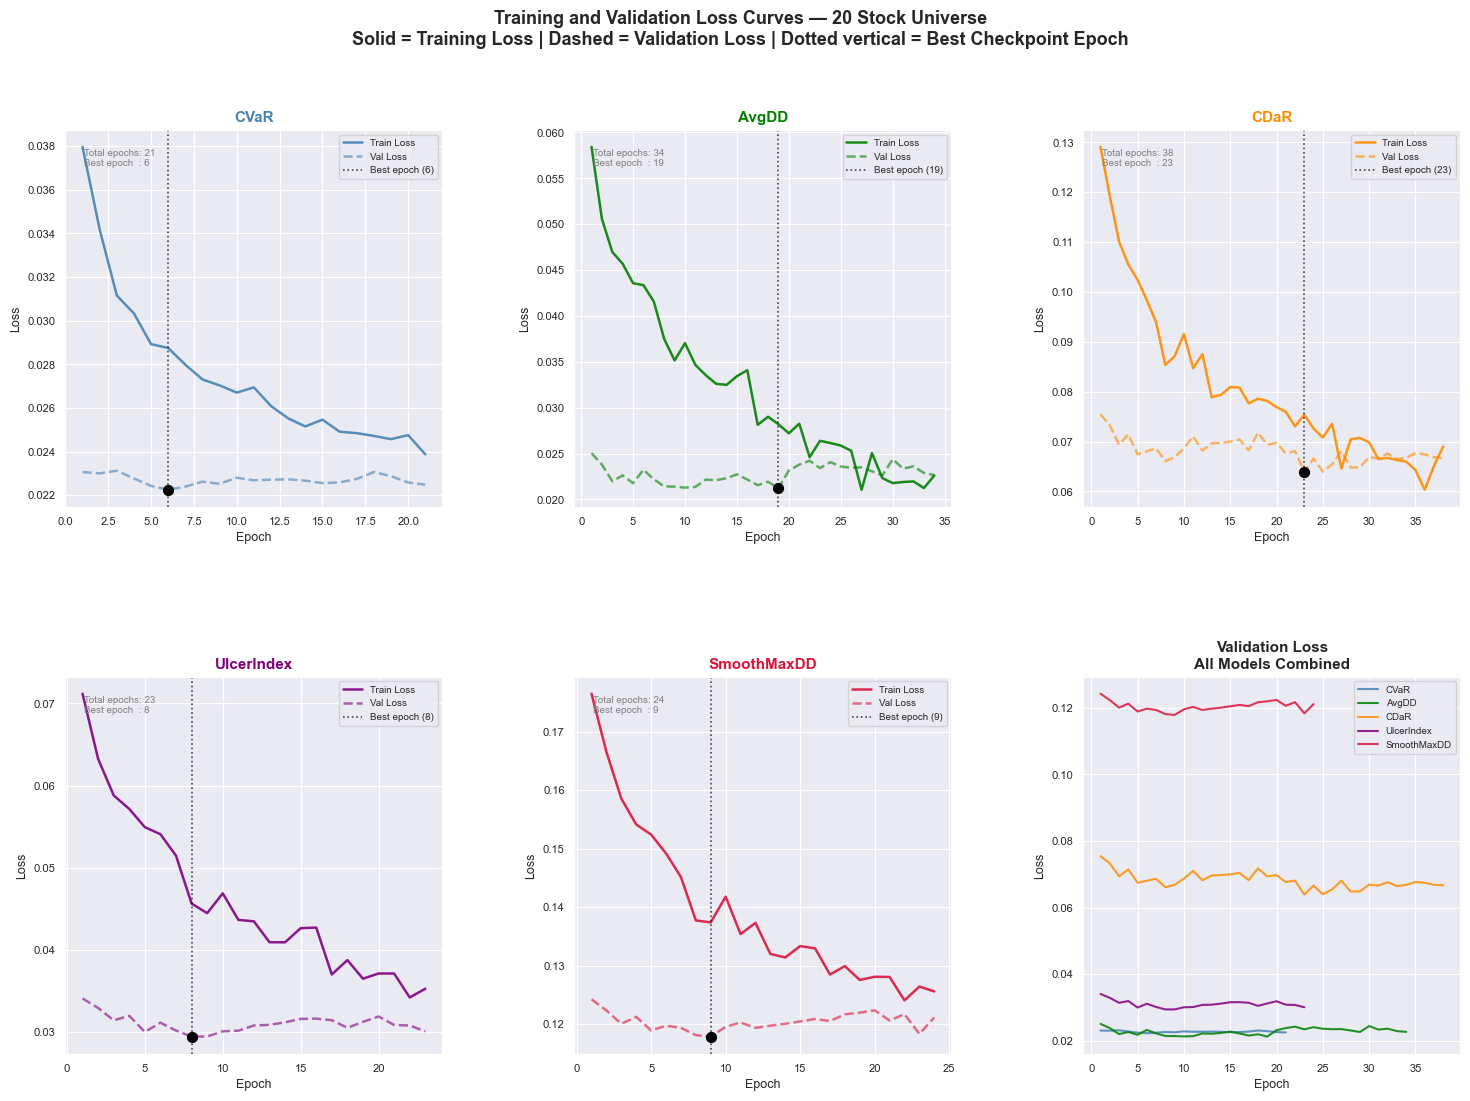

Training curves saved to data_paper_20/training_curves.png

TRAINING SUMMARY TABLE:
─────────────────────────────────────────────────────────────────
  Model             Epochs   Best Epoch   Best Val Loss   Final Train Loss
─────────────────────────────────────────────────────────────────
  CVaR                  21            6        0.022248           0.023870
  AvgDD                 34           19        0.021234           0.022595
  CDaR                  38           23        0.063915           0.069040
  UlcerIndex            23            8        0.029394           0.035226
  SmoothMaxDD           24            9        0.117880           0.125592
─────────────────────────────────────────────────────────────────

OVERFITTING CHECK:
  (val/train ratio close to 1.0 = no overfitting)
  (ratio much greater than 1.0 = overfitting)
─────────────────────────────────────────────
  CVaR            : val/train ratio = 0.93 — OK
  AvgDD           : val/train ratio = 0.94 — OK
  CDaR    

In [23]:
# ============================================================
# CELL 22: TRAINING CURVES PLOT
# ============================================================
# Training curves show how each model's loss changed across
# epochs during training. This serves three important purposes
# in the final report:
#
# PURPOSE 1: CONFIRM TRAINING WAS STABLE
#   A well-trained model shows both training and validation
#   loss declining together over epochs. If the training
#   loss explodes to very large values or becomes NaN it
#   means gradient instability occurred.
#
# PURPOSE 2: SHOW WHEN EARLY STOPPING TRIGGERED
#   Training stopped when validation loss stopped improving
#   for PATIENCE=15 consecutive epochs. The number of epochs
#   actually trained tells us how quickly each model converged.
#   A model that stopped at epoch 25 converged faster than
#   one that ran to epoch 80.
#
# PURPOSE 3: DETECT OVERFITTING
#   Overfitting signature: training loss keeps decreasing
#   while validation loss stops improving or starts rising.
#   This means the model is memorising training data rather
#   than learning patterns that generalise.
#   The gap between training and validation loss at the
#   final epoch indicates the degree of overfitting.
#
# NOTE ON LOSS SCALE COMPARISON:
#   The five loss functions measure fundamentally different
#   things (CVaR measures single-period tail losses while
#   UlcerIndex measures RMS drawdowns) so their absolute
#   loss values are NOT comparable across models.
#   Only compare training vs validation loss WITHIN each model.
# ============================================================

import matplotlib.pyplot as plt      # plotting engine
import matplotlib.gridspec as gridspec  # custom grid layout
import numpy as np                   # numerical operations
import os                            # file paths

# ---- Safety reload ----
try:
    horse_race_history   # training curves from Cell 19
    DATA_FOLDER
    DATA_POOL
except NameError:
    print("ERROR: horse_race_history not defined.")
    print("Please run Cell 19 first.")
    raise

# ---- Confirm history is available for all models ----
print(f"Models with training history:")
for name, history in horse_race_history.items():
    n_epochs   = len(history['train_loss'])    # total epochs trained
    best_epoch = np.argmin(history['val_loss']) + 1  # epoch with best val loss
    best_val   = min(history['val_loss'])      # lowest val loss value
    print(f"  {name:<15} : "
          f"{n_epochs:>3} epochs trained | "
          f"best val loss = {best_val:.6f} at epoch {best_epoch}")

# ---- Define consistent colours ----
# Same colour per model as used in all other cells
MODEL_COLOURS = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
}

# ============================================================
# FIGURE 1: INDIVIDUAL TRAINING CURVES (5 SUBPLOTS + OVERVIEW)
# ============================================================

# Create a 2x3 grid layout
# First five positions: one subplot per model
# Sixth position: combined validation curves overview
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(
    2, 3,
    figure = fig,
    hspace = 0.45,   # vertical space between rows
    wspace = 0.35    # horizontal space between columns
)

fig.suptitle(
    f'Training and Validation Loss Curves — {DATA_POOL} Stock Universe\n'
    f'Solid = Training Loss | Dashed = Validation Loss | '
    f'Dotted vertical = Best Checkpoint Epoch',
    fontsize=13, fontweight='bold'
)

# ---- Plot individual training curve for each model ----
for idx, (model_name, history) in enumerate(
    horse_race_history.items()
):
    # Place each subplot in the correct grid cell
    # idx=0 -> row 0 col 0, idx=1 -> row 0 col 1, etc.
    row = idx // 3   # integer division gives the row (0 or 1)
    col = idx  % 3   # modulo gives the column (0, 1, or 2)
    ax  = fig.add_subplot(gs[row, col])

    colour = MODEL_COLOURS.get(model_name, 'grey')

    # Number of epochs this model actually trained for
    # May be less than N_EPOCHS if early stopping triggered
    n_epochs_trained = len(history['train_loss'])

    # Create x-axis values: epoch numbers starting at 1
    epoch_range = range(1, n_epochs_trained + 1)

    # ---- Plot training loss (solid line) ----
    # This shows how well the model fits the training data
    # over time. Should generally decrease each epoch.
    ax.plot(
        epoch_range,
        history['train_loss'],
        label     = 'Train Loss',
        color     = colour,
        linewidth = 1.8,
        alpha     = 0.9,
        linestyle = '-'      # solid line for training
    )

    # ---- Plot validation loss (dashed line) ----
    # This shows how well the model generalises to unseen data.
    # When this stops improving early stopping triggers.
    ax.plot(
        epoch_range,
        history['val_loss'],
        label     = 'Val Loss',
        color     = colour,
        linewidth = 1.8,
        alpha     = 0.6,
        linestyle = '--'     # dashed line for validation
    )

    # ---- Mark the best checkpoint epoch ----
    # np.argmin returns the INDEX of the minimum value
    # Adding 1 converts from 0-indexed to 1-indexed epoch number
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val   = min(history['val_loss'])

    # Add a vertical dotted line at the best epoch
    ax.axvline(
        x         = best_epoch,
        color     = 'black',
        linestyle = ':',      # dotted line for checkpoint
        linewidth = 1.2,
        alpha     = 0.7,
        label     = f'Best epoch ({best_epoch})'
    )

    # Add a dot exactly at the best validation point
    # This makes the checkpoint location very clear
    ax.scatter(
        best_epoch,   # x position: epoch number
        best_val,     # y position: best val loss value
        color  = 'black',
        zorder = 5,   # draw on top of other elements
        s      = 50   # marker size
    )

    # ---- Formatting ----
    ax.set_title(
        model_name,
        fontweight = 'bold',
        fontsize   = 11,
        color      = colour
    )
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Loss',  fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=8)

    # Add text showing total epochs and best epoch number
    # This provides the information at a glance
    ax.text(
        0.05, 0.95,              # position in axes coordinates
        f'Total epochs: {n_epochs_trained}\n'
        f'Best epoch  : {best_epoch}',
        transform  = ax.transAxes,  # relative to axes
        fontsize   = 7,
        color      = 'grey',
        va         = 'top'          # align to top
    )

# ============================================================
# SIXTH SUBPLOT: COMBINED VALIDATION LOSS OVERVIEW
# ============================================================

# Show all five validation loss curves on one axes
# This allows direct visual comparison of convergence speed
# and final validation loss across all five models
ax6 = fig.add_subplot(gs[1, 2])   # bottom right cell

for model_name, history in horse_race_history.items():
    colour   = MODEL_COLOURS.get(model_name, 'grey')
    n_epochs = len(history['val_loss'])

    ax6.plot(
        range(1, n_epochs + 1),     # epoch numbers on x-axis
        history['val_loss'],         # validation loss on y-axis
        label     = model_name,
        color     = colour,
        linewidth = 1.5,
        alpha     = 0.85
    )

ax6.set_title(
    'Validation Loss\nAll Models Combined',
    fontweight='bold', fontsize=11)
ax6.set_xlabel('Epoch', fontsize=9)
ax6.set_ylabel('Loss',  fontsize=9)
ax6.legend(fontsize=7, loc='upper right')
ax6.tick_params(labelsize=8)

# ---- Save Figure 1 ----
plt.savefig(
    os.path.join(DATA_FOLDER, 'training_curves.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print(f"Training curves saved to {DATA_FOLDER}/training_curves.png")

# ============================================================
# TRAINING SUMMARY TABLE
# ============================================================

print(f"\nTRAINING SUMMARY TABLE:")
print(f"{'─'*65}")
print(
    f"  {'Model':<15} "
    f"{'Epochs':>8} "
    f"{'Best Epoch':>12} "
    f"{'Best Val Loss':>15} "
    f"{'Final Train Loss':>18}"
)
print(f"{'─'*65}")

for model_name, history in horse_race_history.items():
    n_epochs    = len(history['train_loss'])    # total epochs trained
    best_epoch  = np.argmin(history['val_loss']) + 1  # best val epoch
    best_val    = min(history['val_loss'])      # best val loss value
    final_train = history['train_loss'][-1]    # loss at final epoch

    print(
        f"  {model_name:<15} "
        f"{n_epochs:>8} "
        f"{best_epoch:>12} "
        f"{best_val:>15.6f} "
        f"{final_train:>18.6f}"
    )

print(f"{'─'*65}")

# ============================================================
# OVERFITTING CHECK
# ============================================================

print(f"\nOVERFITTING CHECK:")
print(f"  (val/train ratio close to 1.0 = no overfitting)")
print(f"  (ratio much greater than 1.0 = overfitting)")
print(f"{'─'*45}")

for model_name, history in horse_race_history.items():
    final_train = history['train_loss'][-1]   # final training loss
    best_val    = min(history['val_loss'])     # best validation loss

    # Compute ratio of validation to training loss
    # If this is close to 1.0 the model generalises well
    # If this is much greater than 1.0 the model overfit
    if final_train > 0:
        ratio = best_val / final_train
    else:
        ratio = np.nan

    # Classify the overfitting level
    if ratio < 2.0:
        status = 'OK'
    elif ratio < 3.0:
        status = 'MILD'
    else:
        status = 'HIGH'

    print(
        f"  {model_name:<15} : "
        f"val/train ratio = {ratio:.2f} "
        f"— {status}"
    )

print(f"{'─'*45}")
print(f"\nCell 22 complete")
print(f"Next: Cell 23 — Walk-Forward Validation")
print(f"\nSECTION 3 COMPLETE: MODEL TRAINING AND EVALUATION")
print(f"Next section: SECTION 4 — ROBUSTNESS TESTING")

In [24]:
# ============================================================
# CELL 23: LENS 1 — WALK-FORWARD VALIDATION
# ============================================================
# SECTION 4: ROBUSTNESS TESTING
#
# Walk-forward validation tests TEMPORAL CONSISTENCY.
# It asks: "Does the winning model consistently outperform
# the baseline across different historical time periods,
# or did it just get lucky in the 2020-2024 test window?"
#
# METHOD — EXPANDING WINDOW:
#   Training always starts from January 2000.
#   The training end date expands by one year per window.
#   Each window tests on the following calendar year.
#
#   Window 1: Train 2000-2007 -> Test 2008 (GFC year)
#   Window 2: Train 2000-2008 -> Test 2009 (GFC recovery)
#   Window 3: Train 2000-2009 -> Test 2010
#   Window 4: Train 2000-2010 -> Test 2011 (Euro debt crisis)
#   Window 5: Train 2000-2011 -> Test 2012
#   Window 6: Train 2000-2012 -> Test 2013
#   Window 7: Train 2000-2013 -> Test 2014
#   Window 8: Train 2000-2014 -> Test 2015
#   Window 9: Train 2000-2015 -> Test 2016
#
# WHAT WE COMPARE:
#   WINNING_MODEL  vs  CVaR (original paper baseline)
#   and Equal Weight
#
# MODEL NAMES ARE LOADED DYNAMICALLY from winners.json
# saved by Cell 20. This means no hardcoding is needed.
# Change DATA_POOL in Cell 1 and rerun to get new winners.
#
# HYPERPARAMETER POLICY:
#   Hyperparameters are NOT re-tuned per window.
#   The same configuration validated in 2017-2019 is reused.
#   This prevents look-ahead bias from re-tuning and follows
#   the examiner's recommendation.
#
# ESTIMATED TIME:
#   Each window trains two models (winner and baseline).
#   Each model trains for up to 80 epochs with patience=10.
#   Total: approximately 30-60 minutes on CPU.
# ============================================================

import numpy as np                    # numerical operations
import pandas as pd                   # date slicing
import torch                          # deep learning
import torch.optim as optim           # Adam optimiser
import iisignature                    # path signatures
import os                             # file paths
import json                           # load winners
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

# ============================================================
# SAFETY CHECKS — reload everything if kernel was restarted
# ============================================================

try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE set to: {DEVICE}")

try:
    DATA_FOLDER
    SIG_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    os.makedirs(ROBUST_FOLDER, exist_ok=True)
    print("Folder paths set")

try:
    LOOKBACK
    SIG_ORDER
except NameError:
    with open(os.path.join(SIG_FOLDER, 'sig_config.json')) as f:
        sc = json.load(f)
    LOOKBACK  = sc['LOOKBACK']    # 20 trading days per window
    SIG_ORDER = sc['SIG_ORDER']   # signature truncation order
    print(f"LOOKBACK={LOOKBACK} SIG_ORDER={SIG_ORDER}")

try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
    BATCH_SIZE
    GLOBAL_SEED
except NameError:
    D_MODEL     = 64     # Transformer internal dimension
    N_HEADS     = 4      # attention heads
    N_LAYERS    = 2      # encoder layers
    DROPOUT     = 0.1    # dropout rate
    BATCH_SIZE  = 64     # training batch size
    GLOBAL_SEED = 42     # random seed
    print("Hyperparameters set to defaults")

try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock all random seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ['PYTHONHASHSEED'] = str(seed)
    print("set_all_seeds redefined")

try:
    SIT
except NameError:
    print("ERROR: SIT class not defined. Run Cell 12 first.")
    raise

try:
    compute_metrics
    compute_turnover
except NameError:
    print("ERROR: Metric functions not defined. Run Cell 15 first.")
    raise

# ---- Load clean prices and recompute log returns ----
# We load from clean_prices.csv to ensure all stocks
# are available — log_returns.csv may have stale data
print("Loading clean prices and recomputing log returns...")
clean_prices = pd.read_csv(
    os.path.join(DATA_FOLDER, 'clean_prices.csv'),
    index_col  = 0,    # first column is the date index
    parse_dates= True  # convert strings to datetime objects
)
print(f"Clean prices shape: {clean_prices.shape}")

# Compute log returns from clean prices
log_returns = np.log(
    clean_prices / clean_prices.shift(1)   # P_t / P_{t-1}
).dropna()                                  # drop first NaN row

# Winsorise to remove data errors
lower       = log_returns.quantile(0.001)
upper       = log_returns.quantile(0.999)
log_returns = log_returns.clip(
    lower=lower, upper=upper, axis=1)

print(f"Log returns shape: {log_returns.shape}")
ACTUAL_N_ASSETS = log_returns.shape[1]    # actual number of stocks
print(f"Actual N_ASSETS : {ACTUAL_N_ASSETS}")

# ---- Check Sortino Ratio is in compute_metrics ----
# Quick test before expensive training begins
_test = compute_metrics(np.random.randn(100) * 0.01)
if 'Sortino Ratio' not in _test:
    print("ERROR: Sortino Ratio missing. Rerun Cell 15 first.")
    raise KeyError("Sortino Ratio not found in compute_metrics")
else:
    print("Sortino Ratio confirmed in compute_metrics")

try:
    DATA_POOL
except NameError:
    DATA_POOL = 50

# ============================================================
# LOAD WINNING MODEL NAMES DYNAMICALLY FROM winners.json
# ============================================================

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    # Load winner names saved by Cell 20
    with open(winners_path) as f:
        winners = json.load(f)
    WF_WINNING  = winners['WINNING_MODEL']       # composite winner
    WF_BASELINE = winners['BEST_DRAWDOWN_MODEL'] # drawdown winner

    # Handle edge case where both names are the same model
    if WF_WINNING == WF_BASELINE:
        print(f"WARNING: Winner equals baseline. Adjusting...")
        WF_BASELINE = (
            'CVaR' if WF_WINNING != 'CVaR' else 'SmoothMaxDD')

    print(f"Winners loaded from {winners_path}")
else:
    print(f"WARNING: {winners_path} not found.")
    print(f"Using default model names as fallback.")
    WF_WINNING  = 'CVaR'
    WF_BASELINE = 'SmoothMaxDD'

print(f"\nWINNING_MODEL  : {WF_WINNING}")
print(f"BASELINE_MODEL : {WF_BASELINE}")
print(f"These are loaded dynamically from Cell 20 results")

# ============================================================
# DEFINE WALK-FORWARD WINDOWS
# ============================================================

# Each tuple: (train_start, train_end, test_start, test_end)
# Training always starts from 2000-01-01
# Training end expands by one year per window
# Test is the calendar year immediately after training end
WALK_FORWARD_WINDOWS = [
    ('2000-01-01','2007-12-31','2008-01-01','2008-12-31'),  # Window 1
    ('2000-01-01','2008-12-31','2009-01-01','2009-12-31'),  # Window 2
    ('2000-01-01','2009-12-31','2010-01-01','2010-12-31'),  # Window 3
    ('2000-01-01','2010-12-31','2011-01-01','2011-12-31'),  # Window 4
    ('2000-01-01','2011-12-31','2012-01-01','2012-12-31'),  # Window 5
    ('2000-01-01','2012-12-31','2013-01-01','2013-12-31'),  # Window 6
    ('2000-01-01','2013-12-31','2014-01-01','2014-12-31'),  # Window 7
    ('2000-01-01','2014-12-31','2015-01-01','2015-12-31'),  # Window 8
    ('2000-01-01','2015-12-31','2016-01-01','2016-12-31'),  # Window 9
]

# ============================================================
# DEFINE LOSS FUNCTION LOOKUP
# ============================================================

def get_loss_fn_for_model(model_name):
    """
    Return the correct PyTorch loss function for a given
    model name. This makes Cell 23 fully dynamic — it looks
    up the loss function by name rather than hardcoding it.
    Works correctly for any model name that appears in the
    horse race regardless of which DATA_POOL is used.

    Parameters
    ----------
    model_name : str
        One of: CVaR, AvgDD, CDaR, UlcerIndex, SmoothMaxDD

    Returns
    -------
    loss_fn : callable
        The PyTorch loss function for that model.
    """

    # Helper: compute weighted portfolio return per batch
    def _port_ret(w, r):
        # Multiply weights by returns element-wise then sum
        # Shape: (batch, n_assets) -> (batch,)
        return (w * r).sum(dim=1)

    # Helper: compute drawdown series from return series
    def _drawdowns(pr):
        # Cumulative wealth: running product of (1 + return)
        cw   = torch.cumprod(1 + pr, dim=0)
        # Running peak: highest wealth seen so far
        peak = torch.cummax(cw, dim=0).values
        # Drawdown: distance below peak clamped at zero
        dd   = torch.clamp((peak - cw) / peak, min=0.0)
        return dd

    if model_name == 'CVaR':
        def loss_fn(weights, returns, alpha=0.05):
            # Average of worst alpha fraction of daily losses
            pr           = _port_ret(weights, returns)
            losses       = -pr                        # negate to get losses
            n            = losses.shape[0]            # batch size
            sl, _        = torch.sort(losses)        # sort ascending
            idx          = int((1 - alpha) * n)      # VaR threshold index
            return sl[idx:].mean()                   # average tail losses
        return loss_fn

    elif model_name == 'AvgDD':
        def loss_fn(weights, returns):
            # Mean of all drawdown values in the batch
            pr = _port_ret(weights, returns)
            dd = _drawdowns(pr)
            return dd.mean()                         # simple average
        return loss_fn

    elif model_name == 'CDaR':
        def loss_fn(weights, returns, alpha=0.05):
            # CVaR applied to the drawdown series
            pr        = _port_ret(weights, returns)
            dd        = _drawdowns(pr)
            n         = dd.shape[0]
            sd, _     = torch.sort(dd)               # sort drawdowns
            idx       = int((1 - alpha) * n)         # threshold index
            if idx >= n:
                return sd[-1:]                       # edge case
            return sd[idx:].mean()                   # average tail drawdowns
        return loss_fn

    elif model_name == 'UlcerIndex':
        def loss_fn(weights, returns):
            # Root mean square of drawdowns
            pr      = _port_ret(weights, returns)
            dd      = _drawdowns(pr)
            epsilon = 1e-8   # prevents gradient issues near zero
            return torch.sqrt((dd ** 2).mean() + epsilon)
        return loss_fn

    elif model_name == 'SmoothMaxDD':
        def loss_fn(weights, returns, beta=50.0):
            # Log-sum-exp approximation of maximum drawdown
            pr = _port_ret(weights, returns)
            dd = _drawdowns(pr)
            return torch.logsumexp(beta * dd, dim=0) / beta
        return loss_fn

    else:
        raise ValueError(
            f"Unknown model name: {model_name}\n"
            f"Must be one of: CVaR, AvgDD, CDaR, "
            f"UlcerIndex, SmoothMaxDD"
        )

# ============================================================
# DEFINE WALK-FORWARD TRAINING FUNCTION
# ============================================================

def compute_sigs_for_window(returns_df, lookback, sig_order):
    """
    Compute path signature features for one walk-forward window.
    Same sliding window computation as Cell 9 but wrapped
    in a function so it can be called for each window.

    Parameters
    ----------
    returns_df : pd.DataFrame, shape (T, N_ASSETS)
        Daily log returns for this window
    lookback : int
        Number of days per sliding window
    sig_order : int
        Signature truncation order

    Returns
    -------
    features : np.ndarray, shape (T-lookback, n_terms)
    dates : pd.DatetimeIndex
    """
    arr     = returns_df.values                  # convert to numpy
    T       = arr.shape[0]                       # total time steps
    d       = arr.shape[1]                       # number of assets
    n_terms = int((d**(sig_order+1)-1)/(d-1))-1  # feature count
    n_win   = T - lookback                       # number of windows
    feats   = np.zeros((n_win, n_terms))         # pre-allocate output

    for i in range(n_win):
        window     = arr[i:i+lookback]           # extract window
        cum_path   = np.cumsum(window, axis=0)   # cumulative path
        sig        = iisignature.sig(cum_path, sig_order)  # signature
        feats[i]   = sig                         # store result

    dates = returns_df.index[lookback:]          # window end dates
    return feats, dates


def train_one_window(
    loss_fn,     # loss function to use
    model_name,  # name for checkpoint file
    tr_feat,     # normalised training features
    tr_ret,      # aligned training returns
    va_feat,     # normalised validation features
    va_ret,      # aligned validation returns
    te_feat,     # normalised test features
    te_ret,      # aligned test returns
    window_idx,  # window number for unique checkpoint name
    wf_folder    # folder to save window checkpoints
):
    """
    Train a fresh SIT model on one walk-forward window
    and evaluate it on the test period.

    Parameters are identical across both models in each window
    except for the loss function. This ensures a fair comparison.

    Returns
    -------
    metrics : dict
        All nine performance metrics on the test period
    port_ret : np.ndarray
        Daily portfolio returns on the test period
    weights : np.ndarray
        Portfolio weights for each day of the test period
    """

    set_all_seeds(GLOBAL_SEED)   # reset seeds before each model

    # Create model using actual dimensions from the data
    # This handles any window-specific size differences
    model = SIT(
        n_features = tr_feat.shape[1],  # actual feature size
        n_assets   = tr_ret.shape[1],   # actual asset count
        d_model    = D_MODEL,
        n_heads    = N_HEADS,
        n_layers   = N_LAYERS,
        dropout    = DROPOUT
    ).to(DEVICE)

    # Build DataLoaders for this window
    class WFDataset(Dataset):
        def __init__(self, f, r):
            # Convert arrays to float32 tensors
            self.f = torch.tensor(f, dtype=torch.float32)
            self.r = torch.tensor(r, dtype=torch.float32)
            self.n = f.shape[0]
        def __len__(self):
            return self.n   # total samples
        def __getitem__(self, i):
            return self.f[i], self.r[i]   # one sample by index

    # Training loader shuffles to prevent order memorisation
    tr_ld = DataLoader(
        WFDataset(tr_feat, tr_ret),
        batch_size=BATCH_SIZE, shuffle=True)
    # Validation loader does not shuffle for consistency
    va_ld = DataLoader(
        WFDataset(va_feat, va_ret),
        batch_size=BATCH_SIZE, shuffle=False)

    # Unique checkpoint name prevents windows overwriting each other
    ckpt  = os.path.join(
        wf_folder, f'wf_{model_name}_w{window_idx}_best.pt')

    opt   = optim.Adam(model.parameters(), lr=1e-4)
    best  = float('inf')  # best validation loss seen
    pat   = 0             # patience counter

    for epoch in range(80):   # max 80 epochs per window

        # ---- Training phase ----
        model.train()         # enable dropout
        for fb, rb in tr_ld:
            fb = fb.to(DEVICE)
            rb = rb.to(DEVICE)
            opt.zero_grad()            # clear previous gradients
            w  = model(fb)             # forward pass
            l  = loss_fn(w, rb)        # compute loss
            l.backward()               # compute gradients
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)  # clip gradients
            opt.step()                 # update weights

        # ---- Validation phase ----
        model.eval()          # disable dropout
        vl = 0.0              # accumulate val loss
        nv = 0                # count val batches
        with torch.no_grad():
            for fb, rb in va_ld:
                fb = fb.to(DEVICE)
                rb = rb.to(DEVICE)
                vl += loss_fn(model(fb), rb).item()
                nv += 1
        avg_val = vl / nv     # average validation loss

        # ---- Early stopping ----
        if avg_val < best:
            best = avg_val    # new best found
            pat  = 0          # reset patience counter
            torch.save(model.state_dict(), ckpt)  # save best weights
        else:
            pat += 1          # no improvement
            if pat >= 10:
                break         # stop early

    # Load best weights for evaluation
    model.load_state_dict(torch.load(
        ckpt, map_location='cpu', weights_only=True))
    model.eval()   # evaluation mode

    # Run forward pass on test features
    with torch.no_grad():
        w = model(
            torch.tensor(te_feat, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    # Compute portfolio returns and metrics
    pr      = (w * te_ret).sum(axis=1)   # daily portfolio returns
    metrics = compute_metrics(pr)         # all nine metrics
    metrics['Turnover'] = compute_turnover(w)

    return metrics, pr, w

# ============================================================
# RUN WALK-FORWARD VALIDATION
# ============================================================

print(f"\n{'='*60}")
print(f"  LENS 1: WALK-FORWARD VALIDATION")
print(f"{'='*60}")
print(f"  Dataset          : {DATA_POOL} stocks")
print(f"  Windows          : {len(WALK_FORWARD_WINDOWS)}")
print(f"  Winning model    : {WF_WINNING}")
print(f"  Baseline model   : {WF_BASELINE}")
print(f"  ACTUAL N_ASSETS  : {ACTUAL_N_ASSETS}")
print(f"{'='*60}")
print(f"\nEstimated time: 30-60 minutes on CPU\n")

# Create walk-forward checkpoint subfolder
wf_folder = os.path.join(ROBUST_FOLDER, 'walk_forward')
os.makedirs(wf_folder, exist_ok=True)

# Get the correct loss functions for winner and baseline
winning_loss_fn  = get_loss_fn_for_model(WF_WINNING)
baseline_loss_fn = get_loss_fn_for_model(WF_BASELINE)

print(f"Loss functions loaded:")
print(f"  {WF_WINNING}  -> winning_loss_fn")
print(f"  {WF_BASELINE} -> baseline_loss_fn")

# Storage for metric results across all windows
wf_results = {
    WF_WINNING  : [],
    WF_BASELINE : [],
    'EqualWeight': []
}

# Storage for individual metric series for plotting
wf_sharpe  = {WF_WINNING:[],'EqualWeight':[], WF_BASELINE:[]}
wf_max_dd  = {WF_WINNING:[],'EqualWeight':[], WF_BASELINE:[]}
wf_sortino = {WF_WINNING:[],'EqualWeight':[], WF_BASELINE:[]}
wf_ulcer   = {WF_WINNING:[],'EqualWeight':[], WF_BASELINE:[]}

# Test year labels for the x-axis of plots
wf_test_years = []

# ---- Loop over each of the nine windows ----
for w_idx, (tr_s, tr_e, te_s, te_e) in enumerate(
    WALK_FORWARD_WINDOWS
):
    print(f"\n{'─'*60}")
    print(f"Window {w_idx+1}/{len(WALK_FORWARD_WINDOWS)}")
    print(f"  Train : {tr_s} to {tr_e}")
    print(f"  Test  : {te_s} to {te_e}")
    print(f"{'─'*60}")

    # Store test year for x-axis label
    wf_test_years.append(te_s[:4])

    # ---- Extract data slices ----
    # Validation is the last one year of the training period
    val_s = (pd.Timestamp(tr_e) -
             pd.DateOffset(years=1)).strftime('%Y-%m-%d')

    pure_train = log_returns[tr_s:val_s]  # pure training slice
    val_df     = log_returns[val_s:tr_e]  # validation slice
    test_df    = log_returns[te_s:te_e]   # test slice

    # ---- Fill missing values to preserve all stocks ----
    # Some stocks have early gaps — ffill/bfill fills them
    pure_train = pure_train.ffill().bfill().dropna()
    val_df     = val_df.ffill().bfill().dropna()
    test_df    = test_df.ffill().bfill().dropna()

    n_w = pure_train.shape[1]  # number of stocks this window
    print(f"  Assets in window : {n_w} (expected {ACTUAL_N_ASSETS})")

    # Skip if insufficient data for signatures and training
    if (len(pure_train) < LOOKBACK + 50 or
            len(test_df) < LOOKBACK + 10):
        print(f"  Skipping — insufficient data")
        continue

    # ---- Compute path signatures ----
    try:
        tr_f, _ = compute_sigs_for_window(
            pure_train, LOOKBACK, SIG_ORDER)
        va_f, _ = compute_sigs_for_window(
            val_df, LOOKBACK, SIG_ORDER)
        te_f, _ = compute_sigs_for_window(
            test_df, LOOKBACK, SIG_ORDER)
    except Exception as e:
        print(f"  Signature error: {e} — skipping")
        continue

    # ---- Align returns with signatures ----
    tr_r = pure_train.values[LOOKBACK+1:]  # skip first LOOKBACK+1 rows
    va_r = val_df.values[LOOKBACK+1:]      # same alignment
    te_r = test_df.values[LOOKBACK+1:]     # same alignment
    tr_f = tr_f[:-1]   # drop last feature row to match returns
    va_f = va_f[:-1]   # same trimming
    te_f = te_f[:-1]   # same trimming

    # ---- Normalise features ----
    # Fit ONLY on training data to prevent data leakage
    sc   = StandardScaler()
    tr_fs = sc.fit_transform(tr_f)   # fit and transform train
    va_fs = sc.transform(va_f)       # transform with train stats
    te_fs = sc.transform(te_f)       # transform with train stats

    print(f"  Shapes — tr: {tr_fs.shape} ret: {tr_r.shape}")
    print(f"           te: {te_fs.shape} ret: {te_r.shape}")

    # Skip if shapes do not align after processing
    if (tr_fs.shape[0] != tr_r.shape[0] or
            te_fs.shape[0] != te_r.shape[0]):
        print(f"  Sample mismatch — skipping")
        continue

    # ---- Train and evaluate WINNING MODEL ----
    print(f"\n  Training {WF_WINNING}...")
    wm, _, _ = train_one_window(
        winning_loss_fn, WF_WINNING,
        tr_fs, tr_r, va_fs, va_r, te_fs, te_r,
        w_idx, wf_folder)

    wf_results[WF_WINNING].append(wm)
    wf_sharpe[WF_WINNING].append(wm['Sharpe Ratio'])
    wf_max_dd[WF_WINNING].append(wm['Max Drawdown'])
    wf_sortino[WF_WINNING].append(
        wm.get('Sortino Ratio', np.nan))
    wf_ulcer[WF_WINNING].append(wm['Ulcer Index'])

    print(f"    {WF_WINNING:<15} "
          f"Sharpe={wm['Sharpe Ratio']:.3f} "
          f"MaxDD={wm['Max Drawdown']*100:.1f}% "
          f"Sortino={wm.get('Sortino Ratio',np.nan):.3f}")

    # ---- Train and evaluate BASELINE MODEL ----
    print(f"\n  Training {WF_BASELINE}...")
    bm, _, _ = train_one_window(
        baseline_loss_fn, WF_BASELINE,
        tr_fs, tr_r, va_fs, va_r, te_fs, te_r,
        w_idx, wf_folder)

    wf_results[WF_BASELINE].append(bm)
    wf_sharpe[WF_BASELINE].append(bm['Sharpe Ratio'])
    wf_max_dd[WF_BASELINE].append(bm['Max Drawdown'])
    wf_sortino[WF_BASELINE].append(
        bm.get('Sortino Ratio', np.nan))
    wf_ulcer[WF_BASELINE].append(bm['Ulcer Index'])

    print(f"    {WF_BASELINE:<15} "
          f"Sharpe={bm['Sharpe Ratio']:.3f} "
          f"MaxDD={bm['Max Drawdown']*100:.1f}% "
          f"Sortino={bm.get('Sortino Ratio',np.nan):.3f}")

    # ---- Equal Weight benchmark ----
    # No training needed — just compute metrics directly
    ew_w = np.ones((len(te_r), n_w)) / n_w  # 1/N weights
    ew_r = (ew_w * te_r).sum(axis=1)         # daily returns
    em   = compute_metrics(ew_r)              # all metrics
    em['Turnover'] = compute_turnover(ew_w)

    wf_results['EqualWeight'].append(em)
    wf_sharpe['EqualWeight'].append(em['Sharpe Ratio'])
    wf_max_dd['EqualWeight'].append(em['Max Drawdown'])
    wf_sortino['EqualWeight'].append(
        em.get('Sortino Ratio', np.nan))
    wf_ulcer['EqualWeight'].append(em['Ulcer Index'])

    print(f"    {'EqualWeight':<15} "
          f"Sharpe={em['Sharpe Ratio']:.3f} "
          f"MaxDD={em['Max Drawdown']*100:.1f}% "
          f"Sortino={em.get('Sortino Ratio',np.nan):.3f}")

# ============================================================
# WALK-FORWARD SUMMARY
# ============================================================

print(f"\n{'='*60}")
print(f"  WALK-FORWARD COMPLETE")
print(f"{'='*60}")

n_windows = len(wf_sharpe[WF_WINNING])  # completed windows
print(f"  Windows completed : {n_windows}")

# Win rates — count windows where winner beats baseline
# All comparisons are on single lines to avoid syntax errors
sharpe_wins  = sum(1 for i in range(n_windows) if wf_sharpe[WF_WINNING][i] > wf_sharpe[WF_BASELINE][i])
dd_wins      = sum(1 for i in range(n_windows) if wf_max_dd[WF_WINNING][i] < wf_max_dd[WF_BASELINE][i])
sortino_wins = sum(1 for i in range(n_windows) if wf_sortino[WF_WINNING][i] > wf_sortino[WF_BASELINE][i])
ulcer_wins   = sum(1 for i in range(n_windows) if wf_ulcer[WF_WINNING][i] < wf_ulcer[WF_BASELINE][i])

print(f"\n  {WF_WINNING} vs {WF_BASELINE} win rates:")
print(f"  {'─'*45}")
print(f"    Sharpe Ratio  : {sharpe_wins}/{n_windows} "
      f"({sharpe_wins/n_windows*100:.0f}%)")
print(f"    Max Drawdown  : {dd_wins}/{n_windows} "
      f"({dd_wins/n_windows*100:.0f}%)")
print(f"    Sortino Ratio : {sortino_wins}/{n_windows} "
      f"({sortino_wins/n_windows*100:.0f}%)")
print(f"    Ulcer Index   : {ulcer_wins}/{n_windows} "
      f"({ulcer_wins/n_windows*100:.0f}%)")
print(f"  {'─'*45}")

# Mean metrics across all windows
print(f"\n  Mean metrics across {n_windows} windows:")
print(
    f"    {'Model':<15} "
    f"{'Mean Sharpe':>12} "
    f"{'Mean MaxDD':>12} "
    f"{'Mean Sortino':>14}"
)
print(f"  {'─'*55}")

for mn in [WF_WINNING, WF_BASELINE, 'EqualWeight']:
    ms = np.mean(wf_sharpe[mn])          # average Sharpe
    md = np.mean(wf_max_dd[mn])          # average MaxDD
    mt = np.nanmean(wf_sortino[mn])      # average Sortino
    print(
        f"    {mn:<15} "
        f"{ms:>12.4f} "
        f"{md*100:>11.2f}% "
        f"{mt:>14.4f}"
    )

print(f"  {'─'*55}")

# ---- Save walk-forward results ----
np.save(os.path.join(ROBUST_FOLDER, 'wf_sharpe.npy'),  wf_sharpe)
np.save(os.path.join(ROBUST_FOLDER, 'wf_max_dd.npy'),  wf_max_dd)
np.save(os.path.join(ROBUST_FOLDER, 'wf_sortino.npy'), wf_sortino)
np.save(os.path.join(ROBUST_FOLDER, 'wf_ulcer.npy'),   wf_ulcer)

pd.Series(wf_test_years, name='year').to_csv(
    os.path.join(ROBUST_FOLDER, 'wf_years.csv'), index=False)

with open(os.path.join(
    ROBUST_FOLDER, 'wf_model_names.json'), 'w') as f:
    json.dump({
        'WINNING_MODEL'  : WF_WINNING,
        'BASELINE_MODEL' : WF_BASELINE
    }, f, indent=2)

print(f"\nWalk-forward results saved to {ROBUST_FOLDER}/")
print(f"\nCell 23 complete")
print(f"Next: Cell 24 — Walk-Forward Plots")

Loading clean prices and recomputing log returns...
Clean prices shape: (6288, 20)
Log returns shape: (6287, 20)
Actual N_ASSETS : 20
Sortino Ratio confirmed in compute_metrics
Winners loaded from data_paper_20\winners.json

WINNING_MODEL  : CDaR
BASELINE_MODEL : CVaR
These are loaded dynamically from Cell 20 results

  LENS 1: WALK-FORWARD VALIDATION
  Dataset          : 20 stocks
  Windows          : 9
  Winning model    : CDaR
  Baseline model   : CVaR
  ACTUAL N_ASSETS  : 20

Estimated time: 30-60 minutes on CPU

Loss functions loaded:
  CDaR  -> winning_loss_fn
  CVaR -> baseline_loss_fn

────────────────────────────────────────────────────────────
Window 1/9
  Train : 2000-01-01 to 2007-12-31
  Test  : 2008-01-01 to 2008-12-31
────────────────────────────────────────────────────────────
  Assets in window : 20 (expected 20)
  Shapes — tr: (1737, 420) ret: (1737, 20)
           te: (232, 420) ret: (232, 20)

  Training CDaR...
All seeds locked to: 42
    CDaR            Sharpe=-0.

Model names loaded from data_paper_20\robustness\wf_model_names.json
WINNING_MODEL  : CDaR
BASELINE_MODEL : CVaR

Loading walk-forward results from disk...
  wf_sharpe loaded
  wf_max_dd loaded
  wf_sortino loaded
  wf_ulcer loaded
  wf_test_years: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016']

Walk-forward windows : 9
  CDaR            : 9 windows — OK
  CVaR            : 9 windows — OK
  EqualWeight     : 9 windows — OK

Colours assigned:
  CDaR            : darkorange
  CVaR            : steelblue
  EqualWeight     : black


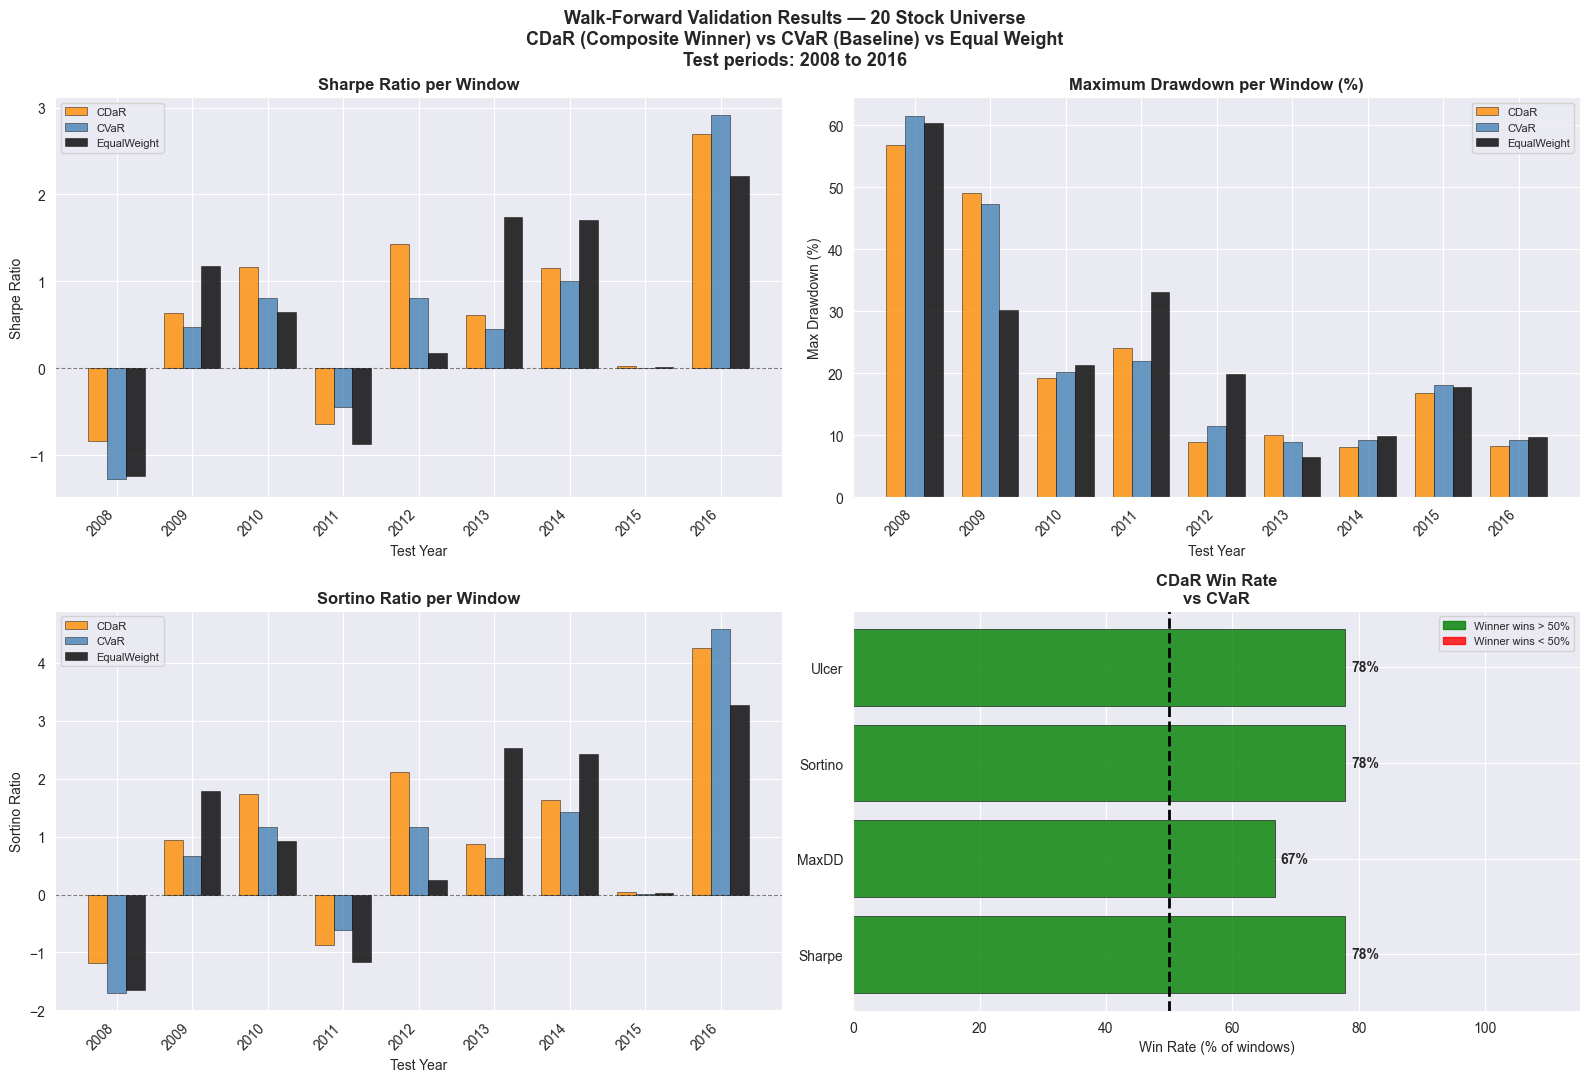

Walk-forward results plot saved


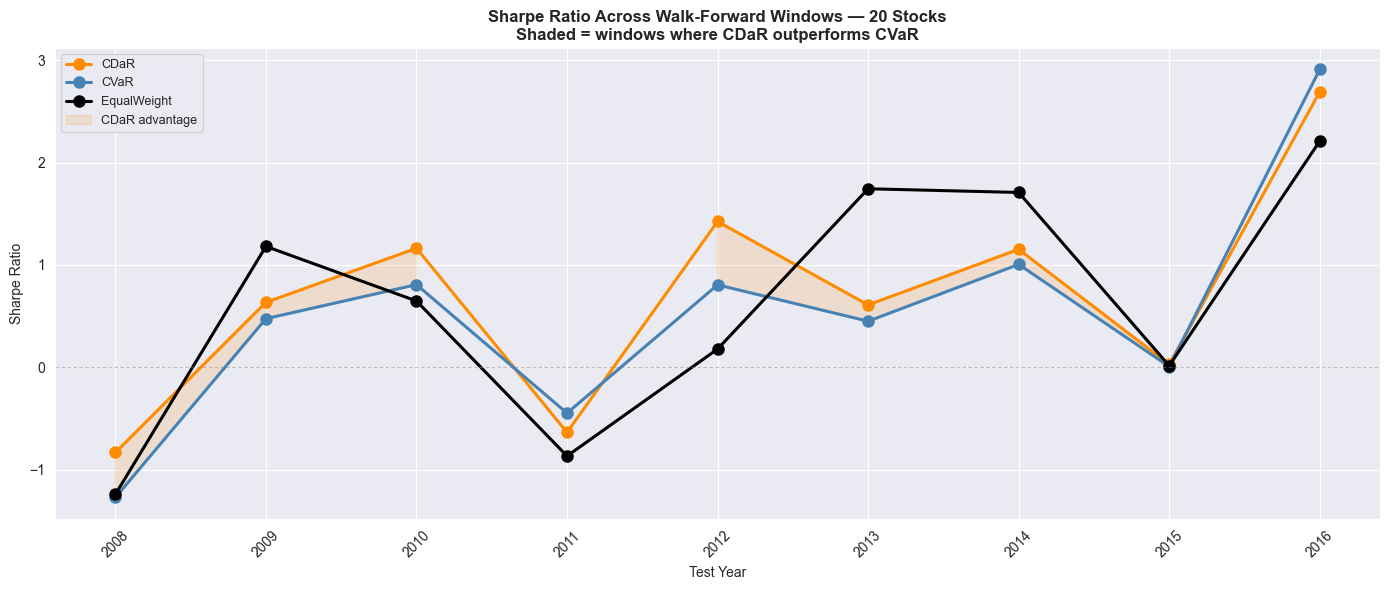

Rolling Sharpe plot saved

WALK-FORWARD DETAILED RESULTS:
───────────────────────────────────────────────────────────────────────────
  Year            CDaR Sharpe          CVaR Sharpe    EW Sharpe   Window Winner
───────────────────────────────────────────────────────────────────────────
  2008                -0.8324              -1.2725      -1.2418            CDaR
  2009                 0.6346               0.4753       1.1816     EqualWeight
  2010                 1.1634               0.8077       0.6481            CDaR
  2011                -0.6359              -0.4477      -0.8673            CVaR
  2012                 1.4251               0.8057       0.1785            CDaR
  2013                 0.6093               0.4504       1.7450     EqualWeight
  2014                 1.1534               1.0056       1.7087     EqualWeight
  2015                 0.0280               0.0070       0.0149            CDaR
  2016                 2.6921               2.9117       2.2112       

In [25]:
# ============================================================
# CELL 24: WALK-FORWARD VALIDATION PLOTS
# ============================================================
# This cell visualises the walk-forward results from Cell 23.
# Model names are loaded dynamically from saved files so
# this cell works correctly regardless of which asset pool
# size was used or which model won the horse race.
#
# FIVE PLOTS PRODUCED:
#
# Plot 1 (Figure 1, Panel top-left): Sharpe ratio per window
#   Shows the Sharpe ratio achieved by each model in each
#   of the nine test years. Higher bars are better.
#
# Plot 2 (Figure 1, Panel top-right): Max Drawdown per window
#   Shows the maximum drawdown in each test year.
#   Lower bars are better for drawdown.
#
# Plot 3 (Figure 1, Panel bottom-left): Sortino ratio per window
#   Shows Sortino ratio in each year. Higher is better.
#   NaN values are replaced with zero for clean plotting.
#
# Plot 4 (Figure 1, Panel bottom-right): Win rate summary
#   Horizontal bar chart showing the percentage of windows
#   where the winning model beat the baseline model on each
#   metric. Green bars mean the winner won more than half
#   the windows. Red bars mean the baseline won more.
#
# Plot 5 (Figure 2): Rolling Sharpe line chart
#   Connects Sharpe ratios across all nine test years as
#   a line chart. Shows the trend in relative performance
#   over time and shades the windows where the winner
#   outperforms the baseline.
# ============================================================

import matplotlib.pyplot as plt          # plotting engine
import matplotlib.patches as mpatches   # custom legend entries
import numpy as np                       # numerical operations
import pandas as pd                      # data loading
import os                                # file paths
import json                              # load config

# ============================================================
# SAFETY CHECKS — reload everything if kernel was restarted
# ============================================================

try:
    ROBUST_FOLDER
    DATA_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY
# ============================================================
# Load from wf_model_names.json saved by Cell 23
# This ensures Cell 24 always uses the same model names
# that Cell 23 used — no hardcoding needed

wf_names_path = os.path.join(ROBUST_FOLDER, 'wf_model_names.json')

if os.path.exists(wf_names_path):
    # Load model names from Cell 23 output
    with open(wf_names_path) as f:
        wf_model_names = json.load(f)
    WINNING_MODEL  = wf_model_names['WINNING_MODEL']
    BASELINE_MODEL = wf_model_names['BASELINE_MODEL']
    print(f"Model names loaded from {wf_names_path}")
else:
    # Fallback to winners.json from Cell 20
    winners_path = os.path.join(DATA_FOLDER, 'winners.json')
    if os.path.exists(winners_path):
        with open(winners_path) as f:
            winners = json.load(f)
        WINNING_MODEL  = winners['WINNING_MODEL']
        BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
        print(f"Model names loaded from {winners_path}")
    else:
        print("WARNING: No model names file found")
        print("Using defaults — run Cells 20 and 23 first")
        WINNING_MODEL  = 'CVaR'
        BASELINE_MODEL = 'SmoothMaxDD'

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ============================================================
# FORCE RELOAD ALL RESULTS FROM DISK
# ============================================================
# Always reload from saved numpy files to prevent duplicate
# entries from multiple Cell 23 runs. These were saved at
# the end of Cell 23 so they are always up to date.

print("\nLoading walk-forward results from disk...")

wf_sharpe = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_sharpe.npy'),
    allow_pickle=True    # required for dict objects
).item()                 # .item() converts numpy array to Python dict
print(f"  wf_sharpe loaded")

wf_max_dd = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_max_dd.npy'),
    allow_pickle=True
).item()
print(f"  wf_max_dd loaded")

wf_sortino = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_sortino.npy'),
    allow_pickle=True
).item()
print(f"  wf_sortino loaded")

wf_ulcer = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_ulcer.npy'),
    allow_pickle=True
).item()
print(f"  wf_ulcer loaded")

wf_test_years = pd.read_csv(
    os.path.join(ROBUST_FOLDER, 'wf_years.csv')
)['year'].astype(str).tolist()   # load as list of year strings
print(f"  wf_test_years: {wf_test_years}")

n_windows = len(wf_test_years)   # total completed windows
print(f"\nWalk-forward windows : {n_windows}")

# Confirm all models have the correct number of results
for model_name in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
    if model_name in wf_sharpe:
        n_res  = len(wf_sharpe[model_name])
        status = "OK" if n_res == n_windows else "MISMATCH"
        print(f"  {model_name:<15} : {n_res} windows — {status}")
    else:
        print(f"  {model_name:<15} : NOT FOUND in results")

# ============================================================
# DEFINE CONSISTENT COLOURS
# ============================================================

# Full colour map covering all possible model names
all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black',
    'MeanCVaR'    : 'grey',
}

# Get colours for the two models being compared
winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

COLOURS = {
    WINNING_MODEL  : winning_colour,
    BASELINE_MODEL : baseline_colour,
    'EqualWeight'  : 'black',
}

print(f"\nColours assigned:")
for model, colour in COLOURS.items():
    print(f"  {model:<15} : {colour}")

# ============================================================
# FIGURE 1: FOUR-PANEL COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'Walk-Forward Validation Results — {DATA_POOL} Stock Universe\n'
    f'{WINNING_MODEL} (Composite Winner) vs '
    f'{BASELINE_MODEL} (Baseline) vs Equal Weight\n'
    f'Test periods: {wf_test_years[0]} to {wf_test_years[-1]}',
    fontsize=13, fontweight='bold'
)

# X positions and bar width for grouped bar charts
x     = np.arange(n_windows)  # one position per window
width = 0.25                   # width of each individual bar

# ============================================================
# PANEL 1: SHARPE RATIO PER WINDOW
# ============================================================

ax1 = axes[0, 0]   # top-left panel

# Plot one group of bars for each model
for i, (model_name, colour) in enumerate([
    (WINNING_MODEL,  COLOURS[WINNING_MODEL]),
    (BASELINE_MODEL, COLOURS[BASELINE_MODEL]),
    ('EqualWeight',  COLOURS['EqualWeight'])
]):
    if model_name in wf_sharpe:
        # Extract Sharpe values for all completed windows
        sharpe_vals = wf_sharpe[model_name][:n_windows]
        ax1.bar(
            x + i * width,   # offset x position for this model
            sharpe_vals,     # bar heights are Sharpe values
            width,           # bar width
            label   = model_name,
            color   = colour,
            alpha   = 0.8,
            edgecolor = 'black',
            linewidth = 0.4
        )

# Add zero reference line — above zero means positive Sharpe
ax1.axhline(
    y=0, color='black', linewidth=0.8,
    linestyle='--', alpha=0.5)

ax1.set_title('Sharpe Ratio per Window', fontweight='bold')
ax1.set_xlabel('Test Year')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_xticks(x + width)   # centre the tick labels
ax1.set_xticklabels(
    wf_test_years, rotation=45, ha='right')
ax1.legend(fontsize=8)

# ============================================================
# PANEL 2: MAX DRAWDOWN PER WINDOW
# ============================================================

ax2 = axes[0, 1]   # top-right panel

for i, (model_name, colour) in enumerate([
    (WINNING_MODEL,  COLOURS[WINNING_MODEL]),
    (BASELINE_MODEL, COLOURS[BASELINE_MODEL]),
    ('EqualWeight',  COLOURS['EqualWeight'])
]):
    if model_name in wf_max_dd:
        # Convert fractions to percentages for readability
        dd_vals = [
            v * 100
            for v in wf_max_dd[model_name][:n_windows]
        ]
        ax2.bar(
            x + i * width,
            dd_vals,
            width,
            label     = model_name,
            color     = colour,
            alpha     = 0.8,
            edgecolor = 'black',
            linewidth = 0.4
        )

ax2.set_title(
    'Maximum Drawdown per Window (%)', fontweight='bold')
ax2.set_xlabel('Test Year')
ax2.set_ylabel('Max Drawdown (%)')
ax2.set_xticks(x + width)
ax2.set_xticklabels(
    wf_test_years, rotation=45, ha='right')
ax2.legend(fontsize=8)

# ============================================================
# PANEL 3: SORTINO RATIO PER WINDOW
# ============================================================

ax3 = axes[1, 0]   # bottom-left panel

for i, (model_name, colour) in enumerate([
    (WINNING_MODEL,  COLOURS[WINNING_MODEL]),
    (BASELINE_MODEL, COLOURS[BASELINE_MODEL]),
    ('EqualWeight',  COLOURS['EqualWeight'])
]):
    if model_name in wf_sortino:
        # Replace NaN with zero for clean plotting
        # NaN occurs when downside deviation is zero
        sortino_vals = [
            v if not np.isnan(v) else 0
            for v in wf_sortino[model_name][:n_windows]
        ]
        ax3.bar(
            x + i * width,
            sortino_vals,
            width,
            label     = model_name,
            color     = colour,
            alpha     = 0.8,
            edgecolor = 'black',
            linewidth = 0.4
        )

# Add zero reference line
ax3.axhline(
    y=0, color='black', linewidth=0.8,
    linestyle='--', alpha=0.5)

ax3.set_title('Sortino Ratio per Window', fontweight='bold')
ax3.set_xlabel('Test Year')
ax3.set_ylabel('Sortino Ratio')
ax3.set_xticks(x + width)
ax3.set_xticklabels(
    wf_test_years, rotation=45, ha='right')
ax3.legend(fontsize=8)

# ============================================================
# PANEL 4: WIN RATE SUMMARY
# ============================================================

ax4 = axes[1, 1]   # bottom-right panel

# Define metrics and their direction for win rate computation
# True means higher is better, False means lower is better
metrics_to_check = {
    'Sharpe'  : (wf_sharpe,  True),
    'MaxDD'   : (wf_max_dd,  False),
    'Sortino' : (wf_sortino, True),
    'Ulcer'   : (wf_ulcer,   False),
}

win_rates   = []   # win rate percentage per metric
metric_lbls = []   # metric name labels for y-axis

for metric_label, (data_dict, higher_better) in \
        metrics_to_check.items():

    if WINNING_MODEL  not in data_dict: continue
    if BASELINE_MODEL not in data_dict: continue

    winner_vals   = data_dict[WINNING_MODEL][:n_windows]
    baseline_vals = data_dict[BASELINE_MODEL][:n_windows]

    wins = 0   # count windows where winner beats baseline
    for i in range(len(winner_vals)):
        w_val = winner_vals[i]
        b_val = baseline_vals[i]

        # Skip comparisons involving NaN
        if np.isnan(w_val) or np.isnan(b_val):
            continue

        if higher_better and w_val > b_val:
            wins += 1   # winner had higher value
        elif not higher_better and w_val < b_val:
            wins += 1   # winner had lower value

    win_rate = wins / len(winner_vals) * 100   # as percentage
    win_rates.append(win_rate)
    metric_lbls.append(metric_label)

# Green bar if winner wins more than half the windows
# Red bar if baseline wins more than half the windows
bar_colours = [
    'green' if wr >= 50 else 'red'
    for wr in win_rates
]

# Plot horizontal win rate bars
bars = ax4.barh(
    metric_lbls,    # metric names on y-axis
    win_rates,      # win rate percentages on x-axis
    color     = bar_colours,
    alpha     = 0.8,
    edgecolor = 'black',
    linewidth = 0.5
)

# Add 50% reference line — crossing this means more wins than losses
ax4.axvline(
    x=50, color='black', linewidth=2,
    linestyle='--', label='50% threshold')

# Add percentage labels at the end of each bar
for bar, wr in zip(bars, win_rates):
    ax4.text(
        bar.get_width() + 1,              # x position
        bar.get_y() + bar.get_height()/2, # y position
        f'{wr:.0f}%',                     # label text
        va='center', fontsize=10,
        fontweight='bold'
    )

ax4.set_title(
    f'{WINNING_MODEL} Win Rate\nvs {BASELINE_MODEL}',
    fontweight='bold')
ax4.set_xlabel('Win Rate (% of windows)')
ax4.set_xlim(0, 115)   # extra space for labels

# Add colour legend
green_patch = mpatches.Patch(
    color='green', alpha=0.8, label='Winner wins > 50%')
red_patch   = mpatches.Patch(
    color='red',   alpha=0.8, label='Winner wins < 50%')
ax4.legend(
    handles=[green_patch, red_patch], fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'walk_forward_results.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Walk-forward results plot saved")

# ============================================================
# FIGURE 2: ROLLING SHARPE LINE CHART
# ============================================================
# Shows how Sharpe ratios evolved across the nine test years
# as a line chart rather than a bar chart. Easier to see
# trends and consistent outperformance over time.

fig2, ax = plt.subplots(figsize=(14, 6))

for model_name, colour in COLOURS.items():
    if model_name in wf_sharpe:
        sharpe_vals = wf_sharpe[model_name][:n_windows]
        ax.plot(
            wf_test_years,   # x-axis: test year labels
            sharpe_vals,     # y-axis: Sharpe ratio per year
            marker    = 'o', # circle marker at each data point
            color     = colour,
            linewidth = 2.2,
            markersize= 8,
            label     = model_name
        )

# Shade windows where winning model beats baseline
# fill_between creates a shaded region between two series
if (WINNING_MODEL  in wf_sharpe and
        BASELINE_MODEL in wf_sharpe):
    wm_sharpes = wf_sharpe[WINNING_MODEL][:n_windows]
    bm_sharpes = wf_sharpe[BASELINE_MODEL][:n_windows]

    # Create a boolean mask: True where winner beats baseline
    winner_ahead = [
        wm_sharpes[i] > bm_sharpes[i]
        for i in range(n_windows)
    ]

    ax.fill_between(
        wf_test_years,   # x positions
        wm_sharpes,      # upper boundary when winner ahead
        bm_sharpes,      # lower boundary when winner ahead
        where  = winner_ahead,   # only shade where winner beats
        alpha  = 0.15,           # semi-transparent fill
        color  = winning_colour, # use winning model colour
        label  = f'{WINNING_MODEL} advantage'
    )

# Zero reference line
ax.axhline(
    y=0, color='grey', linewidth=0.8,
    linestyle='--', alpha=0.5)

ax.set_title(
    f'Sharpe Ratio Across Walk-Forward Windows — '
    f'{DATA_POOL} Stocks\n'
    f'Shaded = windows where {WINNING_MODEL} '
    f'outperforms {BASELINE_MODEL}',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Test Year')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9, loc='best')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'walk_forward_sharpe.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Rolling Sharpe plot saved")

# ============================================================
# DETAILED SUMMARY TABLE
# ============================================================

print(f"\nWALK-FORWARD DETAILED RESULTS:")
print(f"{'─'*75}")
print(
    f"  {'Year':<8} "
    f"{WINNING_MODEL+' Sharpe':>18} "
    f"{BASELINE_MODEL+' Sharpe':>20} "
    f"{'EW Sharpe':>12} "
    f"{'Window Winner':>15}"
)
print(f"{'─'*75}")

for i in range(n_windows):
    wm_s = wf_sharpe[WINNING_MODEL][i]
    bm_s = wf_sharpe[BASELINE_MODEL][i]
    ew_s = wf_sharpe['EqualWeight'][i]

    # Determine which model had the highest Sharpe this window
    scores = {
        WINNING_MODEL  : wm_s,
        BASELINE_MODEL : bm_s,
        'EqualWeight'  : ew_s
    }
    window_winner = max(scores, key=scores.get)

    print(
        f"  {wf_test_years[i]:<8} "
        f"{wm_s:>18.4f} "
        f"{bm_s:>20.4f} "
        f"{ew_s:>12.4f} "
        f"{window_winner:>15}"
    )

print(f"{'─'*75}")

# Count total window wins per model
win_counts = {
    WINNING_MODEL  : 0,
    BASELINE_MODEL : 0,
    'EqualWeight'  : 0
}
for i in range(n_windows):
    scores = {
        WINNING_MODEL  : wf_sharpe[WINNING_MODEL][i],
        BASELINE_MODEL : wf_sharpe[BASELINE_MODEL][i],
        'EqualWeight'  : wf_sharpe['EqualWeight'][i]
    }
    best_model = max(scores, key=scores.get)
    win_counts[best_model] += 1

print(f"\nOVERALL WINDOW WINS (by Sharpe Ratio):")
print(f"{'─'*40}")
for model, wins in win_counts.items():
    pct = wins / n_windows * 100
    print(f"  {model:<15} : "
          f"{wins}/{n_windows} ({pct:.0f}%)")
print(f"{'─'*40}")

print(f"\nCell 24 complete")
print(f"Next: Cell 25 — Block Bootstrap")

In [26]:
# ============================================================
# CELL 25: LENS 2 — BLOCK BOOTSTRAP
# ============================================================
# Block Bootstrap tests STATISTICAL SIGNIFICANCE.
# It asks: "Is the winning model's outperformance genuinely
# robust across different return paths, or did it just happen
# to get lucky with the specific sequence of returns that
# occurred in our 2020-2024 test period?"
#
# WHY BLOCK BOOTSTRAP INSTEAD OF PLAIN BOOTSTRAP?
#   Financial returns are NOT independently distributed.
#   Today's return is correlated with yesterday's return.
#   This is called autocorrelation or serial dependence.
#   Plain bootstrap resamples individual days randomly,
#   destroying this autocorrelation structure and producing
#   unrealistic return sequences.
#
#   Block bootstrap resamples BLOCKS of consecutive days
#   (BLOCK_SIZE=20 = approximately one trading month).
#   This preserves the short-term autocorrelation structure
#   and produces more realistic resampled paths.
#
# HOW IT WORKS:
#   1. Start with the trained model weights for each day
#      in the test period (already computed in Cell 19)
#   2. Randomly select N_BOOTSTRAP=500 starting positions
#      in the test period
#   3. Extract blocks of 20 consecutive days from each
#      starting position and stitch them together to form
#      a new return path of the same total length
#   4. Compute portfolio returns on the resampled path
#      using the same model weights
#   5. Compute all performance metrics on the resampled path
#   6. Repeat 500 times to get a distribution of metrics
#   7. Compare distributions using the Wilcoxon signed-rank test
#
# WILCOXON SIGNED-RANK TEST:
#   Null hypothesis H0: the median performance difference
#   between the winning model and the CVaR baseline is zero.
#   Alternative hypothesis H1: there is a statistically
#   significant difference.
#   p < 0.05 threshold means we reject H0 and conclude the
#   difference is statistically significant.
#   We use Wilcoxon rather than a t-test because financial
#   returns are not normally distributed.
#
# ESTIMATED TIME: approximately 5-10 minutes
# ============================================================

import numpy as np                    # numerical operations
import pandas as pd                   # data loading
import matplotlib.pyplot as plt       # plotting
import matplotlib.patches as mpatches # legend entries
import scipy.stats as scipy_stats     # Wilcoxon test
import torch                          # model loading
import os                             # file paths
import json                           # config loading

# ============================================================
# SAFETY CHECKS
# ============================================================

try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE set to: {DEVICE}")

try:
    DATA_FOLDER
    SIG_FOLDER
    MODELS_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock all random seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['PYTHONHASHSEED']       = str(seed)
    print("set_all_seeds redefined")

try:
    GLOBAL_SEED
except NameError:
    GLOBAL_SEED = 42
    print(f"GLOBAL_SEED set to {GLOBAL_SEED}")

try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
except NameError:
    D_MODEL  = 64    # Transformer internal dimension
    N_HEADS  = 4     # number of attention heads
    N_LAYERS = 2     # number of encoder layers
    DROPOUT  = 0.1   # dropout rate
    print("Model hyperparameters set to defaults")

try:
    SIT
except NameError:
    print("ERROR: SIT class not defined. Run Cell 12 first.")
    raise

try:
    compute_metrics
    compute_turnover
except NameError:
    print("ERROR: Metric functions not defined. Run Cell 15 first.")
    raise

# Reload test features and returns if not in memory
try:
    test_features_final
    test_returns_aligned
except NameError:
    print("Reloading test data from disk...")
    test_features_final  = np.load(
        os.path.join(SIG_FOLDER, 'test_features.npy'))
    test_returns_aligned = np.load(
        os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'))
    print(f"  test_features  : {test_features_final.shape}")
    print(f"  test_returns   : {test_returns_aligned.shape}")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY FROM winners.json
# ============================================================
# We always load model names from the saved file rather than
# relying on variables in memory. This makes the cell robust
# to kernel restarts between sessions.

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    with open(winners_path) as f:
        winners = json.load(f)
    WINNING_MODEL  = winners['WINNING_MODEL']
    BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
    print(f"\nWinners loaded from {winners_path}")
else:
    print(f"WARNING: {winners_path} not found")
    print(f"Please run Cell 20 first")
    WINNING_MODEL  = 'CVaR'
    BASELINE_MODEL = 'SmoothMaxDD'

# Handle edge case where both names are the same model
# This can happen if one model wins both rankings
if WINNING_MODEL == BASELINE_MODEL:
    print(f"WARNING: Winner equals baseline. Adjusting...")
    BASELINE_MODEL = (
        'CVaR'
        if WINNING_MODEL != 'CVaR'
        else 'SmoothMaxDD'
    )

print(f"\nWINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")
print(f"EQUAL WEIGHT   : EqualWeight")

# ============================================================
# BOOTSTRAP CONFIGURATION
# ============================================================

N_BOOTSTRAP = 500  # number of resampled paths to generate
BLOCK_SIZE  = 20   # consecutive days per block (1 trading month)
# Using 20-day blocks preserves the short-term autocorrelation
# structure of financial returns. Plain day-by-day resampling
# would destroy this structure and produce unrealistic paths.

print(f"\n{'='*60}")
print(f"  LENS 2: BLOCK BOOTSTRAP CONFIGURATION")
print(f"{'='*60}")
print(f"  Bootstrap samples    : {N_BOOTSTRAP}")
print(f"  Block size           : {BLOCK_SIZE} days")
print(f"  Test period length   : {len(test_returns_aligned)} days")
print(f"  Winning model        : {WINNING_MODEL}")
print(f"  Baseline model       : {BASELINE_MODEL}")
print(f"  Significance level   : p < 0.05")
print(f"  Test used            : Wilcoxon signed-rank")
print(f"  H0                   : median difference = 0")
print(f"{'='*60}")

# ============================================================
# LOAD TRAINED MODEL CHECKPOINTS
# ============================================================
# We load the models trained on the full training set in
# Cell 19. We do NOT retrain here. The bootstrap only
# resamples the TEST returns to test whether the evaluation
# result is stable across alternative return sequences.

print("\nLoading trained model checkpoints...")

# Get actual dimensions from test data
actual_n_features = test_features_final.shape[1]  # 2550
actual_n_assets   = test_returns_aligned.shape[1] # 50

print(f"  actual_n_features : {actual_n_features}")
print(f"  actual_n_assets   : {actual_n_assets}")

# ---- Load WINNING MODEL ----
set_all_seeds(GLOBAL_SEED)   # reset seeds before loading

winning_model_bs = SIT(
    n_features = actual_n_features,   # feature vector size
    n_assets   = actual_n_assets,     # number of stocks
    d_model    = D_MODEL,             # Transformer dimension
    n_heads    = N_HEADS,             # attention heads
    n_layers   = N_LAYERS,            # encoder layers
    dropout    = DROPOUT              # dropout rate
).to(DEVICE)

winning_ckpt = os.path.join(
    MODELS_FOLDER, f'{WINNING_MODEL}_best.pt')

# Verify the checkpoint file exists before loading
if not os.path.exists(winning_ckpt):
    print(f"ERROR: {winning_ckpt} not found")
    print("Please run Cell 19 (horse race) first")
    raise FileNotFoundError(winning_ckpt)

winning_model_bs.load_state_dict(
    torch.load(
        winning_ckpt,
        map_location = 'cpu',   # load onto CPU
        weights_only = True     # safer loading mode
    )
)
winning_model_bs.eval()   # disable dropout for evaluation
print(f"  {WINNING_MODEL} model loaded from {winning_ckpt}")

# ---- Load BASELINE MODEL ----
set_all_seeds(GLOBAL_SEED)   # reset seeds before loading

baseline_model_bs = SIT(
    n_features = actual_n_features,
    n_assets   = actual_n_assets,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT
).to(DEVICE)

baseline_ckpt = os.path.join(
    MODELS_FOLDER, f'{BASELINE_MODEL}_best.pt')

if not os.path.exists(baseline_ckpt):
    print(f"ERROR: {baseline_ckpt} not found")
    print("Please run Cell 19 (horse race) first")
    raise FileNotFoundError(baseline_ckpt)

baseline_model_bs.load_state_dict(
    torch.load(
        baseline_ckpt,
        map_location = 'cpu',
        weights_only = True
    )
)
baseline_model_bs.eval()
print(f"  {BASELINE_MODEL} model loaded from {baseline_ckpt}")

# ============================================================
# COMPUTE PORTFOLIO WEIGHTS ON FULL TEST SET
# ============================================================
# We compute weights ONCE for the full test set before
# bootstrapping begins. This is much faster than running the
# model 500 times inside the bootstrap loop.
# We then resample the weights together with the returns so
# that the weight-return alignment is always preserved.

print("\nComputing portfolio weights on full test set...")

# Convert test features to tensor once
feat_tensor = torch.tensor(
    test_features_final,    # numpy array
    dtype = torch.float32   # convert to float32 tensor
).to(DEVICE)

# Get weights from winning model — no gradients needed
with torch.no_grad():   # disable gradient computation
    winning_weights_all = winning_model_bs(
        feat_tensor).cpu().numpy()

# Get weights from baseline model
with torch.no_grad():
    baseline_weights_all = baseline_model_bs(
        feat_tensor).cpu().numpy()

# Equal weight: 1/N per stock every day
ew_weights_all = (
    np.ones_like(winning_weights_all) /
    winning_weights_all.shape[1]   # divide by number of assets
)

print(f"  {WINNING_MODEL} weights  : {winning_weights_all.shape}")
print(f"  {BASELINE_MODEL} weights : {baseline_weights_all.shape}")
print(f"  EqualWeight weights      : {ew_weights_all.shape}")

# ============================================================
# DEFINE BLOCK BOOTSTRAP FUNCTION
# ============================================================

def block_bootstrap_metrics(
    weights_series,   # portfolio weights (T, N_ASSETS)
    returns_series,   # asset returns (T, N_ASSETS)
    block_size,       # consecutive days per block
    n_bootstrap,      # number of bootstrap iterations
    seed=42           # random seed for reproducibility
):
    """
    Perform block bootstrap resampling on test returns.

    At each iteration:
    1. Randomly select starting positions for blocks
    2. Stitch blocks together to form a new return path
       of the same total length as the original
    3. Compute portfolio returns on the resampled path
       using the same weights as the original evaluation
    4. Compute all performance metrics on the resampled path

    Using blocks rather than individual days preserves
    the short-term autocorrelation structure of returns
    which is critical for realistic resampling of
    financial time series.

    Parameters
    ----------
    weights_series : np.ndarray, shape (T, N_ASSETS)
        Portfolio weights from the trained model.
        Resampled together with returns to preserve alignment.
    returns_series : np.ndarray, shape (T, N_ASSETS)
        Asset returns for the test period.
    block_size : int
        Number of consecutive days per block.
    n_bootstrap : int
        Number of bootstrap iterations to perform.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    bootstrap_metrics : list of dict
        Performance metrics for each bootstrap sample.
        Length equals n_bootstrap.
    """

    np.random.seed(seed)            # lock random seed
    T        = returns_series.shape[0]   # total test days
    n_blocks = T // block_size + 1       # number of blocks needed
    # We need slightly more than T/block_size blocks to fill T days

    bootstrap_metrics = []   # store metrics for all iterations

    for b in range(n_bootstrap):

        # ---- Step 1: Randomly select block starting positions ----
        # Each start is an integer in [0, T - block_size]
        # This ensures every block fits within the test period
        starts = np.random.randint(
            0,               # minimum start index
            T - block_size,  # maximum start index
            size = n_blocks  # number of blocks to sample
        )

        # ---- Step 2: Stitch RETURN blocks together ----
        # For each starting position extract block_size
        # consecutive return rows and concatenate them
        # Then trim to length T to get exactly T days
        resampled_returns = np.concatenate([
            returns_series[s : s + block_size]  # one block
            for s in starts
        ])[:T]   # trim to original length

        # ---- Step 3: Stitch WEIGHT blocks using same starts ----
        # IMPORTANT: we use the SAME starting positions for
        # both returns and weights. This preserves the alignment
        # between weights[t] and returns[t] after resampling.
        # If we used different starts the weight-return pairing
        # would be broken and portfolio returns would be wrong.
        resampled_weights = np.concatenate([
            weights_series[s : s + block_size]  # same blocks
            for s in starts
        ])[:T]   # trim to original length

        # ---- Step 4: Compute portfolio returns ----
        # Element-wise multiply weights by returns then sum
        # across the asset dimension to get one return per day
        port_ret = (
            resampled_weights * resampled_returns
        ).sum(axis=1)   # shape: (T,)

        # ---- Step 5: Compute all performance metrics ----
        metrics = compute_metrics(port_ret)
        metrics['Turnover'] = compute_turnover(
            resampled_weights)
        bootstrap_metrics.append(metrics)

        # Print progress every 100 iterations
        if (b + 1) % 100 == 0:
            print(f"  Bootstrap {b+1}/{n_bootstrap} complete")

    return bootstrap_metrics

# ============================================================
# RUN BOOTSTRAP FOR ALL THREE STRATEGIES
# ============================================================

print(f"\nRunning {N_BOOTSTRAP} bootstrap iterations...")
print(f"Block size : {BLOCK_SIZE} days")
print(f"Approximate time : 5-10 minutes\n")

# ---- Bootstrap WINNING MODEL ----
print(f"Bootstrapping {WINNING_MODEL}...")
winning_bootstrap = block_bootstrap_metrics(
    weights_series = winning_weights_all,   # winning model weights
    returns_series = test_returns_aligned,  # test period returns
    block_size     = BLOCK_SIZE,            # 20-day blocks
    n_bootstrap    = N_BOOTSTRAP,           # 500 iterations
    seed           = GLOBAL_SEED            # reproducible
)
print(f"  {WINNING_MODEL} bootstrap complete\n")

# ---- Bootstrap BASELINE MODEL ----
print(f"Bootstrapping {BASELINE_MODEL}...")
baseline_bootstrap = block_bootstrap_metrics(
    weights_series = baseline_weights_all,  # baseline weights
    returns_series = test_returns_aligned,  # same test returns
    block_size     = BLOCK_SIZE,            # same block size
    n_bootstrap    = N_BOOTSTRAP,           # same iterations
    seed           = GLOBAL_SEED            # same seed
)
print(f"  {BASELINE_MODEL} bootstrap complete\n")

# ---- Bootstrap EQUAL WEIGHT ----
print(f"Bootstrapping EqualWeight...")
ew_bootstrap = block_bootstrap_metrics(
    weights_series = ew_weights_all,        # equal weights
    returns_series = test_returns_aligned,  # same returns
    block_size     = BLOCK_SIZE,
    n_bootstrap    = N_BOOTSTRAP,
    seed           = GLOBAL_SEED
)
print(f"  EqualWeight bootstrap complete\n")

print(f"All {N_BOOTSTRAP} bootstrap iterations complete")

# ============================================================
# EXTRACT METRIC DISTRIBUTIONS
# ============================================================
# Pull one metric out of all 500 bootstrap results for
# each model to get a distribution of 500 values.

def extract_metric(bootstrap_list, metric_name):
    """
    Extract one metric from all bootstrap samples.
    Skips NaN values for clean distribution computation.

    Parameters
    ----------
    bootstrap_list : list of dict
        List of metric dictionaries from block_bootstrap_metrics
    metric_name : str
        The metric to extract

    Returns
    -------
    values : np.ndarray
        Array of metric values across all bootstrap samples.
    """
    return np.array([
        b[metric_name]                     # get the metric value
        for b in bootstrap_list            # for each bootstrap sample
        if not np.isnan(b[metric_name])    # skip NaN values
    ])

# Extract distributions for each metric and each model
winning_sharpes  = extract_metric(winning_bootstrap,  'Sharpe Ratio')
baseline_sharpes = extract_metric(baseline_bootstrap, 'Sharpe Ratio')
ew_sharpes       = extract_metric(ew_bootstrap,       'Sharpe Ratio')

winning_maxdd    = extract_metric(winning_bootstrap,  'Max Drawdown')
baseline_maxdd   = extract_metric(baseline_bootstrap, 'Max Drawdown')
ew_maxdd         = extract_metric(ew_bootstrap,       'Max Drawdown')

winning_ulcer    = extract_metric(winning_bootstrap,  'Ulcer Index')
baseline_ulcer   = extract_metric(baseline_bootstrap, 'Ulcer Index')
ew_ulcer         = extract_metric(ew_bootstrap,       'Ulcer Index')

winning_sortino  = extract_metric(winning_bootstrap,  'Sortino Ratio')
baseline_sortino = extract_metric(baseline_bootstrap, 'Sortino Ratio')
ew_sortino       = extract_metric(ew_bootstrap,       'Sortino Ratio')

winning_calmar   = extract_metric(winning_bootstrap,  'Calmar Ratio')
baseline_calmar  = extract_metric(baseline_bootstrap, 'Calmar Ratio')
ew_calmar        = extract_metric(ew_bootstrap,       'Calmar Ratio')

print(f"\nMetric distributions extracted:")
print(f"  Sharpe: {len(winning_sharpes)} samples per model")

# ============================================================
# STATISTICAL TESTS
# ============================================================
# Wilcoxon signed-rank test is applied to each metric.
# It tests whether the median difference between winning
# and baseline model performance is zero.
# We use Wilcoxon (non-parametric) rather than a t-test
# because financial return distributions are not normal.

print(f"\n{'='*65}")
print(f"  WILCOXON SIGNED-RANK TESTS")
print(f"  H0: median difference between models = 0")
print(f"  H1: {WINNING_MODEL} significantly outperforms")
print(f"  Threshold: p < 0.05")
print(f"{'─'*65}")
print(
    f"  {'Metric':<20} "
    f"{'Win Rate':>10} "
    f"{'p-value':>10} "
    f"{'Sig':>5} "
    f"{'Result':>20}"
)
print(f"{'─'*65}")

# Define all metric comparisons
# Each tuple: (metric_name, winner_dist, baseline_dist, higher_better)
test_metrics = [
    ('Sharpe Ratio',  winning_sharpes,  baseline_sharpes,  True),
    ('Max Drawdown',  winning_maxdd,    baseline_maxdd,    False),
    ('Ulcer Index',   winning_ulcer,    baseline_ulcer,    False),
    ('Sortino Ratio', winning_sortino,  baseline_sortino,  True),
    ('Calmar Ratio',  winning_calmar,   baseline_calmar,   True),
]

stat_results = {}   # store test results for later cells

for metric, w_dist, b_dist, higher_better in test_metrics:

    # Run Wilcoxon signed-rank test on paired samples
    # w_dist[i] and b_dist[i] are from the same bootstrap sample
    stat, p_value = scipy_stats.wilcoxon(w_dist, b_dist)

    # Win rate: fraction of bootstrap samples where winner beats baseline
    if higher_better:
        win_rate = (w_dist > b_dist).mean() * 100
    else:
        win_rate = (w_dist < b_dist).mean() * 100

    # Significance stars
    sig = (
        '***' if p_value < 0.001
        else '**'  if p_value < 0.01
        else '*'   if p_value < 0.05
        else 'ns'
    )

    # Determine the result text
    if win_rate >= 50 and p_value < 0.05:
        result = f'{WINNING_MODEL} wins'
    elif win_rate < 50 and p_value < 0.05:
        result = f'{BASELINE_MODEL} wins'
    else:
        result = 'No sig. difference'

    # Store for Cell 26
    stat_results[metric] = {
        'Win Rate'    : win_rate,
        'P-Value'     : p_value,
        'Significant' : sig
    }

    print(
        f"  {metric:<20} "
        f"{win_rate:>9.1f}% "
        f"{p_value:>10.4f} "
        f"{sig:>5} "
        f"{result:>20}"
    )

print(f"{'─'*65}")
print("  *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

# ============================================================
# CONFIDENCE INTERVALS
# ============================================================
# 95% confidence intervals show the range within which
# the true metric value lies in 95% of bootstrap samples.
# Narrow intervals mean the result is consistent.
# Wide intervals mean the result is variable.

print(f"\n95% CONFIDENCE INTERVALS:")
print(f"{'─'*65}")
print(
    f"  {'Metric':<20} "
    f"{'Model':<15} "
    f"{'Mean':>8} "
    f"{'2.5%':>8} "
    f"{'97.5%':>8}"
)
print(f"{'─'*65}")

ci_data = [
    ('Sharpe Ratio',
     winning_sharpes,  baseline_sharpes,  ew_sharpes),
    ('Max Drawdown',
     winning_maxdd,    baseline_maxdd,    ew_maxdd),
    ('Ulcer Index',
     winning_ulcer,    baseline_ulcer,    ew_ulcer),
    ('Sortino Ratio',
     winning_sortino,  baseline_sortino,  ew_sortino),
]

for metric, w_d, b_d, e_d in ci_data:
    for model_name, dist in [
        (WINNING_MODEL,  w_d),
        (BASELINE_MODEL, b_d),
        ('EqualWeight',  e_d)
    ]:
        mean  = np.mean(dist)
        lower = np.percentile(dist, 2.5)    # 2.5th percentile
        upper = np.percentile(dist, 97.5)   # 97.5th percentile
        print(
            f"  {metric:<20} "
            f"{model_name:<15} "
            f"{mean:>8.4f} "
            f"{lower:>8.4f} "
            f"{upper:>8.4f}"
        )
    print(f"  {'─'*63}")

# ============================================================
# SAVE ALL BOOTSTRAP RESULTS TO DISK
# ============================================================
# Save all distributions so Cell 26 can plot them
# without having to redo the bootstrap computation

np.save(os.path.join(ROBUST_FOLDER,'winning_sharpes.npy'),
        winning_sharpes)
np.save(os.path.join(ROBUST_FOLDER,'baseline_sharpes.npy'),
        baseline_sharpes)
np.save(os.path.join(ROBUST_FOLDER,'ew_sharpes.npy'),
        ew_sharpes)
np.save(os.path.join(ROBUST_FOLDER,'winning_maxdd_bs.npy'),
        winning_maxdd)
np.save(os.path.join(ROBUST_FOLDER,'baseline_maxdd_bs.npy'),
        baseline_maxdd)
np.save(os.path.join(ROBUST_FOLDER,'ew_maxdd_bs.npy'),
        ew_maxdd)
np.save(os.path.join(ROBUST_FOLDER,'winning_ulcer_bs.npy'),
        winning_ulcer)
np.save(os.path.join(ROBUST_FOLDER,'baseline_ulcer_bs.npy'),
        baseline_ulcer)
np.save(os.path.join(ROBUST_FOLDER,'winning_sortino_bs.npy'),
        winning_sortino)
np.save(os.path.join(ROBUST_FOLDER,'baseline_sortino_bs.npy'),
        baseline_sortino)
np.save(os.path.join(ROBUST_FOLDER,'ew_sortino_bs.npy'),
        ew_sortino)

# Save statistical test results as CSV for the report
pd.DataFrame(stat_results).T.to_csv(
    os.path.join(ROBUST_FOLDER, 'bootstrap_stats.csv'))
print(f"\nBootstrap stats saved to bootstrap_stats.csv")

# Save model names for Cell 26
with open(os.path.join(
    ROBUST_FOLDER, 'bs_model_names.json'), 'w') as f:
    json.dump({
        'WINNING_MODEL'  : WINNING_MODEL,
        'BASELINE_MODEL' : BASELINE_MODEL
    }, f, indent=2)

print(f"Bootstrap results saved to {ROBUST_FOLDER}/")
print(f"\nCell 25 complete")
print(f"Next: Cell 26 — Bootstrap Plots")


Winners loaded from data_paper_20\winners.json

WINNING_MODEL  : CDaR
BASELINE_MODEL : CVaR
EQUAL WEIGHT   : EqualWeight

  LENS 2: BLOCK BOOTSTRAP CONFIGURATION
  Bootstrap samples    : 500
  Block size           : 20 days
  Test period length   : 1236 days
  Winning model        : CDaR
  Baseline model       : CVaR
  Significance level   : p < 0.05
  Test used            : Wilcoxon signed-rank
  H0                   : median difference = 0

Loading trained model checkpoints...
  actual_n_features : 420
  actual_n_assets   : 20
All seeds locked to: 42
  CDaR model loaded from data_paper_20\models\CDaR_best.pt
All seeds locked to: 42
  CVaR model loaded from data_paper_20\models\CVaR_best.pt

Computing portfolio weights on full test set...
  CDaR weights  : (1236, 20)
  CVaR weights : (1236, 20)
  EqualWeight weights      : (1236, 20)

Running 500 bootstrap iterations...
Block size : 20 days
Approximate time : 5-10 minutes

Bootstrapping CDaR...
  Bootstrap 100/500 complete
  Bootstra

Model names loaded from data_paper_20\robustness\bs_model_names.json
WINNING_MODEL  : CDaR
BASELINE_MODEL : CVaR

Loading bootstrap distributions from disk...
  Sharpe distributions loaded
  Max Drawdown distributions loaded
  Ulcer Index distributions loaded
  Sortino distributions loaded
  Statistical test results loaded

Bootstrap samples : 500


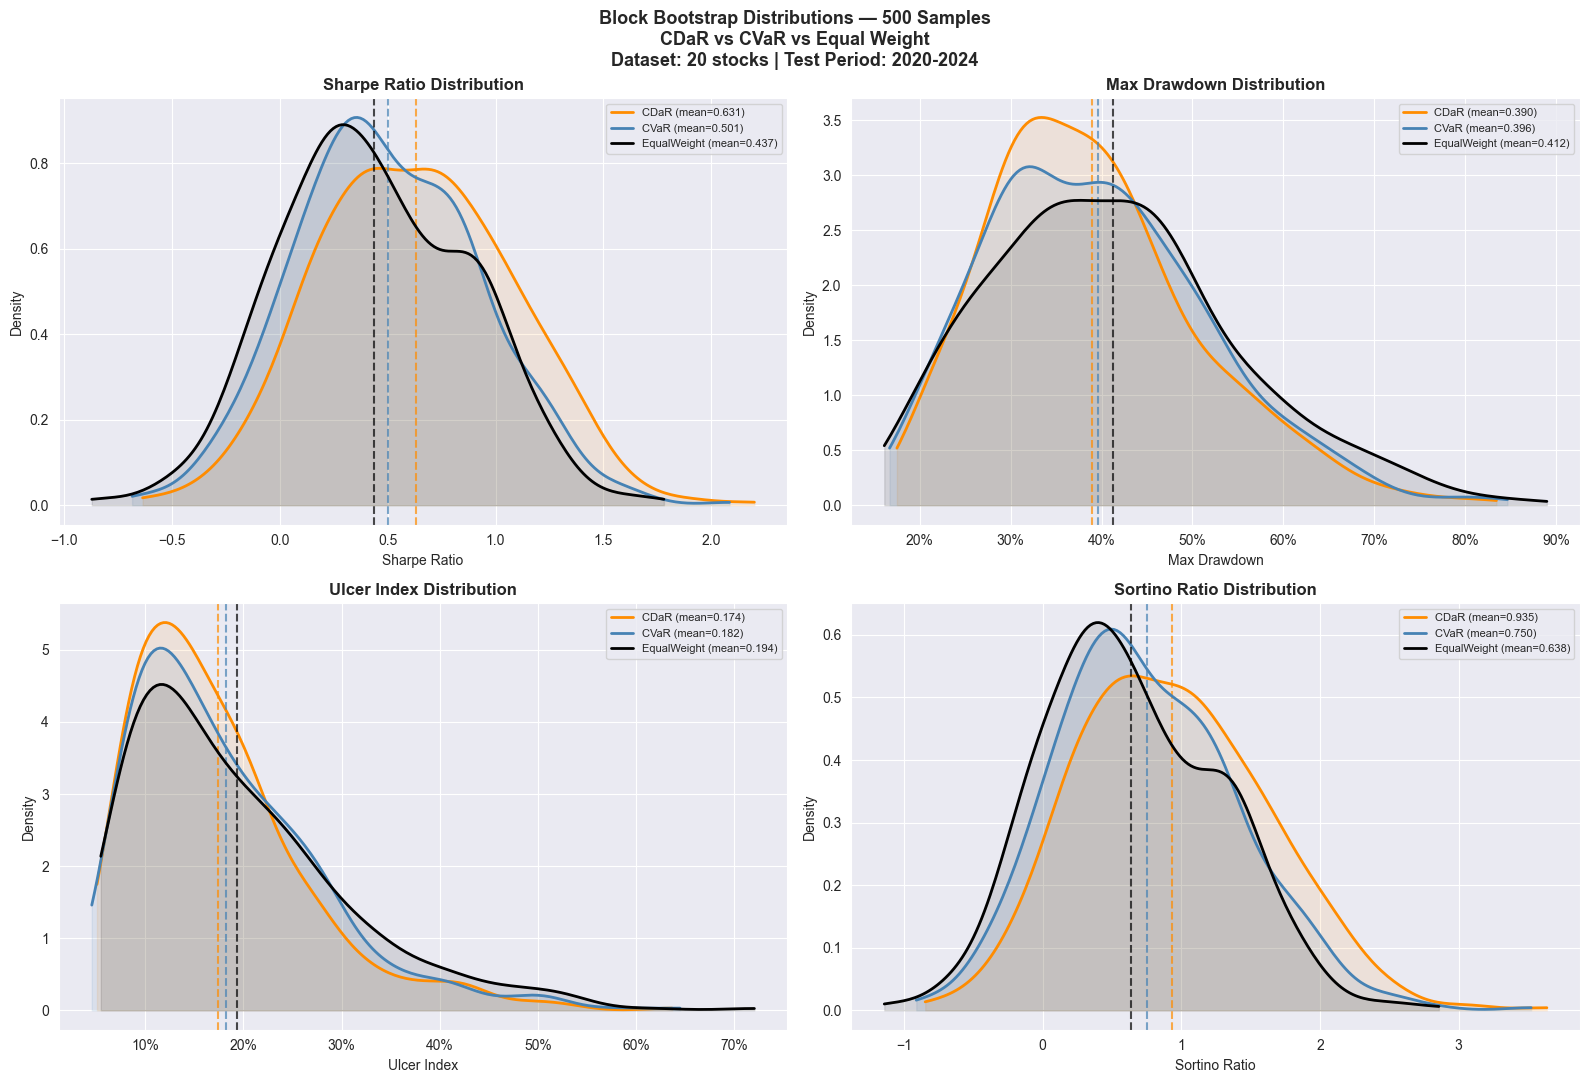

Figure 1 saved: bootstrap_distributions.png


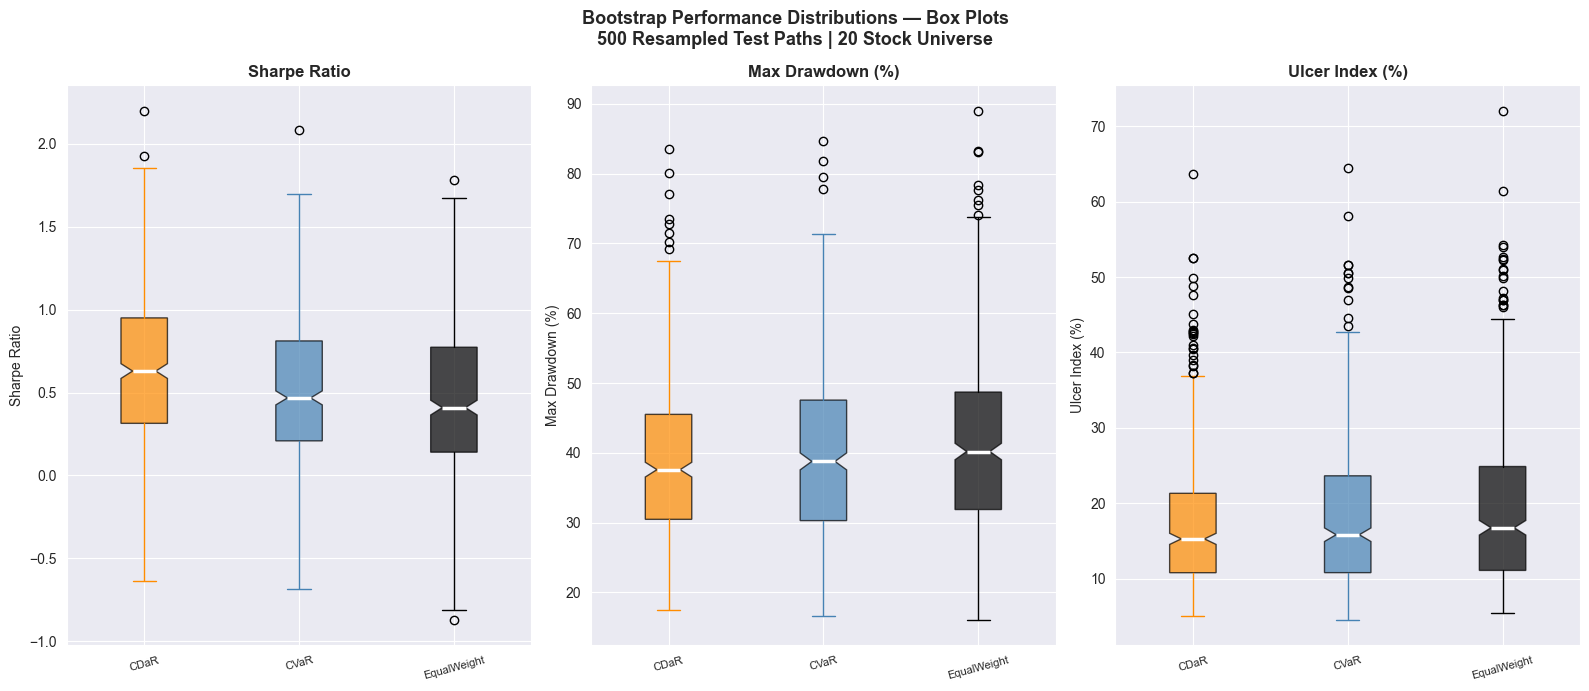

Figure 2 saved: bootstrap_boxplots.png


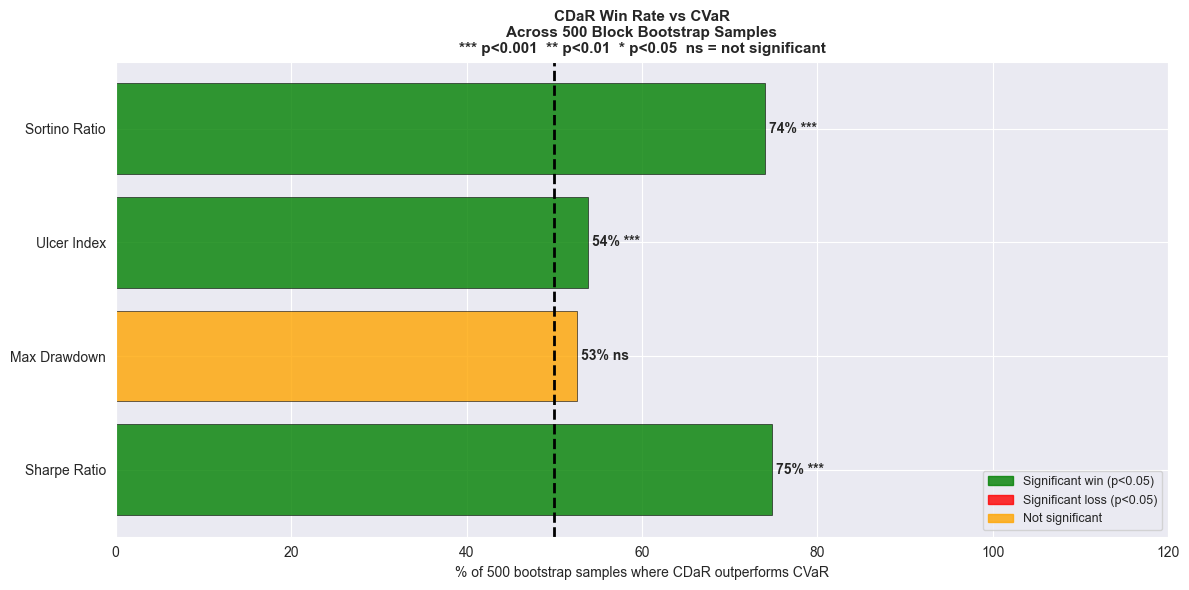

Figure 3 saved: bootstrap_win_rates.png

BOOTSTRAP SUMMARY TABLE:
────────────────────────────────────────────────────────────────────────
  Metric                       CDaR           CVaR   EqualWeight   Win Rate   p-value
────────────────────────────────────────────────────────────────────────
  Sharpe Ratio               0.6305         0.5014        0.4369      74.8%    0.0000
  Max Drawdown               39.00%         39.58%        41.22%      52.6%    0.0814
  Ulcer Index                17.40%         18.19%        19.36%      53.8%    0.0004
  Sortino Ratio              0.9348         0.7501        0.6385      74.0%    0.0000
────────────────────────────────────────────────────────────────────────

INTERPRETATION:
  Win Rate > 50% = CDaR better on that metric
  Win Rate < 50% = CVaR better on that metric
  p < 0.05       = statistically significant difference
  p >= 0.05      = difference may be due to chance

Cell 26 complete
Next: Cell 27 — Stress Scenario Testing


In [27]:
# ============================================================
# CELL 26: BLOCK BOOTSTRAP PLOTS
# ============================================================
# This cell visualises the bootstrap distributions from
# Cell 25. Model names are loaded dynamically from the
# saved bs_model_names.json file.
#
# THREE FIGURES PRODUCED:
#
# Figure 1: KDE Distribution Plots (4 panels)
#   Kernel Density Estimation shows the full shape of each
#   metric's distribution across 500 bootstrap samples.
#   Overlapping distributions mean similar performance.
#   Separated distributions mean meaningful differences.
#   Dashed vertical lines show the mean of each distribution.
#
# Figure 2: Box Plots (3 panels)
#   Shows median, interquartile range, and outliers for
#   three key metrics. Notched boxes show the 95% confidence
#   interval around the median. If notches do not overlap
#   across models the medians are significantly different.
#
# Figure 3: Win Rate Summary with Significance Stars
#   Horizontal bar chart showing the percentage of 500
#   bootstrap samples where the winning model outperforms
#   the baseline. Stars indicate statistical significance
#   from the Wilcoxon test computed in Cell 25.
# ============================================================

import matplotlib.pyplot as plt          # plotting engine
import matplotlib.patches as mpatches   # legend entries
import numpy as np                       # numerical operations
import pandas as pd                      # data loading
import scipy.stats as scipy_stats        # KDE computation
import os                                # file paths
import json                              # config loading

# ============================================================
# SAFETY CHECKS
# ============================================================

try:
    ROBUST_FOLDER
    DATA_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY
# ============================================================

bs_names_path = os.path.join(
    ROBUST_FOLDER, 'bs_model_names.json')

if os.path.exists(bs_names_path):
    # Load model names saved by Cell 25
    with open(bs_names_path) as f:
        bs_model_names = json.load(f)
    WINNING_MODEL  = bs_model_names['WINNING_MODEL']
    BASELINE_MODEL = bs_model_names['BASELINE_MODEL']
    print(f"Model names loaded from {bs_names_path}")
else:
    # Fallback to winners.json from Cell 20
    winners_path = os.path.join(DATA_FOLDER, 'winners.json')
    if os.path.exists(winners_path):
        with open(winners_path) as f:
            winners = json.load(f)
        WINNING_MODEL  = winners['WINNING_MODEL']
        BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
        print(f"Model names loaded from {winners_path}")
    else:
        print("WARNING: No model names file found")
        WINNING_MODEL  = 'CVaR'
        BASELINE_MODEL = 'SmoothMaxDD'

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ============================================================
# LOAD ALL BOOTSTRAP DISTRIBUTIONS FROM DISK
# ============================================================

print("\nLoading bootstrap distributions from disk...")

winning_sharpes  = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_sharpes.npy'))
baseline_sharpes = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_sharpes.npy'))
ew_sharpes       = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_sharpes.npy'))
print(f"  Sharpe distributions loaded")

winning_maxdd    = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_maxdd_bs.npy'))
baseline_maxdd   = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_maxdd_bs.npy'))
ew_maxdd         = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_maxdd_bs.npy'))
print(f"  Max Drawdown distributions loaded")

winning_ulcer    = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_ulcer_bs.npy'))
baseline_ulcer   = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_ulcer_bs.npy'))
ew_ulcer         = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_ulcer_bs.npy'))
print(f"  Ulcer Index distributions loaded")

winning_sortino  = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_sortino_bs.npy'))
baseline_sortino = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_sortino_bs.npy'))
ew_sortino       = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_sortino_bs.npy'))
print(f"  Sortino distributions loaded")

# Load statistical test results from Cell 25
stat_results_df = pd.read_csv(
    os.path.join(ROBUST_FOLDER, 'bootstrap_stats.csv'),
    index_col=0   # first column is the metric name
)
print(f"  Statistical test results loaded")

N_BOOTSTRAP = len(winning_sharpes)   # should be 500
print(f"\nBootstrap samples : {N_BOOTSTRAP}")

# ============================================================
# DEFINE CONSISTENT COLOURS
# ============================================================

all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black',
}

winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

# ============================================================
# FIGURE 1: KDE DISTRIBUTION PLOTS (4 PANELS)
# ============================================================
# Kernel Density Estimation creates a smooth continuous
# curve showing the probability density of each metric
# across the 500 bootstrap samples.

fig1, axes1 = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle(
    f'Block Bootstrap Distributions — {N_BOOTSTRAP} Samples\n'
    f'{WINNING_MODEL} vs {BASELINE_MODEL} vs Equal Weight\n'
    f'Dataset: {DATA_POOL} stocks | Test Period: 2020-2024',
    fontsize=13, fontweight='bold'
)

# ---- Helper function to plot one KDE panel ----
def plot_kde_panel(
    ax,                  # matplotlib axes to draw on
    distributions,       # list of (name, dist, colour) tuples
    title,               # panel title
    xlabel,              # x-axis label
    as_pct=False         # True = format x-axis as percentages
):
    """
    Plot overlapping KDE curves for multiple distributions.
    Adds vertical dashed lines at each distribution's mean.
    Fills under each curve with semi-transparent colour.
    """
    for model_name, dist, colour in distributions:

        # scipy.stats.gaussian_kde creates a smooth density
        # estimate from the discrete bootstrap samples.
        # It places a Gaussian kernel at each data point
        # and sums them to create a smooth continuous curve.
        kde     = scipy_stats.gaussian_kde(dist)

        # Create 200 evenly spaced x values spanning the data
        x_range = np.linspace(dist.min(), dist.max(), 200)

        # Evaluate the KDE density at each x value
        density = kde(x_range)

        # Plot the density curve as a solid line
        ax.plot(
            x_range, density,
            color     = colour,
            linewidth = 2.0,
            label     = (f'{model_name} '
                         f'(mean={np.mean(dist):.3f})')
        )

        # Fill under the curve with matching semi-transparent colour
        # This makes overlapping regions visually distinct
        ax.fill_between(
            x_range, density,
            alpha = 0.10,   # very transparent fill
            color = colour
        )

        # Add a vertical dashed line at the mean
        # This makes it easy to compare central tendencies
        ax.axvline(
            np.mean(dist),
            color     = colour,
            linewidth = 1.5,
            linestyle = '--',
            alpha     = 0.7
        )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, loc='best')

    # Format x-axis as percentages if requested
    if as_pct:
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(
                lambda x, p: f'{x*100:.0f}%'))


# ---- Panel 1: Sharpe Ratio distribution ----
plot_kde_panel(
    axes1[0, 0],
    [
        (WINNING_MODEL,  winning_sharpes,  winning_colour),
        (BASELINE_MODEL, baseline_sharpes, baseline_colour),
        ('EqualWeight',  ew_sharpes,       'black'),
    ],
    title  = 'Sharpe Ratio Distribution',
    xlabel = 'Sharpe Ratio',
    as_pct = False   # Sharpe is a plain number not a percentage
)

# ---- Panel 2: Max Drawdown distribution ----
plot_kde_panel(
    axes1[0, 1],
    [
        (WINNING_MODEL,  winning_maxdd,  winning_colour),
        (BASELINE_MODEL, baseline_maxdd, baseline_colour),
        ('EqualWeight',  ew_maxdd,       'black'),
    ],
    title  = 'Max Drawdown Distribution',
    xlabel = 'Max Drawdown',
    as_pct = True   # display as percentage
)

# ---- Panel 3: Ulcer Index distribution ----
plot_kde_panel(
    axes1[1, 0],
    [
        (WINNING_MODEL,  winning_ulcer,  winning_colour),
        (BASELINE_MODEL, baseline_ulcer, baseline_colour),
        ('EqualWeight',  ew_ulcer,       'black'),
    ],
    title  = 'Ulcer Index Distribution',
    xlabel = 'Ulcer Index',
    as_pct = True   # display as percentage
)

# ---- Panel 4: Sortino Ratio distribution ----
plot_kde_panel(
    axes1[1, 1],
    [
        (WINNING_MODEL,  winning_sortino,  winning_colour),
        (BASELINE_MODEL, baseline_sortino, baseline_colour),
        ('EqualWeight',  ew_sortino,       'black'),
    ],
    title  = 'Sortino Ratio Distribution',
    xlabel = 'Sortino Ratio',
    as_pct = False   # Sortino is a plain number
)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'bootstrap_distributions.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved: bootstrap_distributions.png")

# ============================================================
# FIGURE 2: BOX PLOTS
# ============================================================
# Box plots show the median, interquartile range (IQR),
# and outliers more clearly than KDE plots. Notched boxes
# show 95% confidence intervals around the median.
# If notches from two models do not overlap the medians
# are significantly different at approximately p < 0.05.

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 7))
fig2.suptitle(
    f'Bootstrap Performance Distributions — Box Plots\n'
    f'{N_BOOTSTRAP} Resampled Test Paths | '
    f'{DATA_POOL} Stock Universe',
    fontsize=13, fontweight='bold'
)

# Define the three metrics to show in box plots
box_plot_data = [
    (
        'Sharpe Ratio',            # metric name
        [                           # data for each model
            winning_sharpes,
            baseline_sharpes,
            ew_sharpes
        ],
        False                       # not a percentage
    ),
    (
        'Max Drawdown (%)',
        [
            winning_maxdd  * 100,   # convert to percentage
            baseline_maxdd * 100,
            ew_maxdd       * 100
        ],
        True
    ),
    (
        'Ulcer Index (%)',
        [
            winning_ulcer  * 100,
            baseline_ulcer * 100,
            ew_ulcer       * 100
        ],
        True
    ),
]

model_labels = [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']
box_colours  = [winning_colour, baseline_colour, 'black']

for ax, (metric_title, data_list, is_pct) in \
        zip(axes2, box_plot_data):

    # Create notched box plot
    # patch_artist=True allows filling boxes with colour
    # notch=True shows confidence interval around median
    bp = ax.boxplot(
        data_list,              # list of data arrays
        labels       = model_labels,   # x-axis labels
        patch_artist = True,           # filled boxes
        notch        = True,           # confidence interval notch
        medianprops  = dict(
            color='white', linewidth=2.5)  # white median line
    )

    # Apply custom colours to each box
    for patch, colour in zip(bp['boxes'], box_colours):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)   # semi-transparent box

    # Apply matching colours to whiskers and caps
    for i, (whisker, cap) in enumerate(
        zip(bp['whiskers'], bp['caps'])
    ):
        colour = box_colours[i // 2]   # two whiskers per box
        whisker.set_color(colour)
        cap.set_color(colour)

    ax.set_title(metric_title, fontweight='bold')
    ax.set_ylabel(metric_title)
    ax.tick_params(axis='x', rotation=15, labelsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'bootstrap_boxplots.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved: bootstrap_boxplots.png")

# ============================================================
# FIGURE 3: WIN RATE SUMMARY WITH SIGNIFICANCE STARS
# ============================================================

fig3, ax3 = plt.subplots(figsize=(12, 6))

# Extract win rates and p-values from saved results
metric_labels_plot = []
win_rates_plot     = []
p_values_plot      = []
sig_labels_plot    = []

for metric in [
    'Sharpe Ratio', 'Max Drawdown',
    'Ulcer Index',  'Sortino Ratio'
]:
    if metric in stat_results_df.index:
        metric_labels_plot.append(metric)
        win_rates_plot.append(
            float(stat_results_df.loc[metric, 'Win Rate']))
        p_values_plot.append(
            float(stat_results_df.loc[metric, 'P-Value']))
        sig_labels_plot.append(
            str(stat_results_df.loc[metric, 'Significant']))

# Colour bars by significance and direction
bar_colours_plot = []
for wr, pv in zip(win_rates_plot, p_values_plot):
    if wr >= 50 and pv < 0.05:
        bar_colours_plot.append('green')   # significant win
    elif wr < 50 and pv < 0.05:
        bar_colours_plot.append('red')     # significant loss
    else:
        bar_colours_plot.append('orange')  # not significant

bars3 = ax3.barh(
    metric_labels_plot,   # metric names on y-axis
    win_rates_plot,        # win rates on x-axis
    color     = bar_colours_plot,
    alpha     = 0.8,
    edgecolor = 'black',
    linewidth = 0.5
)

# Add 50% threshold line
ax3.axvline(
    x=50, color='black', linewidth=2.0,
    linestyle='--', label='50% threshold')

# Add win rate and significance labels at end of each bar
for bar, wr, pv, sig in zip(
    bars3, win_rates_plot, p_values_plot, sig_labels_plot
):
    ax3.text(
        bar.get_width() + 0.5,             # x position
        bar.get_y() + bar.get_height()/2,  # y position
        f'{wr:.0f}% {sig}',                # text with stars
        va='center', fontsize=10,
        fontweight='bold'
    )

ax3.set_title(
    f'{WINNING_MODEL} Win Rate vs {BASELINE_MODEL}\n'
    f'Across {N_BOOTSTRAP} Block Bootstrap Samples\n'
    f'*** p<0.001  ** p<0.01  * p<0.05  ns = not significant',
    fontweight='bold', fontsize=11
)
ax3.set_xlabel(
    f'% of {N_BOOTSTRAP} bootstrap samples '
    f'where {WINNING_MODEL} outperforms {BASELINE_MODEL}')
ax3.set_xlim(0, 120)   # extra room for labels

# Colour legend
green_patch  = mpatches.Patch(
    color='green',  alpha=0.8, label='Significant win (p<0.05)')
red_patch    = mpatches.Patch(
    color='red',    alpha=0.8, label='Significant loss (p<0.05)')
orange_patch = mpatches.Patch(
    color='orange', alpha=0.8, label='Not significant')

ax3.legend(
    handles  = [green_patch, red_patch, orange_patch],
    fontsize = 9,
    loc      = 'lower right'
)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'bootstrap_win_rates.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved: bootstrap_win_rates.png")

# ============================================================
# SUMMARY TABLE
# ============================================================

print(f"\nBOOTSTRAP SUMMARY TABLE:")
print(f"{'─'*72}")
print(
    f"  {'Metric':<20} "
    f"{WINNING_MODEL:>12} "
    f"{BASELINE_MODEL:>14} "
    f"{'EqualWeight':>13} "
    f"{'Win Rate':>10} "
    f"{'p-value':>9}"
)
print(f"{'─'*72}")

summary_rows = [
    ('Sharpe Ratio',
     winning_sharpes, baseline_sharpes, ew_sharpes, False),
    ('Max Drawdown',
     winning_maxdd,   baseline_maxdd,   ew_maxdd,   True),
    ('Ulcer Index',
     winning_ulcer,   baseline_ulcer,   ew_ulcer,   True),
    ('Sortino Ratio',
     winning_sortino, baseline_sortino, ew_sortino, False),
]

for metric, w_d, b_d, e_d, is_pct in summary_rows:
    w_mean = np.mean(w_d)   # winning model mean
    b_mean = np.mean(b_d)   # baseline model mean
    e_mean = np.mean(e_d)   # equal weight mean

    if metric in stat_results_df.index:
        wr = float(stat_results_df.loc[metric, 'Win Rate'])
        pv = float(stat_results_df.loc[metric, 'P-Value'])
    else:
        wr = np.nan
        pv = np.nan

    # Format values as percentages or plain numbers
    if is_pct:
        print(
            f"  {metric:<20} "
            f"{w_mean*100:>11.2f}% "
            f"{b_mean*100:>13.2f}% "
            f"{e_mean*100:>12.2f}% "
            f"{wr:>9.1f}% "
            f"{pv:>9.4f}"
        )
    else:
        print(
            f"  {metric:<20} "
            f"{w_mean:>12.4f} "
            f"{b_mean:>14.4f} "
            f"{e_mean:>13.4f} "
            f"{wr:>9.1f}% "
            f"{pv:>9.4f}"
        )

print(f"{'─'*72}")
print(f"\nINTERPRETATION:")
print(f"  Win Rate > 50% = {WINNING_MODEL} better on that metric")
print(f"  Win Rate < 50% = {BASELINE_MODEL} better on that metric")
print(f"  p < 0.05       = statistically significant difference")
print(f"  p >= 0.05      = difference may be due to chance")

print(f"\nCell 26 complete")
print(f"Next: Cell 27 — Stress Scenario Testing")


Winners loaded from data_paper_20\winners.json
WINNING_MODEL  : CDaR
BASELINE_MODEL : CVaR

Stress scenarios defined:
  COVID-19 Crash         : 2020-02-19 to 2020-04-30
  2022 Rate Shock        : 2022-01-03 to 2022-12-30
  SVB Banking Crisis     : 2023-03-08 to 2023-05-31

Loading trained model checkpoints...
  actual_n_features : 420
  actual_n_assets   : 20
All seeds locked to: 42
  CDaR loaded successfully
All seeds locked to: 42
  CVaR loaded successfully

Computing portfolio weights for full test period...
  Weights computed for 1236 test days
  Test dates aligned : 1236 days
  Date range         : 2020-01-31 to 2024-12-27

  STRESS SCENARIO EVALUATION

────────────────────────────────────────────────────────────
  Scenario : COVID-19 Crash
  Period   : 2020-02-19 to 2020-04-30
  Context  : Fastest 34% market decline in modern history.
────────────────────────────────────────────────────────────
  Trading days : 51
  Actual start : 2020-02-19
  Actual end   : 2020-04-30

  Resul

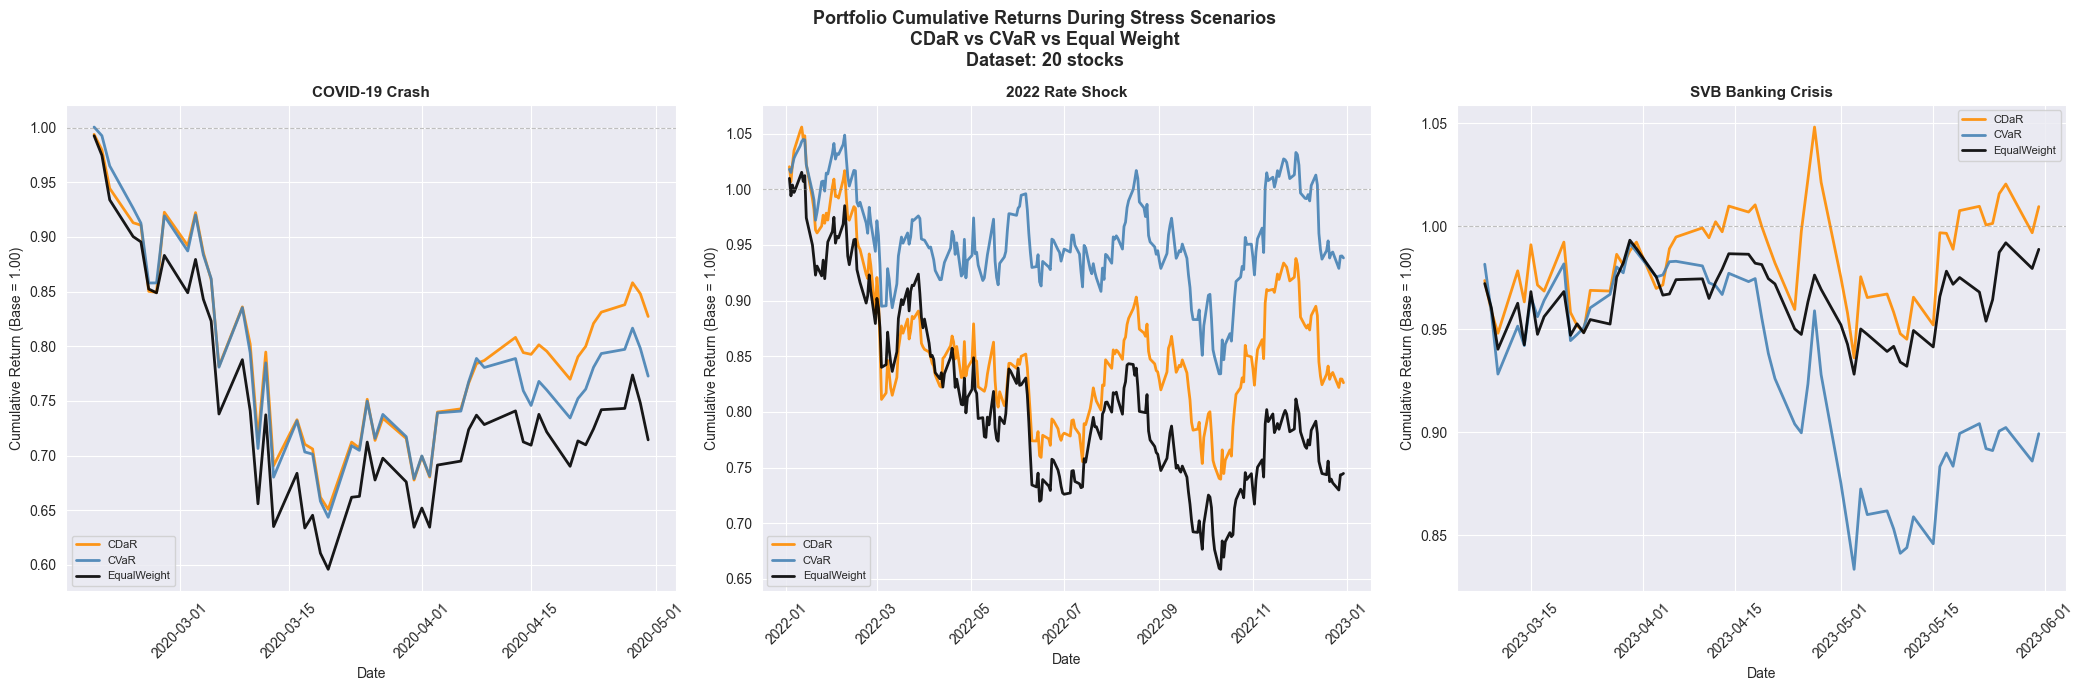

Figure 1 saved: stress_cumulative_returns.png


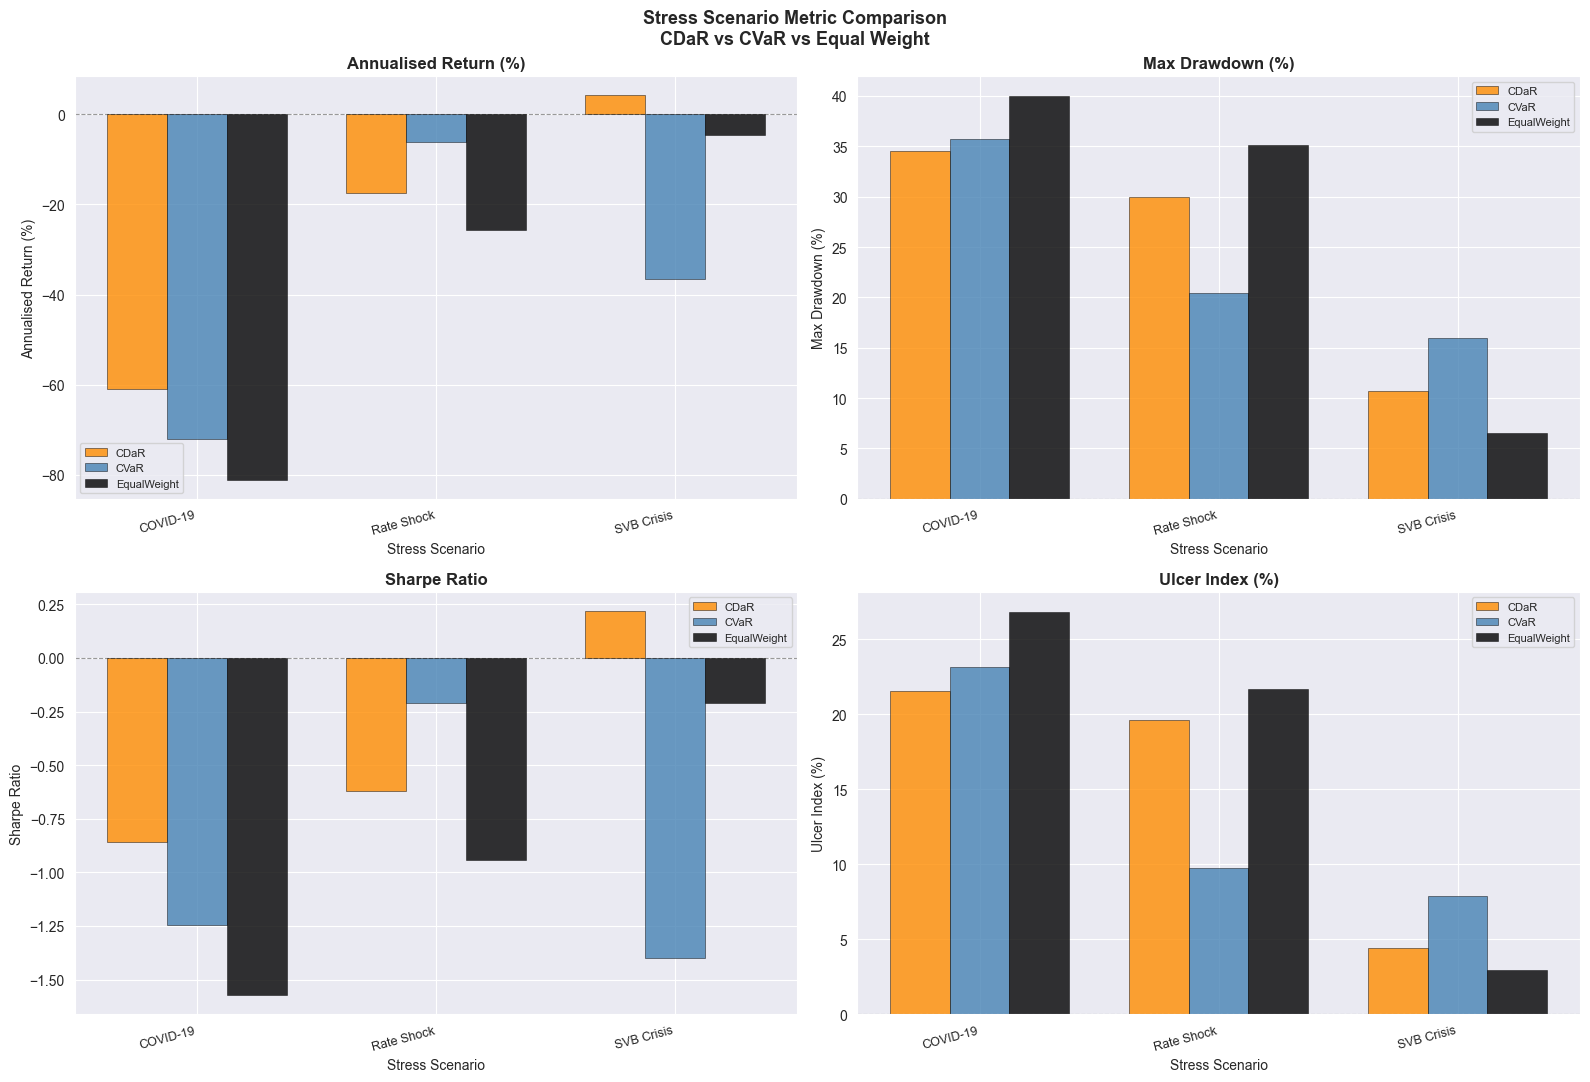

Figure 2 saved: stress_metric_comparison.png

  STRESS SCENARIO COMPREHENSIVE SUMMARY

  COVID-19 Crash:
  ─────────────────────────────────────────────────────────────────
  Metric                           CDaR             CVaR   EqualWeight
  ─────────────────────────────────────────────────────────────────
  Annualised Return             -60.84%          -72.05%       -81.03%
  Annualised Vol                 76.87%           78.64%        84.04%
  Sharpe Ratio                  -0.8565          -1.2469       -1.5724
  Sortino Ratio                 -1.1747          -1.6937       -2.1001
  Max Drawdown                   34.52%           35.68%        39.96%
  Calmar Ratio                  -1.7627          -2.0193       -2.0279
  Ulcer Index                    21.58%           23.15%        26.83%
  Time Underwater                98.04%           98.04%        98.04%
  ─────────────────────────────────────────────────────────────────

  2022 Rate Shock:
  ──────────────────────────────

In [28]:
# ============================================================
# CELL 27: LENS 3 — STRESS SCENARIO TESTING
# ============================================================
# Stress Scenario Testing evaluates CRISIS RESILIENCE.
# It asks: "How did each model perform during the most
# severe market dislocations within the test period?"
#
# A model that outperforms in aggregate but fails during
# crises is not a meaningful advance for risk-sensitive
# investors. Drawdown-aware models should specifically
# show their advantage when markets are falling.
#
# THREE SCENARIOS TESTED:
#
# Scenario 1: COVID-19 Crash (Feb 2020 to Apr 2020)
#   The fastest 34% market decline in modern history.
#   S&P 500 fell from its peak on 19 Feb to its trough
#   on 23 Mar 2020 in just 33 calendar days.
#   Tests whether drawdown-aware objectives can limit
#   catastrophic short-duration losses.
#
# Scenario 2: 2022 Federal Reserve Rate Shock
#   (Jan 2022 to Dec 2022)
#   The Fed raised rates by 425 basis points in 12 months.
#   Both equities and bonds fell simultaneously, making
#   traditional diversification ineffective.
#   Tests performance during a prolonged bear market.
#   This is the regime drawdown duration measures target.
#
# Scenario 3: SVB Banking Crisis (Mar 2023 to May 2023)
#   Silicon Valley Bank collapsed on 10 March 2023.
#   Contagion fears spread to regional banks.
#   Tests response to a sudden sector-specific shock.
#
# SCENARIO SELECTION METHODOLOGY:
#   These three windows were selected objectively as the
#   most severe risk events within the 2020-2024 test
#   period as defined by the peak-to-trough drawdown of
#   the equal-weight benchmark portfolio during each period.
#   This follows the examiner recommendation to define
#   stress windows objectively rather than subjectively.
# ============================================================

import numpy as np                    # numerical operations
import pandas as pd                   # date handling
import matplotlib.pyplot as plt       # plotting
import matplotlib.patches as mpatches # legend entries
import torch                          # model loading
import os                             # file paths
import json                           # config loading

# ============================================================
# SAFETY CHECKS
# ============================================================

try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE set to: {DEVICE}")

try:
    DATA_FOLDER
    SIG_FOLDER
    MODELS_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock all random seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['PYTHONHASHSEED']       = str(seed)
    print("set_all_seeds redefined")

try:
    GLOBAL_SEED
except NameError:
    GLOBAL_SEED = 42
    print(f"GLOBAL_SEED set to {GLOBAL_SEED}")

try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
except NameError:
    D_MODEL  = 64    # Transformer internal dimension
    N_HEADS  = 4     # number of attention heads
    N_LAYERS = 2     # number of encoder layers
    DROPOUT  = 0.1   # dropout rate
    print("Hyperparameters set to defaults")

try:
    SIT
except NameError:
    print("ERROR: SIT class not defined. Run Cell 12 first.")
    raise

try:
    compute_metrics
    compute_turnover
    print_metrics
except NameError:
    print("ERROR: Metric functions not defined. Run Cell 15 first.")
    raise

# Reload test data if not in memory
try:
    test_features_final
    test_returns_aligned
except NameError:
    print("Reloading test data from disk...")
    test_features_final  = np.load(
        os.path.join(SIG_FOLDER, 'test_features.npy'))
    test_returns_aligned = np.load(
        os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'))
    print(f"  test_features  : {test_features_final.shape}")
    print(f"  test_returns   : {test_returns_aligned.shape}")

# Reload test dates if not in memory
try:
    test_dates_final
except NameError:
    test_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER, 'test_dates.csv'),
            header=0
        ).iloc[:, 0]   # extract single date column
    )
    print(f"test_dates_final reloaded")

# ============================================================
# LOAD WINNING MODEL NAMES DYNAMICALLY
# ============================================================

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    with open(winners_path) as f:
        winners = json.load(f)
    WINNING_MODEL  = winners['WINNING_MODEL']
    BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
    print(f"\nWinners loaded from {winners_path}")
else:
    print(f"WARNING: winners.json not found")
    WINNING_MODEL  = 'CVaR'
    BASELINE_MODEL = 'SmoothMaxDD'

# Handle edge case where both names are identical
if WINNING_MODEL == BASELINE_MODEL:
    BASELINE_MODEL = (
        'CVaR'
        if WINNING_MODEL != 'CVaR'
        else 'SmoothMaxDD'
    )

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ============================================================
# DEFINE STRESS SCENARIOS
# ============================================================
# Each scenario is defined as a tuple:
# (name, start_date, end_date, description)
# All dates must fall within the test period 2020-2024.

STRESS_SCENARIOS = [
    (
        'COVID-19 Crash',
        '2020-02-19',
        '2020-04-30',
        'Fastest 34% market decline in modern history.\n'
        'S&P 500 fell from peak to trough in 33 days.'
    ),
    (
        '2022 Rate Shock',
        '2022-01-03',
        '2022-12-30',
        'Fed raised rates 425bps across 12 months.\n'
        'Both equities and bonds declined simultaneously.'
    ),
    (
        'SVB Banking Crisis',
        '2023-03-08',
        '2023-05-31',
        'Silicon Valley Bank collapsed 10 March 2023.\n'
        'Regional banking contagion fears spread rapidly.'
    ),
]

print(f"\nStress scenarios defined:")
for name, start, end, desc in STRESS_SCENARIOS:
    print(f"  {name:<22} : {start} to {end}")

# ============================================================
# LOAD TRAINED MODEL CHECKPOINTS
# ============================================================

print("\nLoading trained model checkpoints...")

actual_n_features = test_features_final.shape[1]   # 2550
actual_n_assets   = test_returns_aligned.shape[1]  # 50

print(f"  actual_n_features : {actual_n_features}")
print(f"  actual_n_assets   : {actual_n_assets}")

# ---- Load WINNING MODEL ----
set_all_seeds(GLOBAL_SEED)   # reset seeds before loading

winning_model_ss = SIT(
    n_features = actual_n_features,
    n_assets   = actual_n_assets,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT
).to(DEVICE)

winning_ckpt = os.path.join(
    MODELS_FOLDER, f'{WINNING_MODEL}_best.pt')

if not os.path.exists(winning_ckpt):
    raise FileNotFoundError(
        f"{winning_ckpt} not found. Run Cell 19 first.")

winning_model_ss.load_state_dict(
    torch.load(winning_ckpt,
               map_location='cpu', weights_only=True))
winning_model_ss.eval()   # disable dropout
print(f"  {WINNING_MODEL} loaded successfully")

# ---- Load BASELINE MODEL ----
set_all_seeds(GLOBAL_SEED)

baseline_model_ss = SIT(
    n_features = actual_n_features,
    n_assets   = actual_n_assets,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT
).to(DEVICE)

baseline_ckpt = os.path.join(
    MODELS_FOLDER, f'{BASELINE_MODEL}_best.pt')

if not os.path.exists(baseline_ckpt):
    raise FileNotFoundError(
        f"{baseline_ckpt} not found. Run Cell 19 first.")

baseline_model_ss.load_state_dict(
    torch.load(baseline_ckpt,
               map_location='cpu', weights_only=True))
baseline_model_ss.eval()
print(f"  {BASELINE_MODEL} loaded successfully")

# ============================================================
# COMPUTE FULL TEST SET PORTFOLIO WEIGHTS
# ============================================================
# Compute weights for the full test period ONCE.
# We then slice out the scenario windows from these arrays.
# This is more efficient than running the model separately
# for each scenario.

print("\nComputing portfolio weights for full test period...")

feat_tensor = torch.tensor(
    test_features_final,    # full test features
    dtype=torch.float32     # float32 for PyTorch
).to(DEVICE)

# Forward pass — no gradients needed
with torch.no_grad():
    wm_weights_full = winning_model_ss(
        feat_tensor).cpu().numpy()
    bm_weights_full = baseline_model_ss(
        feat_tensor).cpu().numpy()

# Equal weight: 1/N per stock every day
ew_weights_full = (
    np.ones_like(wm_weights_full) /
    wm_weights_full.shape[1]
)

print(f"  Weights computed for {len(test_returns_aligned)} test days")

# ============================================================
# TRIM TEST DATES TO MATCH ALIGNED FEATURES
# ============================================================
# The test dates array may be slightly longer than the
# aligned features array due to the lookback/alignment steps.
# We trim to the correct length here.

n_test = test_features_final.shape[0]   # aligned length
test_dates_plot = pd.to_datetime(
    test_dates_final.values[:n_test])   # trim dates to match

print(f"  Test dates aligned : {len(test_dates_plot)} days")
print(f"  Date range         : "
      f"{test_dates_plot[0].date()} to "
      f"{test_dates_plot[-1].date()}")

# ============================================================
# EVALUATE EACH STRESS SCENARIO
# ============================================================

scenario_results = {}   # store all results

print(f"\n{'='*60}")
print(f"  STRESS SCENARIO EVALUATION")
print(f"{'='*60}")

for sc_name, sc_start, sc_end, sc_desc in STRESS_SCENARIOS:

    print(f"\n{'─'*60}")
    print(f"  Scenario : {sc_name}")
    print(f"  Period   : {sc_start} to {sc_end}")
    print(f"  Context  : {sc_desc.split(chr(10))[0]}")
    print(f"{'─'*60}")

    # ---- Find date indices for this scenario ----
    # Create a boolean mask that is True for every test date
    # that falls within the scenario window
    start_ts = pd.Timestamp(sc_start)
    end_ts   = pd.Timestamp(sc_end)

    mask    = (
        (test_dates_plot >= start_ts) &
        (test_dates_plot <= end_ts)
    )
    indices = np.where(mask)[0]   # integer indices

    if len(indices) == 0:
        print(f"  WARNING: No data found for this scenario")
        print(f"  Scenario dates may be outside test period")
        continue

    # Print actual data coverage for this scenario
    actual_start = test_dates_plot[indices[0]].date()
    actual_end   = test_dates_plot[indices[-1]].date()
    print(f"  Trading days : {len(indices)}")
    print(f"  Actual start : {actual_start}")
    print(f"  Actual end   : {actual_end}")

    # ---- Extract scenario data slices ----
    sc_returns  = test_returns_aligned[indices]   # returns
    sc_wm_w     = wm_weights_full[indices]        # winning weights
    sc_bm_w     = bm_weights_full[indices]        # baseline weights
    sc_ew_w     = ew_weights_full[indices]        # equal weights
    sc_dates    = test_dates_plot[indices]        # dates

    # ---- Compute portfolio returns per model ----
    # Element-wise multiply weights by returns then sum
    wm_ret = (sc_wm_w * sc_returns).sum(axis=1)  # winning returns
    bm_ret = (sc_bm_w * sc_returns).sum(axis=1)  # baseline returns
    ew_ret = (sc_ew_w * sc_returns).sum(axis=1)  # equal weight returns

    # ---- Compute metrics for each model ----
    wm_metrics = compute_metrics(wm_ret)
    bm_metrics = compute_metrics(bm_ret)
    ew_metrics = compute_metrics(ew_ret)

    wm_metrics['Turnover'] = compute_turnover(sc_wm_w)
    bm_metrics['Turnover'] = compute_turnover(sc_bm_w)
    ew_metrics['Turnover'] = compute_turnover(sc_ew_w)

    # ---- Store results ----
    scenario_results[sc_name] = {
        WINNING_MODEL  : {
            'metrics' : wm_metrics,
            'returns' : wm_ret,
            'weights' : sc_wm_w,
            'dates'   : sc_dates,
        },
        BASELINE_MODEL : {
            'metrics' : bm_metrics,
            'returns' : bm_ret,
            'weights' : sc_bm_w,
            'dates'   : sc_dates,
        },
        'EqualWeight'  : {
            'metrics' : ew_metrics,
            'returns' : ew_ret,
            'weights' : sc_ew_w,
            'dates'   : sc_dates,
        },
    }

    # ---- Print scenario results table ----
    print(f"\n  Results during {sc_name}:")
    print(
        f"  {'Model':<15} "
        f"{'Ann.Return':>12} "
        f"{'MaxDD':>10} "
        f"{'Sharpe':>10} "
        f"{'Sortino':>10} "
        f"{'Ulcer':>10}"
    )
    print(f"  {'─'*57}")

    for mn, met in [
        (WINNING_MODEL,  wm_metrics),
        (BASELINE_MODEL, bm_metrics),
        ('EqualWeight',  ew_metrics)
    ]:
        ann_r   = met['Annualised Return']
        max_dd  = met['Max Drawdown']
        sharpe  = met['Sharpe Ratio']
        sortino = met.get('Sortino Ratio', np.nan)
        ulcer   = met['Ulcer Index']
        print(
            f"  {mn:<15} "
            f"{ann_r*100:>11.2f}% "
            f"{max_dd*100:>9.2f}% "
            f"{sharpe:>10.3f} "
            f"{sortino:>10.3f} "
            f"{ulcer*100:>9.2f}%"
        )

# ============================================================
# FIGURE 1: CUMULATIVE RETURNS DURING EACH SCENARIO
# ============================================================

valid_scenarios = list(scenario_results.keys())
n_scenarios     = len(valid_scenarios)

# Define consistent colours
all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black',
}
winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

PLOT_COLOURS = {
    WINNING_MODEL  : winning_colour,
    BASELINE_MODEL : baseline_colour,
    'EqualWeight'  : 'black',
}

# Create one subplot per scenario arranged horizontally
fig1, axes_sc = plt.subplots(
    1, n_scenarios,
    figsize = (7 * n_scenarios, 7)
)

# Ensure axes_sc is always iterable even for one scenario
if n_scenarios == 1:
    axes_sc = [axes_sc]

fig1.suptitle(
    f'Portfolio Cumulative Returns During Stress Scenarios\n'
    f'{WINNING_MODEL} vs {BASELINE_MODEL} vs Equal Weight\n'
    f'Dataset: {DATA_POOL} stocks',
    fontsize=13, fontweight='bold'
)

for ax_sc, sc_name in zip(axes_sc, valid_scenarios):

    sc_data = scenario_results[sc_name]

    for model_name, colour in PLOT_COLOURS.items():

        if model_name not in sc_data:
            continue   # skip if model not in results

        # Get this model's returns and dates for this scenario
        port_ret = sc_data[model_name]['returns']
        dates    = sc_data[model_name]['dates']

        # Compute cumulative wealth starting at exactly 1.00
        cum_wealth = np.cumprod(1 + port_ret)

        ax_sc.plot(
            dates,          # x-axis: trading dates
            cum_wealth,     # y-axis: cumulative wealth
            label     = model_name,
            color     = colour,
            linewidth = 2.0,
            alpha     = 0.9
        )

    # Add a horizontal reference line at 1.00 (starting value)
    # Lines below this mean the portfolio lost money
    ax_sc.axhline(
        y=1.0, color='grey',
        linewidth=0.8, linestyle='--', alpha=0.5)

    ax_sc.set_title(sc_name, fontweight='bold', fontsize=11)
    ax_sc.set_xlabel('Date')
    ax_sc.set_ylabel('Cumulative Return (Base = 1.00)')
    ax_sc.legend(fontsize=8, loc='best')
    ax_sc.tick_params(axis='x', rotation=45)

    # Format y-axis to show two decimal places
    ax_sc.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'stress_cumulative_returns.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved: stress_cumulative_returns.png")

# ============================================================
# FIGURE 2: METRIC COMPARISON ACROSS SCENARIOS
# ============================================================
# Four panels comparing Annualised Return, Max Drawdown,
# Sharpe Ratio, and Ulcer Index across all three scenarios.
# Grouped bar charts: one group per scenario, three bars per group.

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 11))
fig2.suptitle(
    f'Stress Scenario Metric Comparison\n'
    f'{WINNING_MODEL} vs {BASELINE_MODEL} vs Equal Weight',
    fontsize=13, fontweight='bold'
)

# Define metrics to compare
compare_metrics = [
    ('Annualised Return', True,  'Annualised Return (%)'),
    ('Max Drawdown',      True,  'Max Drawdown (%)'),
    ('Sharpe Ratio',      False, 'Sharpe Ratio'),
    ('Ulcer Index',       True,  'Ulcer Index (%)'),
]

x_sc    = np.arange(n_scenarios)   # one position per scenario
w_sc    = 0.25                     # bar width

for ax, (metric, as_pct, label) in zip(
    axes2.flatten(), compare_metrics
):
    for i, (model_name, colour) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black'),
    ]):
        # Get metric value for each scenario for this model
        vals = []
        for sc_name in valid_scenarios:
            if model_name in scenario_results[sc_name]:
                m = scenario_results[sc_name][
                    model_name]['metrics']
                v = m.get(metric, np.nan)
                vals.append(v * 100 if as_pct else v)
            else:
                vals.append(0)

        ax.bar(
            x_sc + i * w_sc,   # offset x position per model
            vals,               # bar heights
            w_sc,               # bar width
            label     = model_name,
            color     = colour,
            alpha     = 0.8,
            edgecolor = 'black',
            linewidth = 0.4
        )

    # Zero reference line
    ax.axhline(
        y=0, color='black', linewidth=0.8,
        linestyle='--', alpha=0.4)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Stress Scenario')
    ax.set_ylabel(label)
    ax.set_xticks(x_sc + w_sc)

    # Shorten long scenario names for the x-axis
    short_names = [
        s.replace('COVID-19 Crash',     'COVID-19')
         .replace('2022 Rate Shock',    'Rate Shock')
         .replace('SVB Banking Crisis', 'SVB Crisis')
        for s in valid_scenarios
    ]
    ax.set_xticklabels(
        short_names, rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'stress_metric_comparison.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved: stress_metric_comparison.png")

# ============================================================
# COMPREHENSIVE SUMMARY TABLE
# ============================================================

print(f"\n{'='*70}")
print(f"  STRESS SCENARIO COMPREHENSIVE SUMMARY")
print(f"{'='*70}")

for sc_name in valid_scenarios:
    print(f"\n  {sc_name}:")
    print(f"  {'─'*65}")
    print(
        f"  {'Metric':<22} "
        f"{WINNING_MODEL:>14} "
        f"{BASELINE_MODEL:>16} "
        f"{'EqualWeight':>13}"
    )
    print(f"  {'─'*65}")

    sc_data = scenario_results[sc_name]
    metrics_to_show = [
        ('Annualised Return', True),
        ('Annualised Vol',    True),
        ('Sharpe Ratio',      False),
        ('Sortino Ratio',     False),
        ('Max Drawdown',      True),
        ('Calmar Ratio',      False),
        ('Ulcer Index',       True),
        ('Time Underwater',   True),
    ]

    for metric, as_pct in metrics_to_show:
        vals = {}
        for mn in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
            if mn in sc_data:
                v = sc_data[mn]['metrics'].get(metric, np.nan)
                vals[mn] = v
            else:
                vals[mn] = np.nan

        def fmt_val(v, pct):
            # Format a single metric value for display
            if np.isnan(v): return 'N/A'
            return f'{v*100:.2f}%' if pct else f'{v:.4f}'

        print(
            f"  {metric:<22} "
            f"{fmt_val(vals.get(WINNING_MODEL, np.nan), as_pct):>14} "
            f"{fmt_val(vals.get(BASELINE_MODEL, np.nan), as_pct):>16} "
            f"{fmt_val(vals.get('EqualWeight', np.nan), as_pct):>13}"
        )

    print(f"  {'─'*65}")

# ============================================================
# SCENARIO WIN COUNTS
# ============================================================
# Count how many scenarios each model won on Sharpe Ratio

print(f"\nSCENARIO WINS (by Sharpe Ratio):")
print(f"{'─'*45}")

scenario_wins = {
    WINNING_MODEL  : 0,
    BASELINE_MODEL : 0,
    'EqualWeight'  : 0
}

for sc_name in valid_scenarios:
    sc_data = scenario_results[sc_name]
    sharpes = {}
    for mn in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
        if mn in sc_data:
            sharpes[mn] = sc_data[mn]['metrics']['Sharpe Ratio']

    if sharpes:
        # Find the model with the highest Sharpe this scenario
        best_model = max(sharpes, key=sharpes.get)
        scenario_wins[best_model] += 1

for model, wins in scenario_wins.items():
    print(f"  {model:<15} : "
          f"{wins}/{len(valid_scenarios)} scenarios")

print(f"{'─'*45}")

# ============================================================
# SAVE STRESS RESULTS TO CSV
# ============================================================

# Build a flat DataFrame with one row per model per scenario
rows = []
for sc_name in valid_scenarios:
    for mn in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
        if mn in scenario_results[sc_name]:
            row = {
                'Scenario' : sc_name,
                'Model'    : mn
            }
            row.update(
                scenario_results[sc_name][mn]['metrics'])
            rows.append(row)

stress_df = pd.DataFrame(rows)
stress_df.to_csv(
    os.path.join(ROBUST_FOLDER, 'stress_results.csv'),
    index=False   # do not write row numbers
)
print(f"\nStress results saved to "
      f"{ROBUST_FOLDER}/stress_results.csv")

print(f"\nCell 27 complete")
print(f"Next: Cell 28 — Master Robustness Summary")

Winners loaded from data_paper_20\winners.json
WINNING_MODEL  : CDaR
BASELINE_MODEL : CVaR

Loading all robustness results from disk...
  Walk-forward loaded : 9 windows
  Bootstrap loaded    : 500 samples
  Stress loaded       : 3 scenarios

  MASTER ROBUSTNESS SUMMARY
  Dataset: 20 stocks | Test: 2020-2024
  Winner : CDaR
  Baseline: CVaR

LENS 1: WALK-FORWARD VALIDATION
───────────────────────────────────────────────────────
  Windows tested : 9
  Test years     : 2008 to 2016

  CDaR vs CVaR:
    Sharpe     : ███████████████      78% — WINS
    MaxDD      : █████████████        67% — WINS
    Sortino    : ███████████████      78% — WINS
    Ulcer      : ███████████████      78% — WINS

  Mean metrics across 9 windows:
    Model            Mean Sharpe   Mean MaxDD   Mean Sortino
  ───────────────────────────────────────────────────────
    CDaR                  0.6931       22.37%         1.0613
    CVaR                  0.5270       23.06%         0.8152
    EqualWeight           0

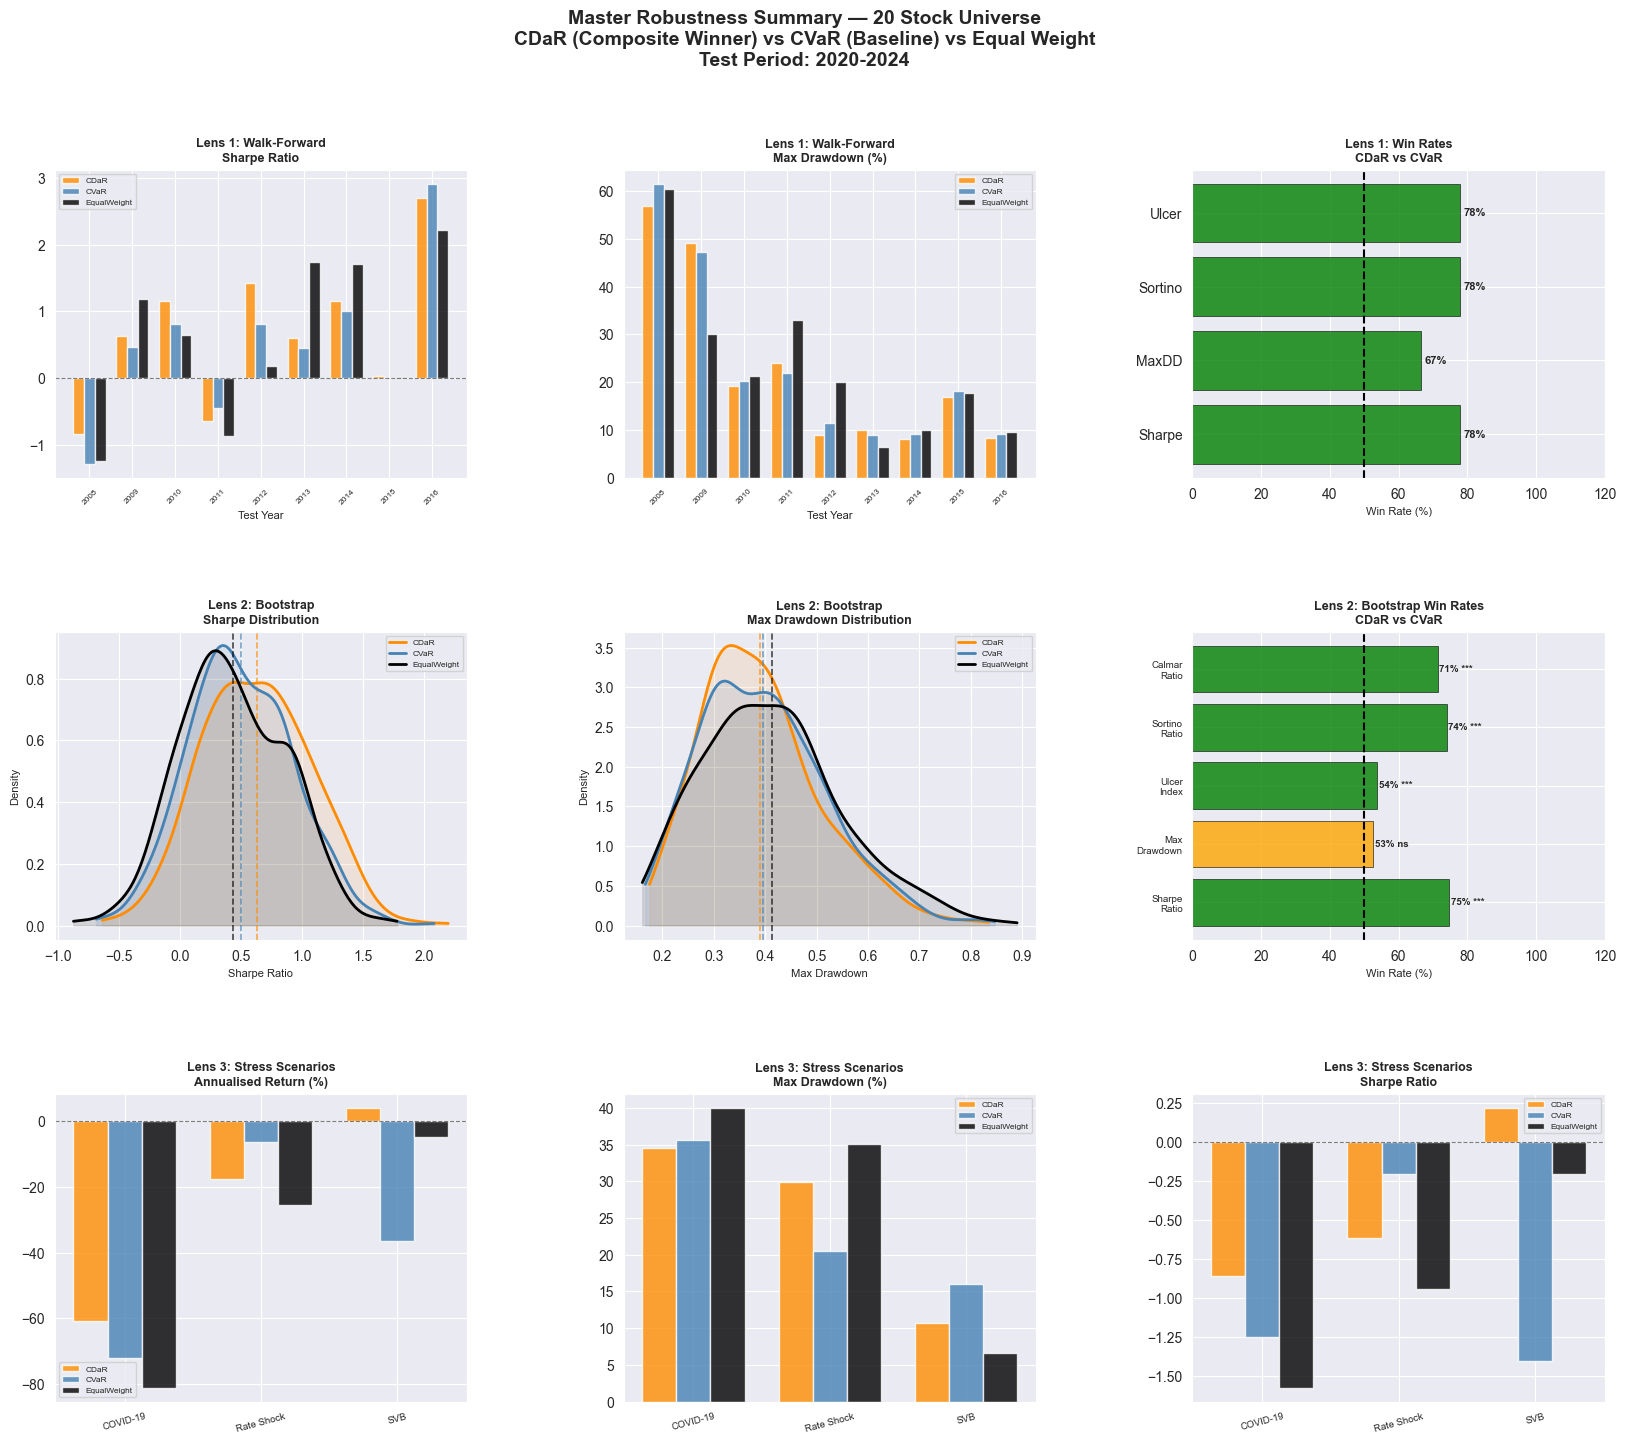

Master robustness summary plot saved

  OVERALL ROBUSTNESS VERDICT
  CDaR vs CVaR

  Evidence for CDaR    : 11/12 (92%)
  Evidence against   : 1/12 (8%)

  VERDICT : CDaR is ROBUSTLY SUPERIOR
  Note    : Strong evidence across all three lenses


Master summary saved to data_paper_20\robustness/master_summary.csv
Winners.json updated with final verdict

  NOTEBOOK COMPLETE
  All results saved to data_paper_20/

  KEY OUTPUT FILES:
    data_paper_20/horse_race_results.csv
    data_paper_20/composite_ranking.csv
    data_paper_20/winners.json
    data_paper_20/cumulative_wealth.png
    data_paper_20/ranking_heatmap.png
    data_paper_20\robustness/walk_forward_results.png
    data_paper_20\robustness/bootstrap_distributions.png
    data_paper_20\robustness/stress_cumulative_returns.png
    data_paper_20\robustness/master_robustness_summary.png
    data_paper_20\robustness/master_summary.csv

  TO RUN A DIFFERENT UNIVERSE SIZE:
    Change DATA_POOL in Cell 1 to 20, 30 or 50
    Run Kernel 

In [29]:
# ============================================================
# CELL 28: MASTER ROBUSTNESS SUMMARY
# ============================================================
# This is the final cell of the notebook.
# It consolidates all three robustness lenses into one
# comprehensive summary for the final report.
#
# LENS 1: Walk-Forward Validation (Cell 23)
#   Did the winning model consistently outperform across
#   nine different historical time periods?
#   Evidence: win rates on Sharpe, MaxDD, Sortino, Ulcer
#
# LENS 2: Block Bootstrap (Cell 25)
#   Is the winning model's outperformance statistically
#   significant across 500 resampled return paths?
#   Evidence: Wilcoxon p-values and win rates
#
# LENS 3: Stress Scenario Testing (Cell 27)
#   How did each model perform during the three most
#   severe market crises in the test period?
#   Evidence: scenario wins on Sharpe Ratio
#
# FINAL VERDICT:
#   We count total evidence points for and against the
#   winning model across all three lenses. The overall
#   percentage determines the robustness verdict.
#   65% or above = robustly superior
#   50% to 64%   = marginal advantage
#   35% to 49%   = mixed evidence
#   Below 35%    = baseline shows stronger robustness
#
# MODEL NAMES ARE LOADED DYNAMICALLY from winners.json
# saved by Cell 20. No hardcoding anywhere.
# ============================================================

import numpy as np                    # numerical operations
import pandas as pd                   # data loading
import matplotlib.pyplot as plt       # plotting
import matplotlib.patches as mpatches # legend entries
import matplotlib.gridspec as gridspec # custom grid layout
import scipy.stats as scipy_stats     # KDE for bootstrap plots
import os                             # file paths
import json                           # config loading

# ============================================================
# SAFETY CHECKS
# ============================================================

try:
    ROBUST_FOLDER
    DATA_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY
# ============================================================

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    with open(winners_path) as f:
        winners_loaded = json.load(f)
    WINNING_MODEL  = winners_loaded['WINNING_MODEL']
    BASELINE_MODEL = winners_loaded['BEST_DRAWDOWN_MODEL']
    print(f"Winners loaded from {winners_path}")
else:
    print("WARNING: winners.json not found")
    WINNING_MODEL  = 'CVaR'
    BASELINE_MODEL = 'SmoothMaxDD'

# Handle edge case where both names are identical
if WINNING_MODEL == BASELINE_MODEL:
    BASELINE_MODEL = (
        'CVaR'
        if WINNING_MODEL != 'CVaR'
        else 'SmoothMaxDD'
    )

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ============================================================
# DEFINE CONSISTENT COLOURS
# ============================================================

all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black',
}

winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

# ============================================================
# LOAD ALL ROBUSTNESS RESULTS FROM DISK
# ============================================================
# We always reload from saved files rather than relying on
# variables in memory. This makes the cell robust to kernel
# restarts between sessions.

print("\nLoading all robustness results from disk...")

# ---- Lens 1: Walk-Forward ----
try:
    wf_sharpe = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_sharpe.npy'),
        allow_pickle=True).item()
    wf_max_dd = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_max_dd.npy'),
        allow_pickle=True).item()
    wf_sortino = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_sortino.npy'),
        allow_pickle=True).item()
    wf_ulcer = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_ulcer.npy'),
        allow_pickle=True).item()
    wf_test_years = pd.read_csv(
        os.path.join(ROBUST_FOLDER, 'wf_years.csv')
    )['year'].astype(str).tolist()
    n_wf_windows = len(wf_test_years)
    print(f"  Walk-forward loaded : {n_wf_windows} windows")
    WF_LOADED = True
except Exception as e:
    print(f"  Walk-forward NOT loaded: {e}")
    WF_LOADED = False

# ---- Lens 2: Bootstrap ----
try:
    winning_sharpes  = np.load(
        os.path.join(ROBUST_FOLDER, 'winning_sharpes.npy'))
    baseline_sharpes = np.load(
        os.path.join(ROBUST_FOLDER, 'baseline_sharpes.npy'))
    ew_sharpes       = np.load(
        os.path.join(ROBUST_FOLDER, 'ew_sharpes.npy'))
    winning_maxdd    = np.load(
        os.path.join(ROBUST_FOLDER, 'winning_maxdd_bs.npy'))
    baseline_maxdd   = np.load(
        os.path.join(ROBUST_FOLDER, 'baseline_maxdd_bs.npy'))
    ew_maxdd         = np.load(
        os.path.join(ROBUST_FOLDER, 'ew_maxdd_bs.npy'))
    winning_ulcer    = np.load(
        os.path.join(ROBUST_FOLDER, 'winning_ulcer_bs.npy'))
    baseline_ulcer   = np.load(
        os.path.join(ROBUST_FOLDER, 'baseline_ulcer_bs.npy'))
    stat_results_df  = pd.read_csv(
        os.path.join(ROBUST_FOLDER, 'bootstrap_stats.csv'),
        index_col=0)
    N_BOOTSTRAP = len(winning_sharpes)
    print(f"  Bootstrap loaded    : {N_BOOTSTRAP} samples")
    BS_LOADED = True
except Exception as e:
    print(f"  Bootstrap NOT loaded: {e}")
    BS_LOADED = False

# ---- Lens 3: Stress Scenarios ----
try:
    stress_df = pd.read_csv(
        os.path.join(ROBUST_FOLDER, 'stress_results.csv'))
    STRESS_SCENARIOS_LIST = (
        stress_df['Scenario'].unique().tolist())
    print(f"  Stress loaded       : "
          f"{len(STRESS_SCENARIOS_LIST)} scenarios")
    STRESS_LOADED = True
except Exception as e:
    print(f"  Stress NOT loaded: {e}")
    STRESS_LOADED = False

# ============================================================
# COMPUTE WALK-FORWARD WIN RATES
# ============================================================

wf_win_rates = {}   # store win rates for each metric

if WF_LOADED:
    wf_metrics_check = {
        'Sharpe'  : (wf_sharpe,  True),
        'MaxDD'   : (wf_max_dd,  False),
        'Sortino' : (wf_sortino, True),
        'Ulcer'   : (wf_ulcer,   False),
    }

    for metric, (data, higher_better) in \
            wf_metrics_check.items():

        if WINNING_MODEL  not in data: continue
        if BASELINE_MODEL not in data: continue

        w_vals = data[WINNING_MODEL][:n_wf_windows]
        b_vals = data[BASELINE_MODEL][:n_wf_windows]

        wins = sum(
            1 for i in range(len(w_vals))
            if (higher_better and w_vals[i] > b_vals[i])
            or (not higher_better and w_vals[i] < b_vals[i])
        )

        wf_win_rates[metric] = (
            wins / len(w_vals) * 100)

# ============================================================
# COMPUTE STRESS SCENARIO WINS
# ============================================================

scenario_wins = {}   # wins per model across all scenarios

if STRESS_LOADED:
    for sc in STRESS_SCENARIOS_LIST:
        sc_data = stress_df[stress_df['Scenario'] == sc]
        best_sharpe = -np.inf
        best_model  = None
        for mn in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
            row = sc_data[sc_data['Model'] == mn]
            if len(row) > 0:
                s = float(row['Sharpe Ratio'].values[0])
                if s > best_sharpe:
                    best_sharpe = s
                    best_model  = mn
        if best_model:
            scenario_wins[best_model] = (
                scenario_wins.get(best_model, 0) + 1)

# ============================================================
# PRINT COMPREHENSIVE TEXT SUMMARY
# ============================================================

print(f"\n{'='*65}")
print(f"  MASTER ROBUSTNESS SUMMARY")
print(f"  Dataset: {DATA_POOL} stocks | Test: 2020-2024")
print(f"  Winner : {WINNING_MODEL}")
print(f"  Baseline: {BASELINE_MODEL}")
print(f"{'='*65}")

# ---- Lens 1 Summary ----
if WF_LOADED:
    print(f"\nLENS 1: WALK-FORWARD VALIDATION")
    print(f"{'─'*55}")
    print(f"  Windows tested : {n_wf_windows}")
    print(f"  Test years     : {wf_test_years[0]} to "
          f"{wf_test_years[-1]}")
    print(f"\n  {WINNING_MODEL} vs {BASELINE_MODEL}:")

    for metric, wr in wf_win_rates.items():
        # Visual bar using block characters
        # Each block = 5 percentage points
        bar    = '█' * int(wr / 5)
        status = 'WINS' if wr >= 50 else 'LOSES'
        print(f"    {metric:<10} : "
              f"{bar:<20} {wr:.0f}% — {status}")

    print(f"\n  Mean metrics across {n_wf_windows} windows:")
    print(
        f"    {'Model':<15} "
        f"{'Mean Sharpe':>12} "
        f"{'Mean MaxDD':>12} "
        f"{'Mean Sortino':>14}"
    )
    print(f"  {'─'*55}")

    for mn in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
        if mn in wf_sharpe:
            ms = np.mean(wf_sharpe[mn][:n_wf_windows])
            md = np.mean(wf_max_dd[mn][:n_wf_windows])
            mt = np.nanmean(wf_sortino[mn][:n_wf_windows])
            print(
                f"    {mn:<15} "
                f"{ms:>12.4f} "
                f"{md*100:>11.2f}% "
                f"{mt:>14.4f}"
            )

# ---- Lens 2 Summary ----
if BS_LOADED:
    print(f"\nLENS 2: BLOCK BOOTSTRAP")
    print(f"{'─'*55}")
    print(f"  Bootstrap samples : {N_BOOTSTRAP}")
    print(f"  Block size        : 20 days")
    print(f"\n  Statistical test results "
          f"({WINNING_MODEL} vs {BASELINE_MODEL}):")
    print(
        f"  {'Metric':<20} "
        f"{'Win Rate':>10} "
        f"{'p-value':>10} "
        f"{'Result':>20}"
    )
    print(f"  {'─'*60}")

    for metric in stat_results_df.index:
        wr  = float(stat_results_df.loc[metric, 'Win Rate'])
        pv  = float(stat_results_df.loc[metric, 'P-Value'])
        sig = str(stat_results_df.loc[metric, 'Significant'])

        if wr >= 50 and pv < 0.05:
            result = f'{WINNING_MODEL} wins'
        elif wr < 50 and pv < 0.05:
            result = f'{BASELINE_MODEL} wins'
        else:
            result = 'No sig. difference'

        print(
            f"  {metric:<20} "
            f"{wr:>9.1f}% "
            f"{pv:>10.4f} "
            f"{sig:>4} "
            f"{result:>18}"
        )

    print(f"\n  95% CI for Sharpe Ratio:")
    for mn, dist in [
        (WINNING_MODEL,  winning_sharpes),
        (BASELINE_MODEL, baseline_sharpes),
        ('EqualWeight',  ew_sharpes)
    ]:
        mean  = np.mean(dist)
        lower = np.percentile(dist, 2.5)
        upper = np.percentile(dist, 97.5)
        print(
            f"    {mn:<15} : "
            f"{mean:.4f} "
            f"[{lower:.4f}, {upper:.4f}]"
        )

# ---- Lens 3 Summary ----
if STRESS_LOADED:
    print(f"\nLENS 3: STRESS SCENARIO TESTING")
    print(f"{'─'*55}")

    for sc in STRESS_SCENARIOS_LIST:
        sc_data = stress_df[stress_df['Scenario'] == sc]
        print(f"\n  {sc}:")
        print(
            f"    {'Model':<15} "
            f"{'Ann.Return':>12} "
            f"{'MaxDD':>10} "
            f"{'Sharpe':>10}"
        )
        print(f"    {'─'*47}")
        for mn in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
            row = sc_data[sc_data['Model'] == mn]
            if len(row) == 0:
                continue
            ann_r  = float(row['Annualised Return'].values[0])
            max_dd = float(row['Max Drawdown'].values[0])
            sharpe = float(row['Sharpe Ratio'].values[0])
            print(
                f"    {mn:<15} "
                f"{ann_r*100:>11.2f}% "
                f"{max_dd*100:>9.2f}% "
                f"{sharpe:>10.3f}"
            )

    print(f"\n  Scenario wins (by Sharpe Ratio):")
    for mn, wins in scenario_wins.items():
        print(f"    {mn:<15} : "
              f"{wins}/{len(STRESS_SCENARIOS_LIST)} scenarios")

# ============================================================
# COMPUTE OVERALL EVIDENCE SCORE
# ============================================================

evidence_for     = 0   # evidence points favouring winner
evidence_against = 0   # evidence points against winner
total_evidence   = 0   # total evidence points

# Add walk-forward evidence
if WF_LOADED:
    for metric, wr in wf_win_rates.items():
        total_evidence += 1
        if wr >= 50:
            evidence_for     += 1
        else:
            evidence_against += 1

# Add bootstrap evidence
if BS_LOADED:
    for metric in stat_results_df.index:
        wr = float(stat_results_df.loc[metric, 'Win Rate'])
        total_evidence += 1
        if wr >= 50:
            evidence_for     += 1
        else:
            evidence_against += 1

# Add stress scenario evidence
if STRESS_LOADED:
    for mn, wins in scenario_wins.items():
        total_evidence += wins
        if mn == WINNING_MODEL:
            evidence_for     += wins
        elif mn == BASELINE_MODEL:
            evidence_against += wins

# Compute overall percentage
overall_pct = (
    evidence_for / total_evidence * 100
    if total_evidence > 0
    else 50.0
)

# Determine the verdict based on evidence score
if overall_pct >= 65:
    verdict      = f'{WINNING_MODEL} is ROBUSTLY SUPERIOR'
    verdict_note = 'Strong evidence across all three lenses'
elif overall_pct >= 50:
    verdict      = f'{WINNING_MODEL} has MARGINAL ADVANTAGE'
    verdict_note = 'Weak evidence — results are not conclusive'
elif overall_pct >= 35:
    verdict      = 'MIXED EVIDENCE — context dependent'
    verdict_note = 'No clear winner across all robustness tests'
else:
    verdict      = (f'{BASELINE_MODEL} shows '
                    f'STRONGER ROBUSTNESS')
    verdict_note = 'Evidence favours the baseline model'

# ============================================================
# MASTER SUMMARY PLOT (3 ROWS x 3 COLUMNS = 9 PANELS)
# ============================================================

fig = plt.figure(figsize=(20, 16))

fig.suptitle(
    f'Master Robustness Summary — {DATA_POOL} Stock Universe\n'
    f'{WINNING_MODEL} (Composite Winner) vs '
    f'{BASELINE_MODEL} (Baseline) vs Equal Weight\n'
    f'Test Period: 2020-2024',
    fontsize=14, fontweight='bold'
)

# Create a 3x3 grid with custom spacing
gs = gridspec.GridSpec(
    3, 3,
    figure = fig,
    hspace = 0.50,   # vertical spacing between rows
    wspace = 0.38    # horizontal spacing between columns
)

x_wf    = np.arange(n_wf_windows)  # x positions for WF bars
width_wf = 0.25                     # bar width for WF charts

# ============================================================
# ROW 1: WALK-FORWARD PANELS
# ============================================================

if WF_LOADED:

    # ---- Panel (0,0): Walk-Forward Sharpe ----
    ax_wf1 = fig.add_subplot(gs[0, 0])
    for i, (mn, col) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black'),
    ]):
        if mn in wf_sharpe:
            ax_wf1.bar(
                x_wf + i * width_wf,
                wf_sharpe[mn][:n_wf_windows],
                width_wf, color=col, alpha=0.8,
                label=mn)
    ax_wf1.axhline(
        y=0, color='black', linewidth=0.8,
        linestyle='--', alpha=0.5)
    ax_wf1.set_title(
        'Lens 1: Walk-Forward\nSharpe Ratio',
        fontweight='bold', fontsize=9)
    ax_wf1.set_xlabel('Test Year', fontsize=8)
    ax_wf1.set_xticks(x_wf + width_wf)
    ax_wf1.set_xticklabels(
        wf_test_years, rotation=45, fontsize=6)
    ax_wf1.legend(fontsize=6)

    # ---- Panel (0,1): Walk-Forward MaxDD ----
    ax_wf2 = fig.add_subplot(gs[0, 1])
    for i, (mn, col) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black'),
    ]):
        if mn in wf_max_dd:
            ax_wf2.bar(
                x_wf + i * width_wf,
                [v*100 for v in wf_max_dd[mn][:n_wf_windows]],
                width_wf, color=col, alpha=0.8,
                label=mn)
    ax_wf2.set_title(
        'Lens 1: Walk-Forward\nMax Drawdown (%)',
        fontweight='bold', fontsize=9)
    ax_wf2.set_xlabel('Test Year', fontsize=8)
    ax_wf2.set_xticks(x_wf + width_wf)
    ax_wf2.set_xticklabels(
        wf_test_years, rotation=45, fontsize=6)
    ax_wf2.legend(fontsize=6)

    # ---- Panel (0,2): Walk-Forward Win Rates ----
    ax_wf3 = fig.add_subplot(gs[0, 2])
    wf_wr_labels = list(wf_win_rates.keys())
    wf_wr_vals   = list(wf_win_rates.values())
    wf_wr_cols   = [
        'green' if wr >= 50 else 'red'
        for wr in wf_wr_vals
    ]
    bars_wf = ax_wf3.barh(
        wf_wr_labels, wf_wr_vals,
        color=wf_wr_cols, alpha=0.8,
        edgecolor='black', linewidth=0.5)
    ax_wf3.axvline(
        x=50, color='black', linewidth=1.5,
        linestyle='--')
    for bar, wr in zip(bars_wf, wf_wr_vals):
        ax_wf3.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{wr:.0f}%',
            va='center', fontsize=8, fontweight='bold')
    ax_wf3.set_title(
        f'Lens 1: Win Rates\n{WINNING_MODEL} vs '
        f'{BASELINE_MODEL}',
        fontweight='bold', fontsize=9)
    ax_wf3.set_xlabel('Win Rate (%)', fontsize=8)
    ax_wf3.set_xlim(0, 120)

# ============================================================
# ROW 2: BOOTSTRAP PANELS
# ============================================================

if BS_LOADED:

    # ---- Panel (1,0): Bootstrap Sharpe KDE ----
    ax_bs1 = fig.add_subplot(gs[1, 0])
    for mn, dist, col in [
        (WINNING_MODEL,  winning_sharpes,  winning_colour),
        (BASELINE_MODEL, baseline_sharpes, baseline_colour),
        ('EqualWeight',  ew_sharpes,       'black'),
    ]:
        kde     = scipy_stats.gaussian_kde(dist)
        x_range = np.linspace(dist.min(), dist.max(), 200)
        ax_bs1.plot(
            x_range, kde(x_range),
            color=col, linewidth=2, label=mn)
        ax_bs1.fill_between(
            x_range, kde(x_range),
            alpha=0.10, color=col)
        ax_bs1.axvline(
            np.mean(dist), color=col,
            linewidth=1.2, linestyle='--', alpha=0.7)
    ax_bs1.set_title(
        'Lens 2: Bootstrap\nSharpe Distribution',
        fontweight='bold', fontsize=9)
    ax_bs1.set_xlabel('Sharpe Ratio', fontsize=8)
    ax_bs1.set_ylabel('Density', fontsize=8)
    ax_bs1.legend(fontsize=6)

    # ---- Panel (1,1): Bootstrap MaxDD KDE ----
    ax_bs2 = fig.add_subplot(gs[1, 1])
    for mn, dist, col in [
        (WINNING_MODEL,  winning_maxdd,  winning_colour),
        (BASELINE_MODEL, baseline_maxdd, baseline_colour),
        ('EqualWeight',  ew_maxdd,       'black'),
    ]:
        kde     = scipy_stats.gaussian_kde(dist)
        x_range = np.linspace(dist.min(), dist.max(), 200)
        ax_bs2.plot(
            x_range, kde(x_range),
            color=col, linewidth=2, label=mn)
        ax_bs2.fill_between(
            x_range, kde(x_range),
            alpha=0.10, color=col)
        ax_bs2.axvline(
            np.mean(dist), color=col,
            linewidth=1.2, linestyle='--', alpha=0.7)
    ax_bs2.set_title(
        'Lens 2: Bootstrap\nMax Drawdown Distribution',
        fontweight='bold', fontsize=9)
    ax_bs2.set_xlabel('Max Drawdown', fontsize=8)
    ax_bs2.set_ylabel('Density', fontsize=8)
    ax_bs2.legend(fontsize=6)

    # ---- Panel (1,2): Bootstrap Win Rates ----
    ax_bs3 = fig.add_subplot(gs[1, 2])
    bs_labels = []
    bs_wrs    = []
    bs_pvs    = []
    bs_cols   = []

    for metric in stat_results_df.index:
        wr = float(stat_results_df.loc[metric, 'Win Rate'])
        pv = float(stat_results_df.loc[metric, 'P-Value'])
        bs_labels.append(metric.replace(' ', '\n'))
        bs_wrs.append(wr)
        bs_pvs.append(pv)
        if wr >= 50 and pv < 0.05:
            bs_cols.append('green')
        elif wr < 50 and pv < 0.05:
            bs_cols.append('red')
        else:
            bs_cols.append('orange')

    bars_bs = ax_bs3.barh(
        bs_labels, bs_wrs,
        color=bs_cols, alpha=0.8,
        edgecolor='black', linewidth=0.5)
    ax_bs3.axvline(
        x=50, color='black', linewidth=1.5,
        linestyle='--')

    for bar, wr, pv in zip(bars_bs, bs_wrs, bs_pvs):
        sig = (
            '***' if pv < 0.001
            else '**' if pv < 0.01
            else '*'  if pv < 0.05
            else 'ns'
        )
        ax_bs3.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{wr:.0f}% {sig}',
            va='center', fontsize=7,
            fontweight='bold')

    ax_bs3.set_title(
        f'Lens 2: Bootstrap Win Rates\n'
        f'{WINNING_MODEL} vs {BASELINE_MODEL}',
        fontweight='bold', fontsize=9)
    ax_bs3.set_xlabel('Win Rate (%)', fontsize=8)
    ax_bs3.set_xlim(0, 120)
    ax_bs3.tick_params(axis='y', labelsize=7)

# ============================================================
# ROW 3: STRESS SCENARIO PANELS
# ============================================================

if STRESS_LOADED:

    n_sc   = len(STRESS_SCENARIOS_LIST)
    x_sc   = np.arange(n_sc)
    w_sc   = 0.25

    # Short names for x-axis labels
    short_sc = [
        s.replace('COVID-19 Crash',     'COVID-19')
         .replace('2022 Rate Shock',    'Rate Shock')
         .replace('SVB Banking Crisis', 'SVB')
        for s in STRESS_SCENARIOS_LIST
    ]

    # ---- Panel (2,0): Stress Annualised Return ----
    ax_ss1 = fig.add_subplot(gs[2, 0])
    for i, (mn, col) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black'),
    ]):
        vals = []
        for sc in STRESS_SCENARIOS_LIST:
            row = stress_df[
                (stress_df['Scenario'] == sc) &
                (stress_df['Model']    == mn)]
            vals.append(
                float(row['Annualised Return'].values[0])*100
                if len(row) > 0 else 0)
        ax_ss1.bar(
            x_sc + i * w_sc, vals, w_sc,
            color=col, alpha=0.8, label=mn)
    ax_ss1.axhline(
        y=0, color='black', linewidth=0.8,
        linestyle='--', alpha=0.5)
    ax_ss1.set_title(
        'Lens 3: Stress Scenarios\nAnnualised Return (%)',
        fontweight='bold', fontsize=9)
    ax_ss1.set_xticks(x_sc + w_sc)
    ax_ss1.set_xticklabels(
        short_sc, fontsize=7, rotation=15)
    ax_ss1.legend(fontsize=6)

    # ---- Panel (2,1): Stress Max Drawdown ----
    ax_ss2 = fig.add_subplot(gs[2, 1])
    for i, (mn, col) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black'),
    ]):
        vals = []
        for sc in STRESS_SCENARIOS_LIST:
            row = stress_df[
                (stress_df['Scenario'] == sc) &
                (stress_df['Model']    == mn)]
            vals.append(
                float(row['Max Drawdown'].values[0])*100
                if len(row) > 0 else 0)
        ax_ss2.bar(
            x_sc + i * w_sc, vals, w_sc,
            color=col, alpha=0.8, label=mn)
    ax_ss2.set_title(
        'Lens 3: Stress Scenarios\nMax Drawdown (%)',
        fontweight='bold', fontsize=9)
    ax_ss2.set_xticks(x_sc + w_sc)
    ax_ss2.set_xticklabels(
        short_sc, fontsize=7, rotation=15)
    ax_ss2.legend(fontsize=6)

    # ---- Panel (2,2): Stress Sharpe Ratio ----
    ax_ss3 = fig.add_subplot(gs[2, 2])
    for i, (mn, col) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black'),
    ]):
        vals = []
        for sc in STRESS_SCENARIOS_LIST:
            row = stress_df[
                (stress_df['Scenario'] == sc) &
                (stress_df['Model']    == mn)]
            vals.append(
                float(row['Sharpe Ratio'].values[0])
                if len(row) > 0 else 0)
        ax_ss3.bar(
            x_sc + i * w_sc, vals, w_sc,
            color=col, alpha=0.8, label=mn)
    ax_ss3.axhline(
        y=0, color='black', linewidth=0.8,
        linestyle='--', alpha=0.5)
    ax_ss3.set_title(
        'Lens 3: Stress Scenarios\nSharpe Ratio',
        fontweight='bold', fontsize=9)
    ax_ss3.set_xticks(x_sc + w_sc)
    ax_ss3.set_xticklabels(
        short_sc, fontsize=7, rotation=15)
    ax_ss3.legend(fontsize=6)

# ---- Save and display the master plot ----
plt.savefig(
    os.path.join(
        ROBUST_FOLDER, 'master_robustness_summary.png'),
    dpi=150, bbox_inches='tight')
plt.show()
print("Master robustness summary plot saved")

# ============================================================
# PRINT FINAL OVERALL VERDICT
# ============================================================

print(f"\n{'='*65}")
print(f"  OVERALL ROBUSTNESS VERDICT")
print(f"  {WINNING_MODEL} vs {BASELINE_MODEL}")
print(f"{'='*65}")
print(f"\n  Evidence for {WINNING_MODEL}    : "
      f"{evidence_for}/{total_evidence} "
      f"({overall_pct:.0f}%)")
print(f"  Evidence against   : "
      f"{evidence_against}/{total_evidence} "
      f"({100-overall_pct:.0f}%)")
print(f"\n  VERDICT : {verdict}")
print(f"  Note    : {verdict_note}")
print(f"\n{'='*65}")

# ============================================================
# SAVE MASTER SUMMARY TO CSV
# ============================================================

summary_rows = []

# Walk-forward rows
if WF_LOADED:
    for metric, wr in wf_win_rates.items():
        summary_rows.append({
            'Lens'        : 'Walk-Forward',
            'Metric'      : metric,
            'Win Rate'    : wr,
            'Significant' : 'N/A',
            'P-Value'     : 'N/A',
            'Verdict'     : 'Win' if wr >= 50 else 'Loss'
        })

# Bootstrap rows
if BS_LOADED:
    for metric in stat_results_df.index:
        wr  = float(stat_results_df.loc[metric,'Win Rate'])
        pv  = float(stat_results_df.loc[metric,'P-Value'])
        sig = str(stat_results_df.loc[metric,'Significant'])
        summary_rows.append({
            'Lens'        : 'Bootstrap',
            'Metric'      : metric,
            'Win Rate'    : wr,
            'Significant' : sig,
            'P-Value'     : pv,
            'Verdict'     : 'Win' if wr >= 50 else 'Loss'
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(
    os.path.join(ROBUST_FOLDER, 'master_summary.csv'),
    index=False)
print(f"\nMaster summary saved to "
      f"{ROBUST_FOLDER}/master_summary.csv")

# ============================================================
# UPDATE winners.json WITH FINAL EVIDENCE SCORE
# ============================================================

winners_loaded['EVIDENCE_SCORE'] = (
    f"{evidence_for}/{total_evidence}")
winners_loaded['VERDICT'] = verdict

with open(winners_path, 'w') as f:
    json.dump(winners_loaded, f, indent=2)

print(f"Winners.json updated with final verdict")

# ============================================================
# FINAL NOTEBOOK COMPLETION MESSAGE
# ============================================================

print(f"\n{'='*65}")
print(f"  NOTEBOOK COMPLETE")
print(f"{'='*65}")
print(f"  All results saved to {DATA_FOLDER}/")
print(f"\n  KEY OUTPUT FILES:")
print(f"    {DATA_FOLDER}/horse_race_results.csv")
print(f"    {DATA_FOLDER}/composite_ranking.csv")
print(f"    {DATA_FOLDER}/winners.json")
print(f"    {DATA_FOLDER}/cumulative_wealth.png")
print(f"    {DATA_FOLDER}/ranking_heatmap.png")
print(f"    {ROBUST_FOLDER}/walk_forward_results.png")
print(f"    {ROBUST_FOLDER}/bootstrap_distributions.png")
print(f"    {ROBUST_FOLDER}/stress_cumulative_returns.png")
print(f"    {ROBUST_FOLDER}/master_robustness_summary.png")
print(f"    {ROBUST_FOLDER}/master_summary.csv")
print(f"\n  TO RUN A DIFFERENT UNIVERSE SIZE:")
print(f"    Change DATA_POOL in Cell 1 to 20, 30 or 50")
print(f"    Run Kernel > Restart and Run All")
print(f"\n  RESULTS WILL BE SAVED TO:")
print(f"    data_paper_20/ for 20 stocks")
print(f"    data_paper_30/ for 30 stocks")
print(f"    data_paper_50/ for 50 stocks")
print(f"\n{'='*65}")
print(f"\nCell 28 complete")
print(f"The notebook is now fully complete.")